In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (6, 4) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import GridSearchCV, ParameterGrid, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

In [106]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.preprocessing import RobustScaler,PolynomialFeatures

In [108]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.decomposition import PCA

In [343]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor

import shap
shap.initjs()

In [4]:
car_df = pd.read_csv("adverts.csv")
car_df

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel
...,...,...,...,...,...,...,...,...,...,...,...,...
402000,202010315652942,5179.0,69,Grey,Peugeot,208,USED,2019.0,10595,Hatchback,False,Petrol
402001,202010315657341,110000.0,59,Red,Peugeot,107,USED,2009.0,2000,Hatchback,False,Petrol
402002,202010315659271,52760.0,62,White,Nissan,Qashqai,USED,2012.0,7250,SUV,False,Petrol
402003,202011015662436,10250.0,65,Red,Abarth,595,USED,2015.0,11490,Hatchback,False,Petrol


"""


# Data Processing for Machine Learning



""""

In [5]:
#Renaming columns
new_column_names = {'standard_colour': 'colour', 'standard_make': 'brand', 'standard_model': 'model'
                    , 'vehicle_condition':'condition', 'year_of_registration': 'reg_yr'
                    , 'crossover_car_and_van': 'crossover'}
car_df = car_df.rename(columns=new_column_names)

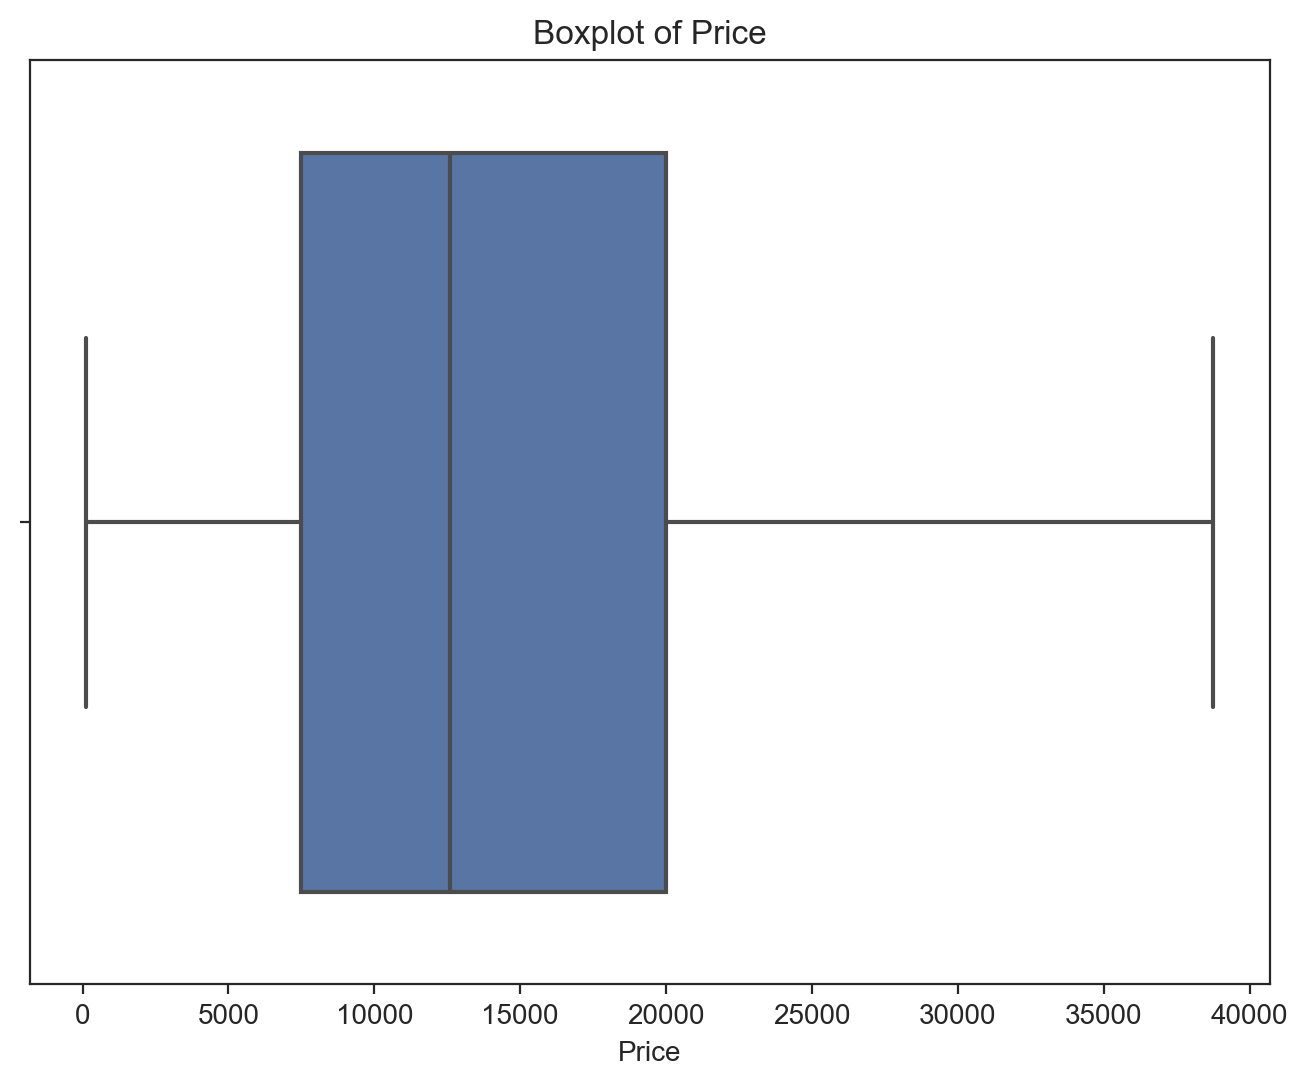

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=car_df['price'], showfliers=False)
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.show()

"""


# Dealing with noise, missing values and outliers


"""

In [7]:
correct_map = {'W':2000.0, 'J':1991.0, 'J':1992.0, 'X':2000.0, 'X':2001.0, 'D':1986.0, 'D':1987.0, 'S':1998.0, 'S':1999.0,
               'H':1990.0, 'H':1991.0, 'K':1992.0, 'K':1993.0, 'E':1987.0, 'E':1988.0, 'L':1993.0, 'L':1994.0, 'V':1999.0,
               'V':2000.0, 'M':1994.0, 'M':1995.0, 'N':1995.0, 'N':1996.0, 'P':1996.0, 'P':1997.0, 'R':1997.0, 'R':1998.0,
               'G':1989.0, 'G':1990.0, 'T':1999.0, 'A':1983.0, 'A':1984.0, 'F':1988.0, 'F':1989.0, 'C':1985.0, 'C':1986.0,
               'm':1973.0, 'm':1974.0, 's':1977.0, 's':1978.0, 'k':1971.0, 'k':1972.0, 'p':1975.0, 'p':1976.0,'Y':2001.0,
               '51':2001.0,'51':2002.0, '02':2002.0, '03':2003.0, '04':2005.0,'06':2006.0,'07':2007.0, '08':2008.0,
               '09':2009.0, '10':2010.0, '11':2011.0, '12':2012.0, '05':2005.0, '13':2013.0, '14':2014.0, '15':2016.0, 
               '16':2016.0, '17':2017.0, '18':2018.0, '19':2019.0, '20':2020.0, '21':2021.0, '52':2002.0, '52':2003.0,
               '53':2003.0, '53':2004.0, '54':2004.0, '54':2005.0, '55':2005.0, '55':2006.0, '56':2006.0, '56':2007.0, 
               '57':2007.0, '57':2008.0, '58':2008.0, '58':2009.0, '59':2009.0, '59':2010.0, '60':2010.0, '60':2011.0, 
               '61':2011.0, '61':2012.0, '62':2012.0, '62':2013.0, '63':2013.0, '63':2014.0, '64':2014.0, '64':2015.0, 
               '65':2015.0, '65':2016.0, '66':2016.0, '66':2017.0, '67':2017.0, '67':2018.0, '68':2018.0, '68':2019.0, 
               '69':2019.0, '69':2020.0, '70':2020.0, '70':2021.0
              }

In [8]:
for index, row in car_df.iterrows():
    registration_code = row['reg_code']
    correct_year = correct_map.get(registration_code)

    if correct_year is not None and row['reg_yr'] != correct_year:
        car_df.at[index, 'reg_yr'] = correct_year


In [9]:
car_df['body_type'] = car_df.groupby('model')['body_type'].transform(lambda x: x.fillna(x.mode()[0] 
                                                                                if not x.mode().empty else 'Unknown'))

In [10]:
car_df['fuel_type'] = car_df.groupby('model')['fuel_type'].transform(lambda x: x.fillna(x.mode()[0] 
                                                                                if not x.mode().empty else 'Unknown'))

"""

creating new features


"""

In [11]:
# Creating new column for car advert date  
car_df["adv_date"] = car_df["public_reference"].astype(str).str[:4]
car_df

,public_reference,mileage,reg_code,colour,brand,model,condition,reg_yr,price,body_type,crossover,fuel_type,adv_date
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid,2020
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2012.0,7000,Saloon,False,Diesel,2020
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol,2020
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel,2020
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
402000,202010315652942,5179.0,69,Grey,Peugeot,208,USED,2020.0,10595,Hatchback,False,Petrol,2020
402001,202010315657341,110000.0,59,Red,Peugeot,107,USED,2010.0,2000,Hatchback,False,Petrol,2020
402002,202010315659271,52760.0,62,White,Nissan,Qashqai,USED,2013.0,7250,SUV,False,Petrol,2020
402003,202011015662436,10250.0,65,Red,Abarth,595,USED,2016.0,11490,Hatchback,False,Petrol,2020


In [12]:
#Changing the new column data type to integer
car_df["adv_date"] = car_df["adv_date"].astype(int)

In [13]:
#Creating a new column for the age of car as at advert date 
car_df["car_age"] = car_df["adv_date"] - car_df["reg_yr"]
car_df[["car_age"]]

,car_age
0,NaN
1,8.0
2,3.0
3,4.0
4,5.0
...,...
402000,0.0
402001,10.0
402002,7.0
402003,4.0


In [14]:
car_df['brand_model'] = car_df['brand'] + ' ' + car_df['model']

In [15]:
car_df['body_fuel'] = car_df['body_type'] + ' ' + car_df['fuel_type']

In [16]:
#dealing with negative value in car_age_at_adv due to car ad date being less that y.o.r 
car_df['car_age'] = car_df['car_age'].abs()

"""


creating a cap on both mileage and prices to remove erroneous values


"""

In [17]:
mileage_bins = [0, 50000, 100000, float('inf')]  # Adjust thresholds as needed
mileage_labels = ['Low Mileage', 'Medium Mileage', 'High Mileage']

# Create a new column 'mileage_category'
car_df['mileage_cat'] = pd.cut(car_df['mileage'], bins=mileage_bins, labels=mileage_labels, right=False)

In [18]:
bins = [0, 5000, 20000, 50000, 1000000, 10000000]

#price ranges
car_df['price range'] = pd.cut(car_df['price'], bins=bins, labels=['cheap', 'regular',
                                                           'costly', 'luxury', 'supreme luxury'])

"""


# Dealing with noise 





"""

In [19]:
max_price = 4000000
car_df['price'] = car_df['price'].clip(upper=max_price)

In [20]:
max_mileage = 400000
car_df['mileage'] = car_df['mileage'].clip(upper=max_mileage)

"""


# Dealing with some missing values 





"""

In [21]:
#dealing with nan reg year with mileage less than 1000
car_df["reg_yr"] = car_df.apply(lambda row: row['adv_date'] if (row['mileage'] < 1000) and 
                                 (pd.isna(row['reg_yr'])) else row['reg_yr'], axis=1)

In [22]:
#dealing with nan values in y.o.r for cars without reg no and are new 
#I assumed them to be new cars, therefore their age would be that of advert date 
car_df["reg_yr"] = car_df.apply(lambda row: row['adv_date'] if (row['condition'] == 'NEW')
                                and (pd.isna(row['reg_yr'])) else row['reg_yr'], axis=1)

In [23]:
med = car_df['reg_yr'].median()
car_df['reg_yr'] = car_df["reg_yr"].fillna(med)

In [24]:
#use bins, find mean mileage for each bins and fill null values with these means
age_5_below = car_df.query("car_age <= 5 ")
mile_5 = age_5_below["mileage"].mean()
mile_5

26371.37717151238

In [25]:
age_6_10 = car_df.query("6 <= car_age >= 10")
mile_6_10 = age_6_10["mileage"].mean()
mile_6_10

87156.58850154502

In [26]:
age_11_17 = car_df.query("11 <= car_age >= 17")
mile_11_17 = age_11_17["mileage"].mean()
mile_11_17

88053.00489181561

In [27]:
age_abv_18 = car_df.query("car_age >= 18")
mile_abv_18 = age_abv_18["mileage"].mean()
mile_abv_18

85956.15243745164

In [28]:
car_df["mileage"] = car_df.apply(lambda row: mile_5 if (row['car_age'] <= 5) and 
                                 (pd.isna(row['mileage'])) else row['mileage'], axis=1)

In [29]:
car_df["mileage"] = car_df.apply(lambda row: mile_6_10 if (6 <= row['car_age'] >= 10) and 
                                 (pd.isna(row['mileage'])) else row['mileage'], axis=1)

In [30]:
car_df["mileage"] = car_df.apply(lambda row: mile_11_17 if (11 <= row['car_age'] >= 17) and 
                                 (pd.isna(row['mileage'])) else row['mileage'], axis=1)

In [31]:
car_df["mileage"] = car_df.apply(lambda row: mile_abv_18 if (row['car_age'] >= 18) and 
                                 (pd.isna(row['mileage'])) else row['mileage'], axis=1)

In [32]:
car_df["mileage"]=car_df["mileage"].fillna(mile_6_10)

In [33]:
car_df

,public_reference,mileage,reg_code,colour,brand,model,condition,reg_yr,price,body_type,crossover,fuel_type,adv_date,car_age,brand_model,body_fuel,mileage_cat,price range
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,2020.0,73970,SUV,False,Petrol Plug-in Hybrid,2020,NaN,Volvo XC90,SUV Petrol Plug-in Hybrid,Low Mileage,luxury
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2012.0,7000,Saloon,False,Diesel,2020,8.0,Jaguar XF,Saloon Diesel,High Mileage,regular
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol,2020,3.0,SKODA Yeti,SUV Petrol,Low Mileage,regular
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel,2020,4.0,Vauxhall Mokka,Hatchback Diesel,Low Mileage,regular
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel,2020,5.0,Land Rover Range Rover Sport,SUV Diesel,Medium Mileage,costly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402000,202010315652942,5179.0,69,Grey,Peugeot,208,USED,2020.0,10595,Hatchback,False,Petrol,2020,0.0,Peugeot 208,Hatchback Petrol,Low Mileage,regular
402001,202010315657341,110000.0,59,Red,Peugeot,107,USED,2010.0,2000,Hatchback,False,Petrol,2020,10.0,Peugeot 107,Hatchback Petrol,High Mileage,cheap
402002,202010315659271,52760.0,62,White,Nissan,Qashqai,USED,2013.0,7250,SUV,False,Petrol,2020,7.0,Nissan Qashqai,SUV Petrol,Medium Mileage,regular
402003,202011015662436,10250.0,65,Red,Abarth,595,USED,2016.0,11490,Hatchback,False,Petrol,2020,4.0,Abarth 595,Hatchback Petrol,Low Mileage,regular


In [34]:
car_df = car_df.drop(['public_reference', 'reg_code', 'reg_yr'], axis = 1)

In [38]:
drops = [ 'price', 'crossover', 'adv_date', 'body_fuel','brand_model', 'mileage_cat', 'price range']

"""


SPLIT DATA INTO TEST AND TRAIN, CATEGORICAL ENCODING AND SCALING



"""

In [39]:
X, y = car_df.drop(drops, axis = 1), car_df['price']

In [40]:
from scipy.stats import yeojohnson
y_target, _ = yeojohnson(y)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=.3,  random_state=42)

In [42]:
X_train.shape, X_test.shape

((281403, 8), (120602, 8))

In [43]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   mileage    402005 non-null  float64
 1   colour     396627 non-null  object 
 2   brand      402005 non-null  object 
 3   model      402005 non-null  object 
 4   condition  402005 non-null  object 
 5   body_type  402005 non-null  object 
 6   fuel_type  402005 non-null  object 
 7   car_age    370424 non-null  float64
dtypes: float64(2), object(6)
memory usage: 24.5+ MB


"""

# Ordinary Pipeline


"""

In [55]:
def create_pp(X, linear_model=False):
    """creates a default preprocessing pipeline for numeric and categorical data
    using simple imputers, scalers, and encoders. It relies on latest versions
    of sklearn so as to produce pandas outputs.

    X: the dataset with the features (needed for feature names)

    returns the Pipeline object
    """

    numeric_features = X.select_dtypes(exclude='object').columns.tolist()
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="mean"))
        ]
    )
    
    if linear_model:
        numeric_transformer.steps.extend([
            ("scaler", RobustScaler(with_centering=True, with_scaling=True, 
                      quantile_range=(25.0, 75.0), copy=True, unit_variance=False))
            
        ])

    categorical_features = X.select_dtypes(include='object').columns.tolist()
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("te", TargetEncoder(min_samples_leaf=10, smoothing=5, return_df = True)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )

    return preprocessor

def create_regr_ppln(est, X, linear_model=False):
    """ """
    regr_pipe = Pipeline(
        steps=[
            ("pp", create_pp(X, linear_model)),
            ("regr", est)
        ]
    )

    return regr_pipe

"""


# SIMPLE LINEAR REGRESSION


"""

In [56]:
lr = create_regr_ppln(LinearRegression(), X_train, linear_model=True)


In [57]:
lr_results = cross_validate(
        lr, X_train, y_train, cv=5,
        scoring='r2',
        return_train_score=True
    )
lr_results['test_score'].mean(), lr_results['test_score'].std()

(0.8583009351680306, 0.002420489180479754)

In [58]:
lr_results['train_score'].mean(), lr_results['train_score'].std()

(0.8595851660473549, 0.0006318441698570011)

In [97]:
lr.fit(X_train, y_train)

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5))]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('regr', LinearRegression())])

In [98]:
y_pred = lr.predict(X_test)

In [99]:
# Calculate Mean Squared Error and Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

In [100]:
mse, mae

(0.4839550354312147, 0.4907310939748869)

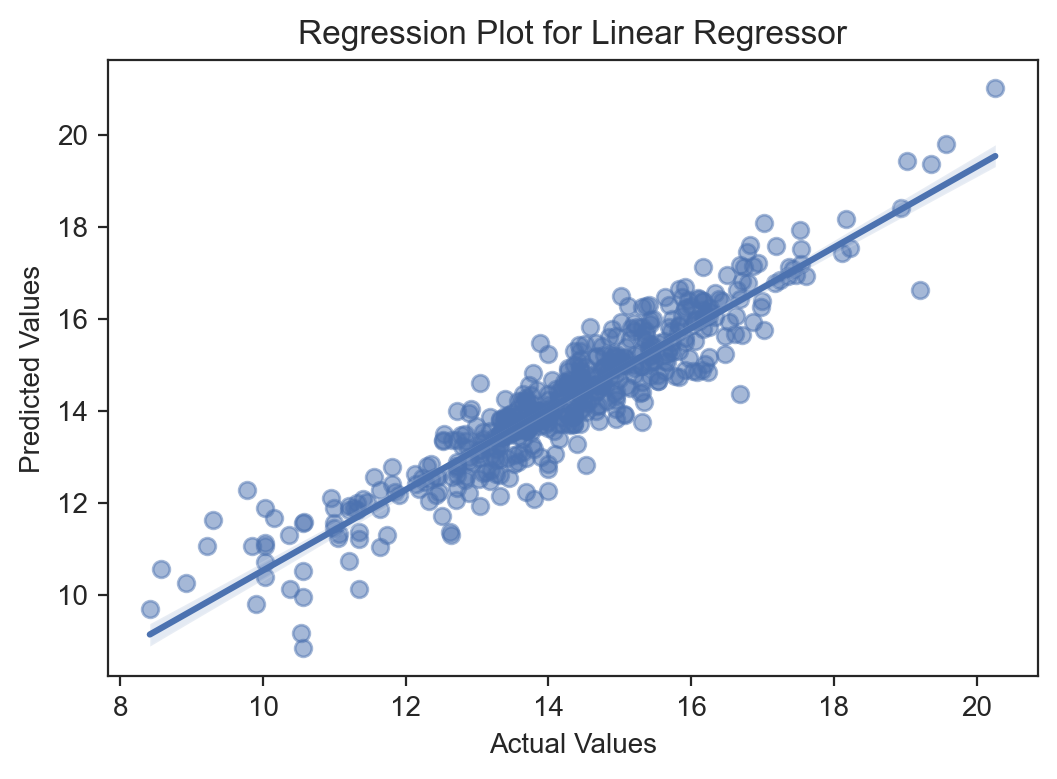

In [102]:
sns.regplot(x=y_test[:500], y=y_pred[:500], scatter_kws={'alpha':0.5})
plt.title('Regression Plot for Linear Regressor')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

"""


# POLYNOMIAL FEATURES


"""

"""


# Pipeline with polynomial features 




"""

In [110]:
def create_poly_ppln(X, scaling=False, poly=False, pca=False, n_components=None):
    """creates a default preprocessing pipeline for numeric and categorical data
    using simple imputers, scalers, and encoders. It relies on latest versions
    of sklearn so as to produce pandas outputs.

    X: the dataset with the features (needed for feature names)

    returns the Pipeline object
    """

    numeric_features = X.select_dtypes(exclude='object').columns.tolist()
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="mean"))
        ]
    )

    if scaling:
        numeric_transformer.steps.extend([
            ("scaler", RobustScaler(with_centering=True, with_scaling=True, 
                      quantile_range=(25.0, 75.0), copy=True, unit_variance=False))
        ])
    if poly:
        numeric_transformer.steps.extend([
            ('poly', PolynomialFeatures(interaction_only=False, include_bias=False))
        ])


    categorical_features = X.select_dtypes(include='object').columns.tolist()
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("te", TargetEncoder(min_samples_leaf=10, smoothing=5, return_df = True)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
        
    )

    return preprocessor

def create_poly_regr_ppln(est, X, scaling=False, poly=False, pca=False, n_components=None):
    """ """
    pipe = Pipeline(
        steps=[
            ("pp", create_poly_ppln(X, scaling, poly, pca, n_components)),
            ("est", est)
        ]
    )

    return pipe

"""


# LINEAR REGRESSION WITH POLYNOMIAL FEATURE INTERACTION


"""

In [88]:
lr_poly = create_poly_regr_ppln(LinearRegression(), X_train, scaling=True, poly=True)
lr_poly.set_output(transform='pandas')

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5))]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', LinearRegression())])

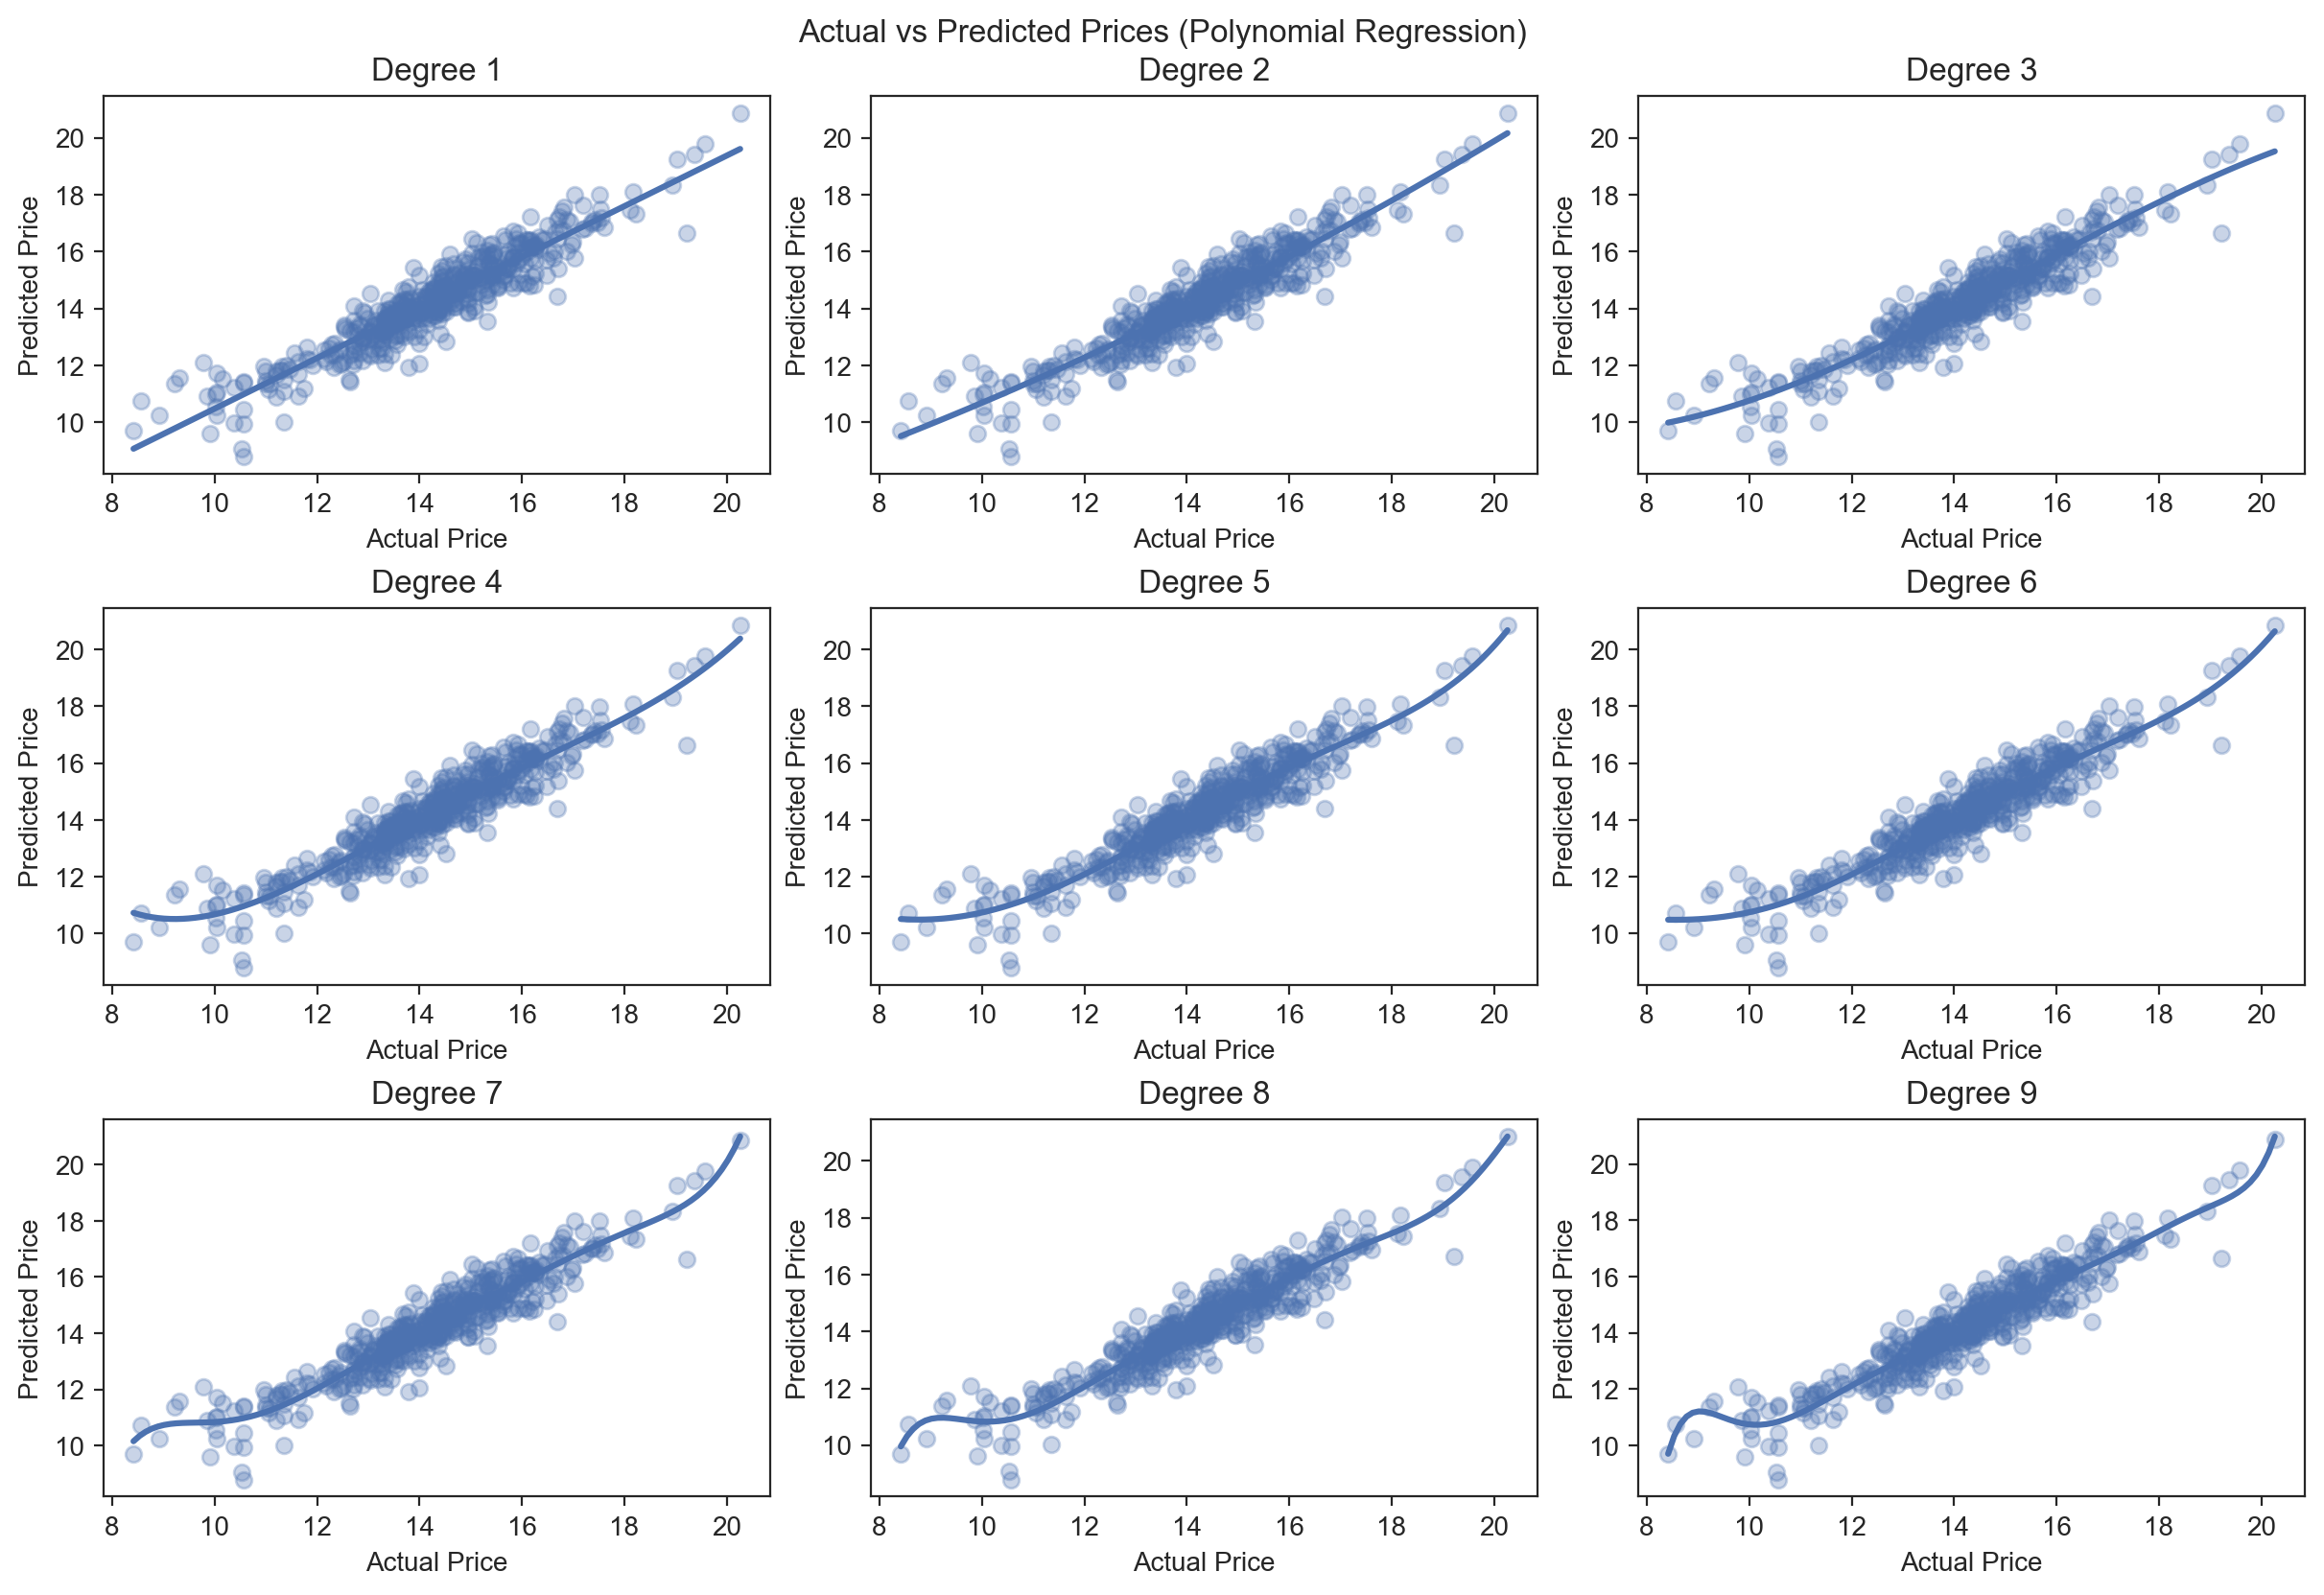

In [84]:
orders = [1,2,3,4,5,6,7,8,9]
fig, axs = plt.subplots(3, 3, figsize=(12, 8), constrained_layout=True)

# Plot actual vs predicted prices
lr_models = []
for ax, order in zip(axs.ravel(), orders):
    
    lr_models.append(lr_poly.fit(X_train, y_train))
    y_pred = lr_poly.predict(X_test.head(500))
    
    sns.regplot(
        data=lr_poly, x=y_test[:500], y=y_pred, order=order,
        scatter_kws=dict(alpha=0.3), ax=ax, ci=None
    )
    ax.set_title(f'Degree {order}')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')

plt.suptitle('Actual vs Predicted Prices (Polynomial Regression)', y=1.02)
plt.show()


In [91]:
lr_poly.fit(X_train, y_train)

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5))]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', LinearRegression())])

In [92]:
poly_features = lr_poly.named_steps['pp']
X_train_poly = poly_features.transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [93]:
lr_poly.named_steps['pp'].transform(X_train).head()

,mileage,car_age,mileage^2,mileage car_age,car_age^2,colour,brand,model,condition,body_type,fuel_type
167189,-0.375536,-1.000000,0.141027,0.375536,1.000000,14.169009,13.385672,14.448883,14.080982,15.125754,14.359971
124611,0.142501,-0.250000,0.020306,-0.035625,0.062500,14.433078,13.385672,14.224869,14.080982,15.125754,14.359971
82405,-0.618619,0.130943,0.382690,-0.081004,0.017146,14.169009,13.385672,12.842828,16.156898,13.413892,13.992213
287015,0.100280,-0.250000,0.010056,-0.025070,0.062500,14.651355,12.984512,12.880171,14.080982,13.413892,14.359971
86981,0.376552,0.500000,0.141791,0.188276,0.250000,14.433078,13.888497,13.737190,14.080982,13.413892,13.992213


In [94]:
lr_poly_results = cross_validate(
        lr_poly, X_train, y_train, cv=5,
        scoring='r2',
        return_train_score=True
    )
lr_poly_results['test_score'].mean(), lr_results['test_score'].std()

(0.8717844152792436, 0.002420489180479754)

In [95]:
lr_poly_results['train_score'].mean(), lr_poly_results['train_score'].std()

(0.8734367811685546, 0.00026685160981466374)

In [104]:
poly_pred = lr_poly.predict(X_test)

In [105]:
# Calculate Mean Squared Error and Mean Absolute Error
mse = mean_squared_error(y_test, poly_pred)
mae = mean_absolute_error(y_test, poly_pred)
mse,mae

(0.43151065851680775, 0.47288220695545913)

"""

# Regression with automated selection

""""

FUNCTION TO CREATE PIPELINE WITH ALL TRANSFORMERS

In [111]:

def create_pp_ppln(X, scaling=False, poly=False, pca=False, n_components=None, k_best=False, rfecv=False, sfs=False):
    numeric_features = X.select_dtypes(exclude='object').columns.tolist()
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="mean"))
        ]
    )

    if scaling:
        numeric_transformer.steps.extend([
            ("scaler", RobustScaler(with_centering=True, with_scaling=True, 
                      quantile_range=(25.0, 75.0), copy=True, unit_variance=False))
        ])
    if poly:
        numeric_transformer.steps.extend([
            ('poly', PolynomialFeatures(interaction_only=False, include_bias=False))
        ])
   
    if k_best:
        numeric_transformer.steps.extend([('k_best', SelectKBest())])
    if rfecv:
        numeric_transformer.steps.extend([("featsel", RFECV(estimator=LinearRegression(), step=1, cv=5))])
    if sfs:
        numeric_transformer.steps.extend([("sfs", SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select='auto', direction="forward"))])
    if pca:
        numeric_transformer.steps.extend([('pca', PCA(n_components=n_components))])

    categorical_features = X.select_dtypes(include='object').columns.tolist()
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("te", TargetEncoder(min_samples_leaf=10, smoothing=5, return_df = True)),
        ]
    )

    if k_best:
        categorical_transformer.steps.extend([('k_best', SelectKBest())])
    if rfecv:
        categorical_transformer.steps.extend([("featsel", RFECV(estimator=LinearRegression(), step=1, cv=5))])
    if sfs:
        categorical_transformer.steps.extend([("sfs", SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select='auto', direction="forward"))])
    if pca:
        categorical_transformer.steps.extend([('pca', PCA(n_components=n_components))])



    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )

    return preprocessor

def create_regr_ppln(est, X, scaling=False, poly=False, pca=False, n_components=None, k_best=False, rfecv=False, sfs=False):
    """ """
    est_pipe = Pipeline(
        steps=[
            ("pp", create_pp_ppln(X, scaling, poly, pca, n_components, k_best, rfecv, sfs)),
            ("est", est)
        ]
    )

    return est_pipe


"""

# SELECT K-BEST



"""

In [112]:
lr_kb = create_regr_ppln(LinearRegression(), X_train, scaling=True, poly=True, 
                         pca=False, n_components=None, k_best=True,  rfecv=False, sfs=False)
gbr_kb  = create_regr_ppln(GradientBoostingRegressor(max_depth=3), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=True,  rfecv=False, sfs=False)
rfr_kb  = create_regr_ppln(RandomForestRegressor(max_depth=5), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=True,  rfecv=False, sfs=False)
my_models = [ gbr_kb, rfr_kb, lr_kb ]

In [113]:
model_results_list = []
for my_model in my_models:
    eval_results = cross_validate(
        my_model, X_train, y_train, cv=5,
        scoring='r2',
        return_train_score=True
    )
    model_results_list.append(
        (eval_results['test_score'].mean(), eval_results['test_score'].std(),
         eval_results['train_score'].mean(), eval_results['train_score'].std())
    )

In [115]:
model_kbest_results = pd.DataFrame(
    model_results_list,
    columns=['test_score_mean', 'test_score_std', 'train_score_mean', 'train_score_std'],
    index=['gbr_kb', 'rfr_kb', 'lr_kb']
)

In [116]:
model_kbest_results

,test_score_mean,test_score_std,train_score_mean,train_score_std
gbr_kb,0.908000,0.001906,0.910036,0.000671
rfr_kb,0.846326,0.001079,0.849423,0.001826
lr_kb,0.871784,0.001782,0.873437,0.000267


In [193]:
lr_kb.set_output(transform='pandas')

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', LinearRegression())])

In [199]:
lr_kb.named_steps['pp'].fit_transform(X_train, y_train).head()

,mileage,car_age,mileage^2,mileage car_age,car_age^2,colour,brand,model,condition,body_type,fuel_type
167189,-0.375536,-1.000000,0.141027,0.375536,1.000000,14.169009,13.385672,14.448883,14.080982,15.125754,14.359971
124611,0.142501,-0.250000,0.020306,-0.035625,0.062500,14.433078,13.385672,14.224869,14.080982,15.125754,14.359971
82405,-0.618619,0.130943,0.382690,-0.081004,0.017146,14.169009,13.385672,12.842828,16.156898,13.413892,13.992213
287015,0.100280,-0.250000,0.010056,-0.025070,0.062500,14.651355,12.984512,12.880171,14.080982,13.413892,14.359971
86981,0.376552,0.500000,0.141791,0.188276,0.250000,14.433078,13.888497,13.737190,14.080982,13.413892,13.992213


"""


# With RFECV


"""

In [127]:
lr_rfe = create_regr_ppln(LinearRegression(), X_train, scaling=True, poly=True, 
                         pca=False, n_components=None, k_best=False,  rfecv=True, sfs=False)
gbr_rfe  = create_regr_ppln(GradientBoostingRegressor(max_depth=3), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=False,  rfecv=True, sfs=False)
rfr_rfe  = create_regr_ppln(RandomForestRegressor(max_depth=5), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=False,  rfecv=True, sfs=False)
my_rfe_models = [ gbr_rfe, rfr_rfe, lr_rfe ]

In [128]:
rfe_model_results_list = []
for my_model in my_rfe_models:
    eval_results = cross_validate(
        my_model, X_train, y_train, cv=5,
        scoring='r2',
        return_train_score=True
    )
    rfe_model_results_list.append(
        (eval_results['test_score'].mean(), eval_results['test_score'].std(),
         eval_results['train_score'].mean(), eval_results['train_score'].std())
    )

In [129]:
model_rfe_results = pd.DataFrame(
    rfe_model_results_list,
    columns=['test_score_mean', 'test_score_std', 'train_score_mean', 'train_score_std'],
    index=['gbr_rfe', 'rfr_rfe', 'lr_rfe']
)

In [130]:
model_rfe_results

,test_score_mean,test_score_std,train_score_mean,train_score_std
gbr_rfe,0.908000,0.001907,0.910036,0.000671
rfr_rfe,0.846195,0.001352,0.849359,0.001782
lr_rfe,0.871784,0.001782,0.873437,0.000267


In [202]:
lr_rfe.set_output(transform='pandas')

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('featsel',
                                                                   RFECV(cv=5,
                                                                         estimator=LinearRegression()))]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5)),
                                                                  ('featsel',
                                                                   RFECV(cv=5,
                                                                         estimator=LinearRegression()))]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', LinearRegression())])

In [203]:
lr_rfe.named_steps['pp'].fit_transform(X_train, y_train).head()

,mileage,car_age,mileage^2,mileage car_age,car_age^2,colour,brand,model,condition,body_type,fuel_type
167189,-0.375536,-1.000000,0.141027,0.375536,1.000000,14.169009,13.385672,14.448883,14.080982,15.125754,14.359971
124611,0.142501,-0.250000,0.020306,-0.035625,0.062500,14.433078,13.385672,14.224869,14.080982,15.125754,14.359971
82405,-0.618619,0.130943,0.382690,-0.081004,0.017146,14.169009,13.385672,12.842828,16.156898,13.413892,13.992213
287015,0.100280,-0.250000,0.010056,-0.025070,0.062500,14.651355,12.984512,12.880171,14.080982,13.413892,14.359971
86981,0.376552,0.500000,0.141791,0.188276,0.250000,14.433078,13.888497,13.737190,14.080982,13.413892,13.992213


"""

# With SFS


"""

In [136]:
lr_sfs = create_regr_ppln(LinearRegression(), X_train, scaling=True, poly=True, 
                         pca=False, n_components=None, k_best=False,  rfecv=False, sfs=True)
gbr_sfs  = create_regr_ppln(GradientBoostingRegressor(max_depth=3), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=False,  rfecv=False, sfs=True)
rfr_sfs  = create_regr_ppln(RandomForestRegressor(max_depth=5), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=False,  rfecv=False, sfs=True)
my_sfs_models = [ gbr_sfs, rfr_sfs, lr_sfs ]

In [137]:
sfs_model_results_list = []
for my_model in my_sfs_models:
    eval_results = cross_validate(
        my_model, X_train, y_train, cv=5,
        scoring='r2',
        return_train_score=True
    )
    sfs_model_results_list.append(
        (eval_results['test_score'].mean(), eval_results['test_score'].std(),
         eval_results['train_score'].mean(), eval_results['train_score'].std())
    )

In [140]:
model_sfs_results = pd.DataFrame(
    sfs_model_results_list,
    columns=['test_score_mean', 'test_score_std', 'train_score_mean', 'train_score_std'],
    index=['gbr_sfs', 'rfr_sfs', 'lr_sfs']
)

In [142]:
model_sfs_results

,test_score_mean,test_score_std,train_score_mean,train_score_std
gbr_sfs,0.876098,0.002527,0.879373,0.000639
rfr_sfs,0.832492,0.001612,0.835662,0.001683
lr_sfs,0.824774,0.003154,0.827036,0.000728


In [204]:
lr_sfs.set_output(transform='pandas')

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('sfs',
                                                                   SequentialFeatureSelector(estimator=LinearRegression()))]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5)),
                                                                  ('sfs',
                                                                   SequentialFeatureSelector(estimator=LinearRegression()))]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', LinearRegression())])

In [205]:
lr_sfs.named_steps['pp'].fit_transform(X_train, y_train).head()

,mileage,car_age,colour,model,condition
167189,-0.375536,-1.000000,14.169009,14.448883,14.080982
124611,0.142501,-0.250000,14.433078,14.224869,14.080982
82405,-0.618619,0.130943,14.169009,12.842828,16.156898
287015,0.100280,-0.250000,14.651355,12.880171,14.080982
86981,0.376552,0.500000,14.433078,13.737190,14.080982


"""

# PRINCIPAL COMPONENT ANALYSIS


"""

PCA with SELECT K_BEST as preferred feature selector

In [288]:
lr_pca = create_regr_ppln(LinearRegression(), X_train, scaling=True, poly=True, 
                         pca=True, n_components=None, k_best=True,  rfecv=False, sfs=False)
gbr_pca  = create_regr_ppln(GradientBoostingRegressor(max_depth=3), X_train, scaling=True, poly=True, 
                           pca=True, n_components=5, k_best=True,  rfecv=False, sfs=False)
rfr_pca  = create_regr_ppln(RandomForestRegressor(max_depth=5), X_train, scaling=True, poly=True, 
                           pca=True, n_components=None, k_best=True,  rfecv=False, sfs=False)
my_pca_models = [ gbr_pca, rfr_pca, lr_pca ]

In [289]:
gbr_pca.fit(X_train, y_train)

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('k_best',
                                                                   SelectKBest()),
                                                                  ('pca',
                                                                   PCA(n_components=5))]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5)),
                                                                  ('k_best',
                                                                   SelectKBest()),
                                                                  ('pca',
                                                                   PCA(n_components=5))]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', GradientBoostingRegressor())])

In [290]:
gbr_pca.score(X_test, y_test)

0.9052937621893311

In [291]:
pca_obj =  gbr_pca.fit(X_train, y_train)

In [292]:
X_train_processed = gbr_pca.named_steps['pp'].fit_transform(X_train, y_train)

In [293]:
pca = pca_obj.named_steps['pp'].transformers[1][1].named_steps['pca']

In [294]:
pca.fit(X_train_processed)

PCA(n_components=5)

In [295]:
pca.explained_variance_

array([14.71895421,  3.02456745,  2.52118453,  0.54370358,  0.446504  ])

In [296]:
explained_variance_ratio= pca.explained_variance_ratio_
explained_variance_ratio

array([0.65642604, 0.13488763, 0.1124381 , 0.02424773, 0.01991289])

In [297]:
pca_components = pca.components_
pca_components

array([[ 9.99366023e-01, -7.38195005e-04, -4.04249953e-04,
         3.47305940e-05, -1.35288405e-04, -1.61794471e-02,
         1.59995620e-02, -2.54183065e-02,  9.90922011e-03,
        -2.18647514e-03],
       [ 1.32911848e-02,  6.99157782e-01,  5.61691490e-02,
        -2.09204548e-03,  5.31429838e-03,  7.11396679e-01,
        -1.84334956e-02,  3.29117548e-02, -1.28715060e-02,
        -1.18431673e-02],
       [-9.24236567e-03,  7.11837698e-01, -6.53701705e-02,
         1.83233034e-03, -4.05573757e-03, -6.97269816e-01,
        -2.25738922e-02,  4.21919235e-02, -1.46556069e-02,
        -1.47946641e-02],
       [ 1.44166789e-02, -2.28594028e-02,  7.32863010e-01,
        -5.59228486e-02,  3.57028597e-02, -6.11468865e-02,
        -6.46724049e-01,  1.34404519e-01, -1.31804540e-01,
         1.87458499e-02],
       [-4.49926589e-03,  1.01977464e-02,  5.81774800e-01,
         8.65941851e-02, -4.85332730e-02, -4.99256653e-02,
         7.43770588e-01,  2.32463689e-01, -2.02518609e-01,
         2.

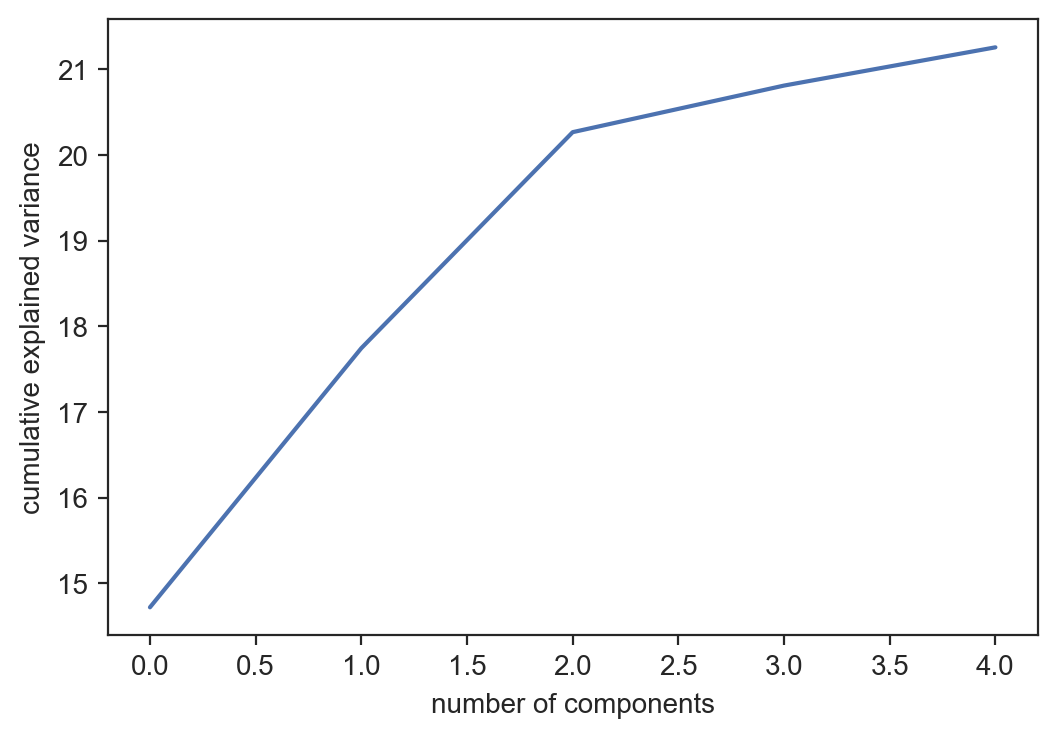

In [298]:
plt.plot(np.cumsum(pca.explained_variance_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

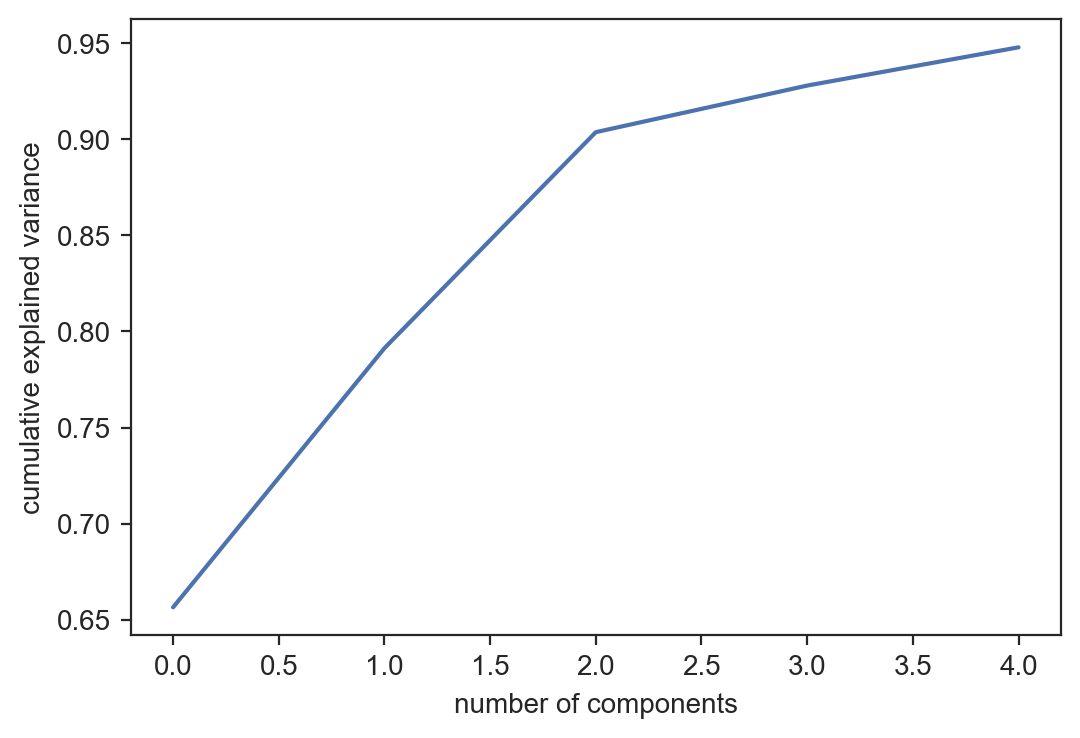

In [299]:
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

In [303]:
selX = pca_obj.named_steps['pp'].transformers[1][1].named_steps['k_best'].fit(X_train_processed, y_train)

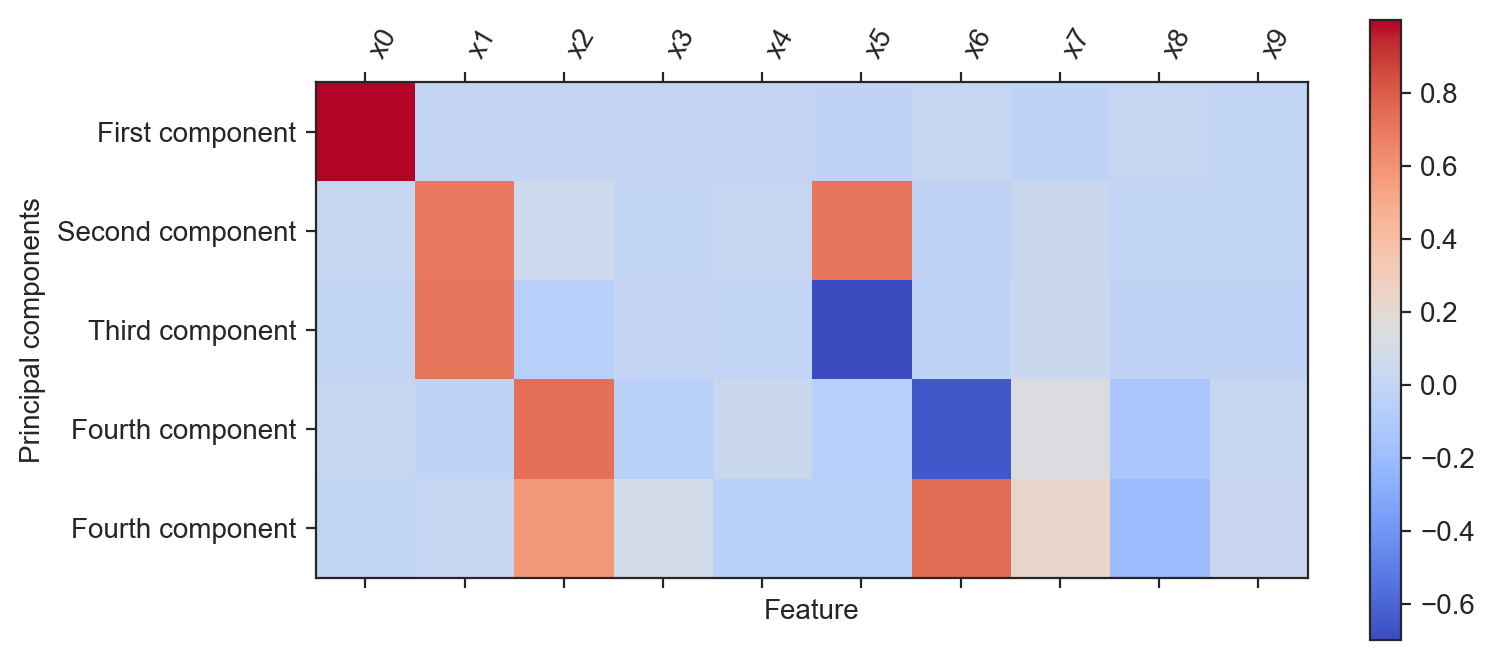

In [304]:
plt.matshow(pca_components, cmap='coolwarm')
plt.yticks([0, 1, 2, 3,4], ["First component", "Second component", "Third component", "Fourth component", "Fourth component"])
plt.colorbar()
plt.xticks(range(len(selX.get_feature_names_out())),
           selX.get_feature_names_out(), rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components");

"""

# Building Models


"""

In [407]:
lr = create_regr_ppln(LinearRegression(), X_train, scaling=True, poly=True, 
                         pca=False, n_components=None, k_best=True,  rfecv=False, sfs=False)
gbr  = create_regr_ppln(GradientBoostingRegressor(max_depth=3), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=True,  rfecv=False, sfs=False)
rfr  = create_regr_ppln(RandomForestRegressor(max_depth=5), X_train, scaling=True, poly=True, 
                           pca=False, n_components=None, k_best=True,  rfecv=False, sfs=False)
my_models = [ gbr, rfr, lr ]


In [408]:
lr.set_output(transform='pandas') 

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', LinearRegression())])

In [409]:
gbr.set_output(transform='pandas')

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', GradientBoostingRegressor())])

In [410]:
rfr.set_output(transform='pandas')

Pipeline(steps=[('pp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['mileage', 'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder(min_samples_leaf=10,
                                                                                 smoothing=5)),
                                                                  ('k_best',
                                                                   SelectKBest())]),
                                                  ['colour', 'brand', 'model',
                                                   'condition', 'body_type',
                                                   'fuel_type'])],
                                   verbose_feature_names_out=False)),
                ('est', RandomForestRegressor(max_depth=5))])

In [337]:
model_results_list = []
for my_model in my_models:
    eval_results = cross_validate(
        my_model, X_train, y_train, cv=5,
        scoring='r2',
        return_train_score=True
    )
    model_results_list.append(
        (eval_results['test_score'].mean(), eval_results['test_score'].std(),
         eval_results['train_score'].mean(), eval_results['train_score'].std()))

In [338]:
model_results = pd.DataFrame(
    model_results_list,
    columns=['test_score_mean', 'test_score_std', 'train_score_mean', 'train_score_std'],
    index=['gbr', 'rfr', 'lr']
)

In [339]:
model_results

,test_score_mean,test_score_std,train_score_mean,train_score_std
gbr,0.903646,0.001830,0.905909,0.000120
rfr,0.843831,0.003465,0.846428,0.000886
lr,0.871784,0.001782,0.873437,0.000267


"""

# VOTING ENSEMBLE


"""

In [307]:
ensemble = VotingRegressor(
    [
        ("gb", gbr),
        ("rf", rfr),
        ('lr', lr)
    ]
)
ensemble.fit(X_train, y_train)

VotingRegressor(estimators=[('gb',
                             Pipeline(steps=[('pp',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                RobustScaler()),
                                                                                               ('poly',
                                                                                                PolynomialFeatures(include_bias=False)),
                                                                                               ('k_best',
                                                                                                SelectKBest()),
                                                                                               ('pca',
                                                                                                PCA())]),
                                                                               ['mileage',
                                                                                'car_age']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(s...
                                                                                                SelectKBest()),
                                                                                               ('pca',
                                                                                                PCA())]),
                                                                               ['mileage',
                                                                                'car_age']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('te',
                                                                                                TargetEncoder(min_samples_leaf=10,
                                                                                                              smoothing=5)),
                                                                                               ('k_best',
                                                                                                SelectKBest()),
                                                                                               ('pca',
                                                                                                PCA())]),
                                                                               ['colour',
                                                                                'brand',
                                                                                'model',
                                                                                'condition',
                                                                                'body_type',
                                                               

In [340]:
eval_results = cross_validate(
    ensemble, X_train, y_train, cv=3,
    scoring='r2',
    return_train_score=True
)
ensemble_result = (
    eval_results['test_score'].mean(), eval_results['test_score'].std(),
    eval_results['train_score'].mean(), eval_results['train_score'].std()
)

In [341]:
model_results.loc['voter'] = ensemble_result
model_results

,test_score_mean,test_score_std,train_score_mean,train_score_std
gbr,0.903646,0.001830,0.905909,0.000120
rfr,0.843831,0.003465,0.846428,0.000886
lr,0.871784,0.001782,0.873437,0.000267
voter,0.889964,0.001528,0.892500,0.000287


"""


# STACKER ENSEMBLE


"""

In [344]:
stacker = StackingRegressor(
    estimators=[
        ('lr', lr),
        ('gbr', gbr),
        ('rfr', rfr)
    ],
    final_estimator=LinearRegression(),  # Meta-regressor
    cv=5
)

In [345]:
# Fit the stacking regressor
stacker.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('lr',
                               Pipeline(steps=[('pp',
                                                ColumnTransformer(remainder='passthrough',
                                                                  transformers=[('num',
                                                                                 Pipeline(steps=[('imputer',
                                                                                                  SimpleImputer()),
                                                                                                 ('scaler',
                                                                                                  RobustScaler()),
                                                                                                 ('poly',
                                                                                                  PolynomialFeatures(include_bias=False)),
                                                                                                 ('k_best',
                                                                                                  SelectKBest()),
                                                                                                 ('pca',
                                                                                                  PCA())]),
                                                                                 ['mileage',
                                                                                  'car_age']),
                                                                                ('cat',
                                                                                 Pipeline(steps=[('imputer',
                                                                                                  SimpleIm...
                                                                                ('cat',
                                                                                 Pipeline(steps=[('imputer',
                                                                                                  SimpleImputer(strategy='most_frequent')),
                                                                                                 ('te',
                                                                                                  TargetEncoder(min_samples_leaf=10,
                                                                                                                smoothing=5)),
                                                                                                 ('k_best',
                                                                                                  SelectKBest()),
                                                                                                 ('pca',
                                                                                                  PCA())]),
                                                                                 ['colour',
                                                                                  'brand',
                                                                                  'model',
                                                                                  'condition',
                                                                                  'body_type',
                                                                                  'fuel_type'])],
                                                                  verbose_feature_names_out=False)),
                                               ('est',
                                                RandomForestRegressor(max_depth=5))]))],
                  final_estimator=LinearRegression())

In [346]:
eval_results = cross_validate(
    stacker, X_train, y_train, cv=3,
    scoring='r2',
    return_train_score=True
)
stacker_result = (
    eval_results['test_score'].mean(), eval_results['test_score'].std(),
    eval_results['train_score'].mean(), eval_results['train_score'].std()
)

In [347]:
model_results.loc['stacker'] = stacker_result
model_results

,test_score_mean,test_score_std,train_score_mean,train_score_std
gbr,0.903646,0.001830,0.905909,0.000120
rfr,0.843831,0.003465,0.846428,0.000886
lr,0.871784,0.001782,0.873437,0.000267
voter,0.889964,0.001528,0.892500,0.000287
stacker,0.902982,0.001103,0.905816,0.000329


"""

# ACTUAL VS PREDICTED PLOT 

"""

In [411]:
gbr = gbr.fit(X_train, y_train)

In [412]:
rfr = rfr.fit(X_train, y_train)

In [413]:
lr = lr.fit(X_train, y_train)

In [383]:
xt = X_test.head(20)
yt = y_test[:20]
pred_gbr = gbr.predict(xt)
pred_rfr = rfr.predict(xt)
pred_lr = lr.predict(xt)
pred_ens = ensemble.predict(xt)
pred_stack = stacker.predict(xt)

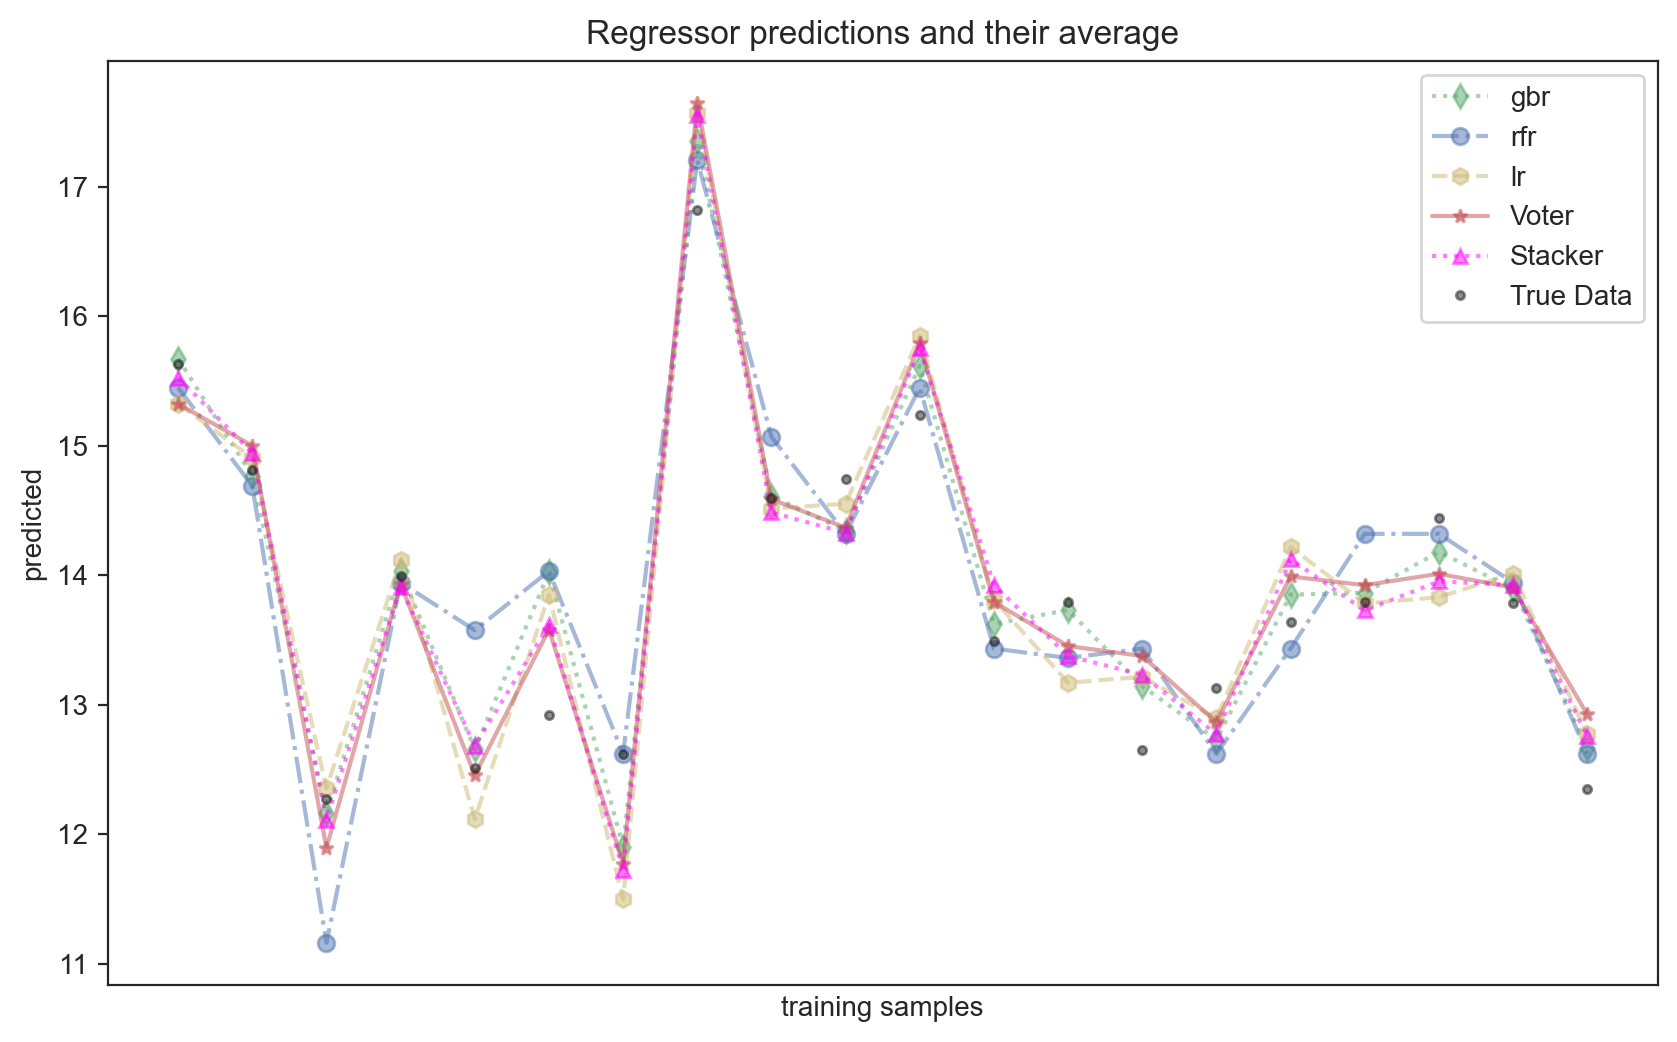

In [394]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(pred_gbr, "gd:", alpha=0.5, label="gbr")
ax.plot(pred_rfr, "bo-.", alpha=0.5, label="rfr")
ax.plot(pred_lr, "yh--", alpha=0.5, label="lr")
ax.plot(pred_ens, "r*-", alpha=0.5, ms=5, label="Voter")
ax.plot(pred_stack, "^:", color='fuchsia', alpha=0.5, ms=5, label="Stacker")
ax.plot(yt, "ko", alpha=0.5, ms=3, label="True Data")

ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
ax.set_ylabel("predicted")
ax.set_xlabel("training samples")
ax.legend(loc="best")
ax.set_title("Regressor predictions and their average");

"""

# GLOBAL AND LOCAL EXPLANATIONS WITH SHAP  


"""

"""

# linear regression (Local)

"""

In [414]:
lr_model = lr.named_steps['est']

In [416]:
preprocessor = lr.named_steps['pp'].fit_transform(X_train, y_train)#.get_feature_names_out()

# # If the preprocessor is a ColumnTransformer
# if isinstance(preprocessor, ColumnTransformer):
#     # Get the transformed feature names
#     feature_names_out = preprocessor.get_feature_names_out()
# else:
#     # If it's not a ColumnTransformer, you might need to manually retrieve the feature names
#     # based on the preprocessing steps applied
#     feature_names_out = X.columns.tolist()  # Assuming X is your input DataFrame


In [417]:
preprocessor

,mileage,car_age,mileage^2,mileage car_age,car_age^2,colour,brand,model,condition,body_type,fuel_type
167189,-0.375536,-1.000000,0.141027,0.375536,1.000000,14.169009,13.385672,14.448883,14.080982,15.125754,14.359971
124611,0.142501,-0.250000,0.020306,-0.035625,0.062500,14.433078,13.385672,14.224869,14.080982,15.125754,14.359971
82405,-0.618619,0.130943,0.382690,-0.081004,0.017146,14.169009,13.385672,12.842828,16.156898,13.413892,13.992213
287015,0.100280,-0.250000,0.010056,-0.025070,0.062500,14.651355,12.984512,12.880171,14.080982,13.413892,14.359971
86981,0.376552,0.500000,0.141791,0.188276,0.250000,14.433078,13.888497,13.737190,14.080982,13.413892,13.992213
...,...,...,...,...,...,...,...,...,...,...,...
259178,0.356932,0.000000,0.127401,0.000000,0.000000,14.433078,15.243330,15.857293,14.080982,15.125754,14.359971
365838,-0.586230,-0.750000,0.343665,0.439672,0.562500,13.546871,15.024067,14.854232,14.080982,14.644326,14.359971
131932,-0.175668,-0.250000,0.030859,0.043917,0.062500,14.651355,15.243330,13.978300,14.080982,13.413892,14.359971
146867,0.440142,0.500000,0.193725,0.220071,0.250000,14.415226,14.092783,13.256258,14.080982,14.644326,14.359971


In [418]:
X = lr['pp'].fit_transform(X_train,y_train)

In [419]:
X_test_t = lr['pp'].transform(X_test)

In [420]:
lr_explainer = shap.LinearExplainer(lr_model, X)
lr_shap_values = lr_explainer(X_test_t) 

In [421]:
lr_shap_values

.values =
array([[ 0.54511552,  0.73309778, -0.01926647, ..., -0.07241512,
        -0.10699669,  0.03097144],
       [ 0.41985835,  0.56748824, -0.03427461, ..., -0.07241512,
         0.18009712, -0.04817997],
       [ 0.22010739, -1.08860715, -0.047193  , ..., -0.07241512,
        -0.11060501, -0.04817997],
       ...,
       [ 0.59048198, -0.01608182, -0.01251734, ...,  0.9620866 ,
         0.20855201, -0.04817997],
       [-0.67412413, -0.26055946,  0.06096454, ..., -0.07241512,
         0.18009712, -0.04817997],
       [-1.13869535, -1.25421669,  0.22426443, ..., -0.07241512,
        -0.11060501, -0.04817997]])

.base_values =
array([14.15590894, 14.15590894, 14.15590894, ..., 14.15590894,
       14.15590894, 14.15590894])

.data =
array([[-5.57556638e-01, -1.00000000e+00,  3.10869405e-01, ...,
         1.40809823e+01,  1.34351406e+01,  1.43599710e+01],
       [-3.89559318e-01, -7.50000000e-01,  1.51756462e-01, ...,
         1.40809823e+01,  1.51257540e+01,  1.39922129e+01],
      

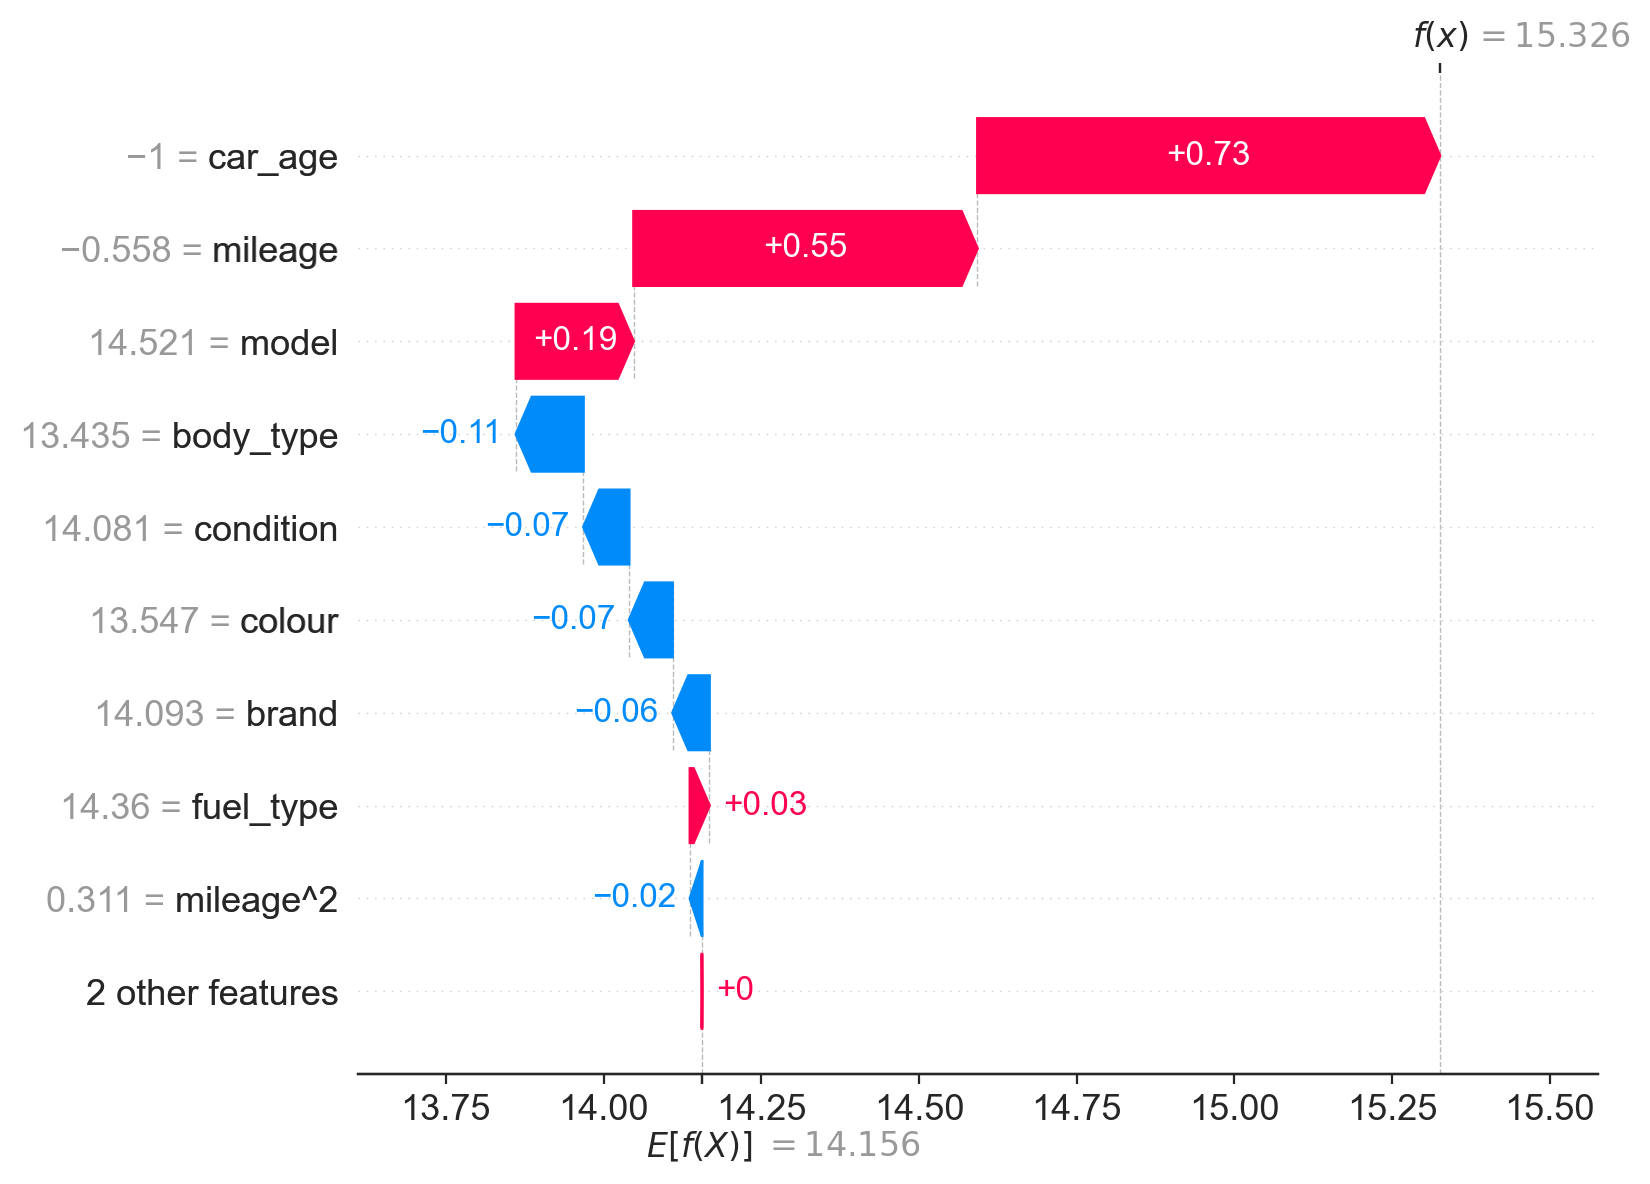

In [422]:
shap.plots.waterfall(lr_shap_values[0])

In [423]:
shap.plots.force(lr_shap_values[0])

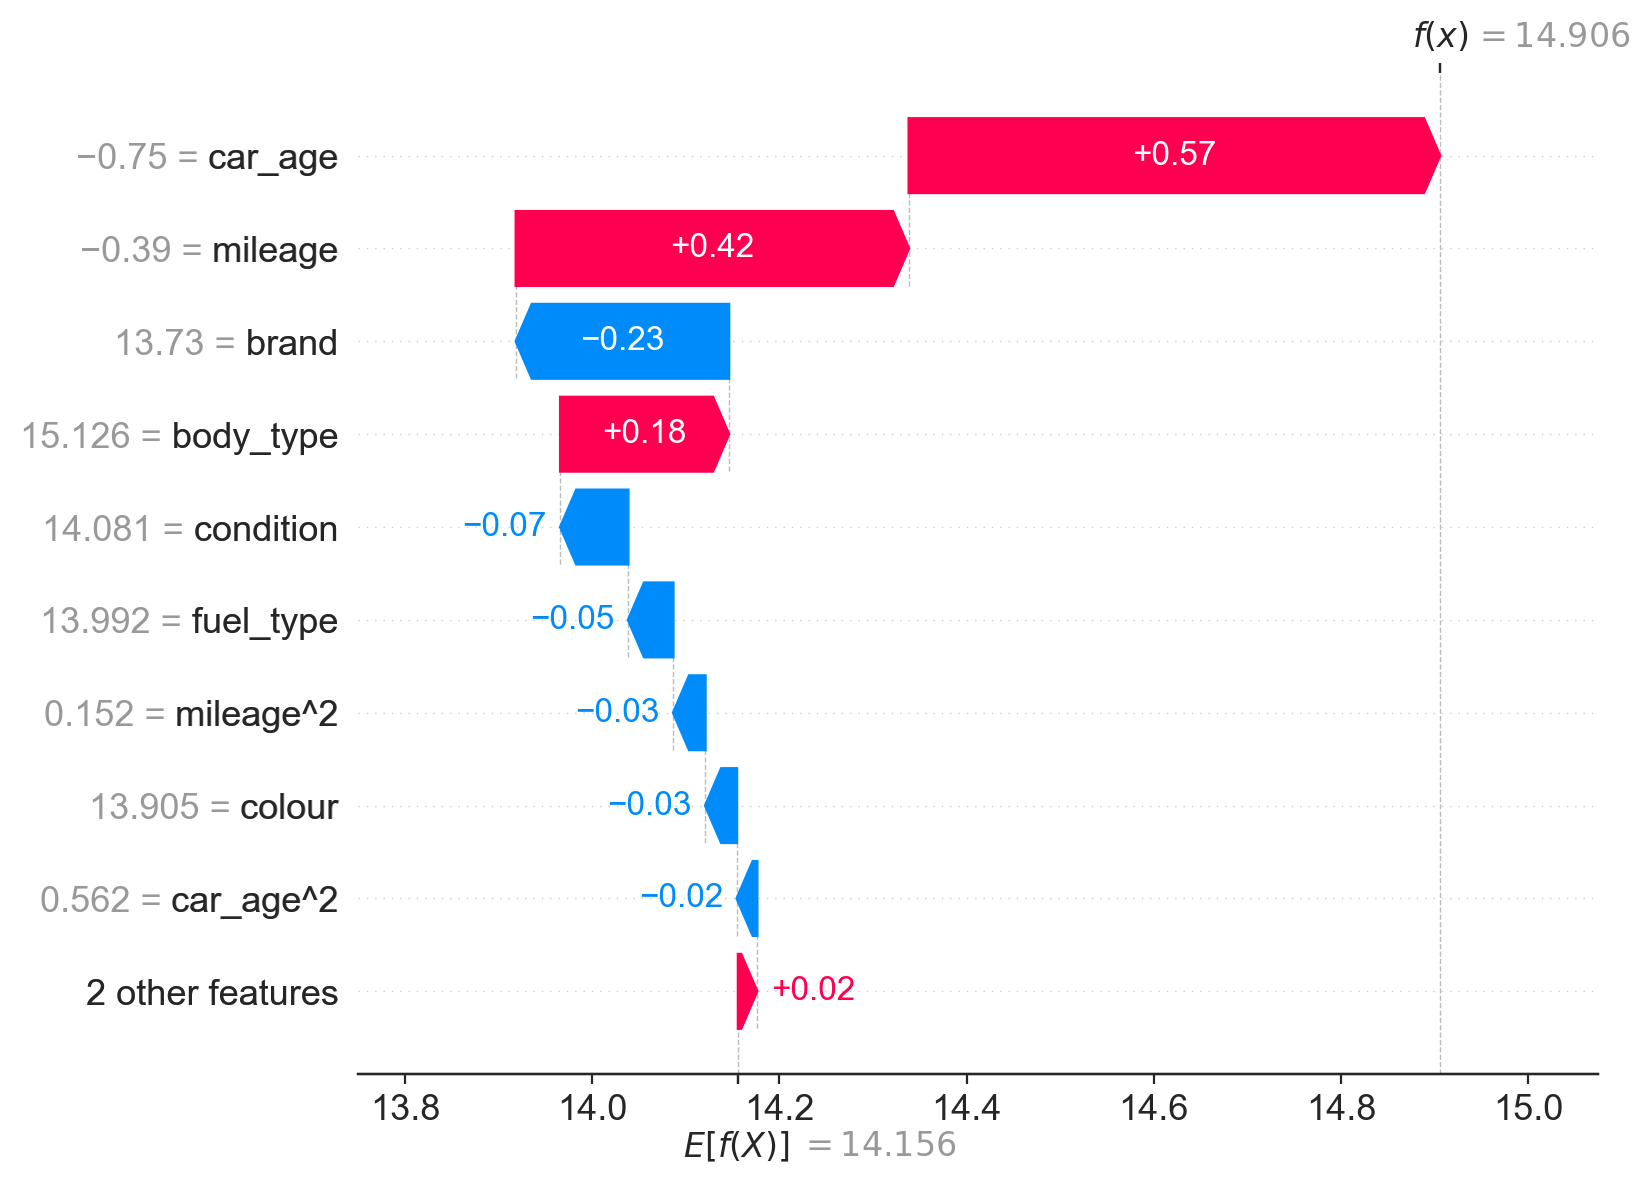

In [424]:
shap.waterfall_plot(lr_shap_values[1])

In [425]:
shap.plots.force(lr_shap_values[1])

"""

# linear regression (Global)

"""

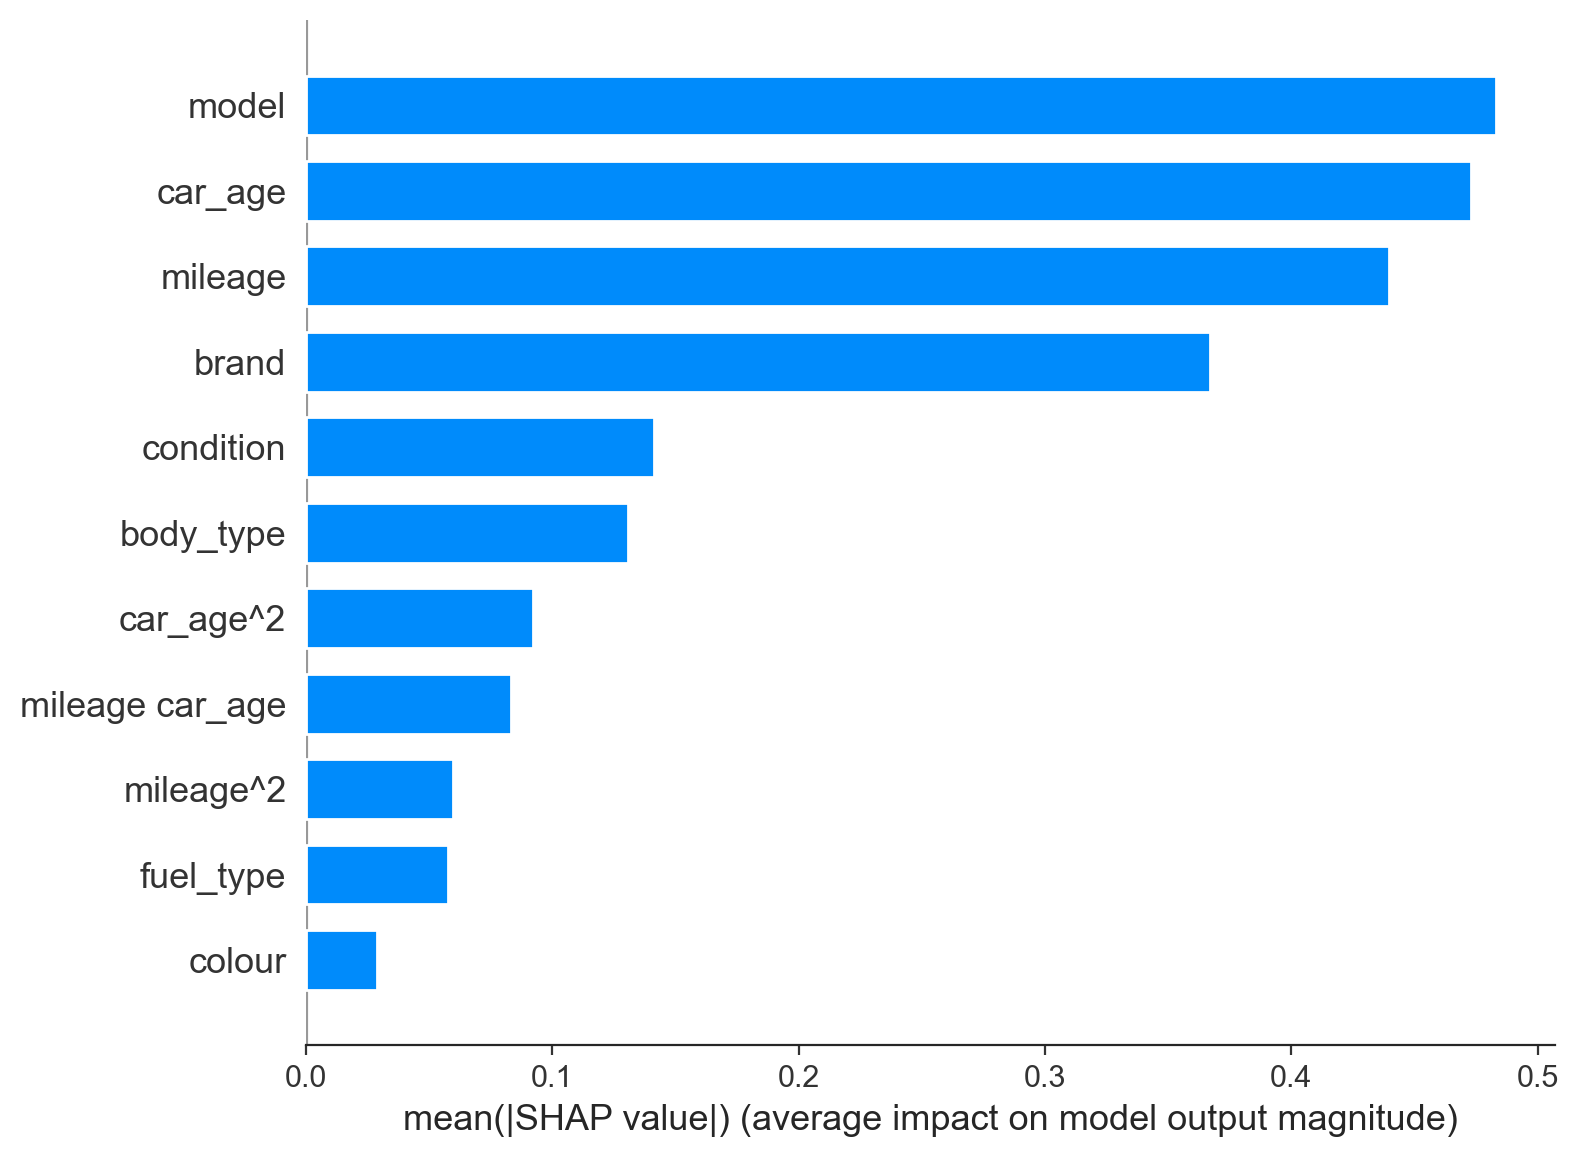

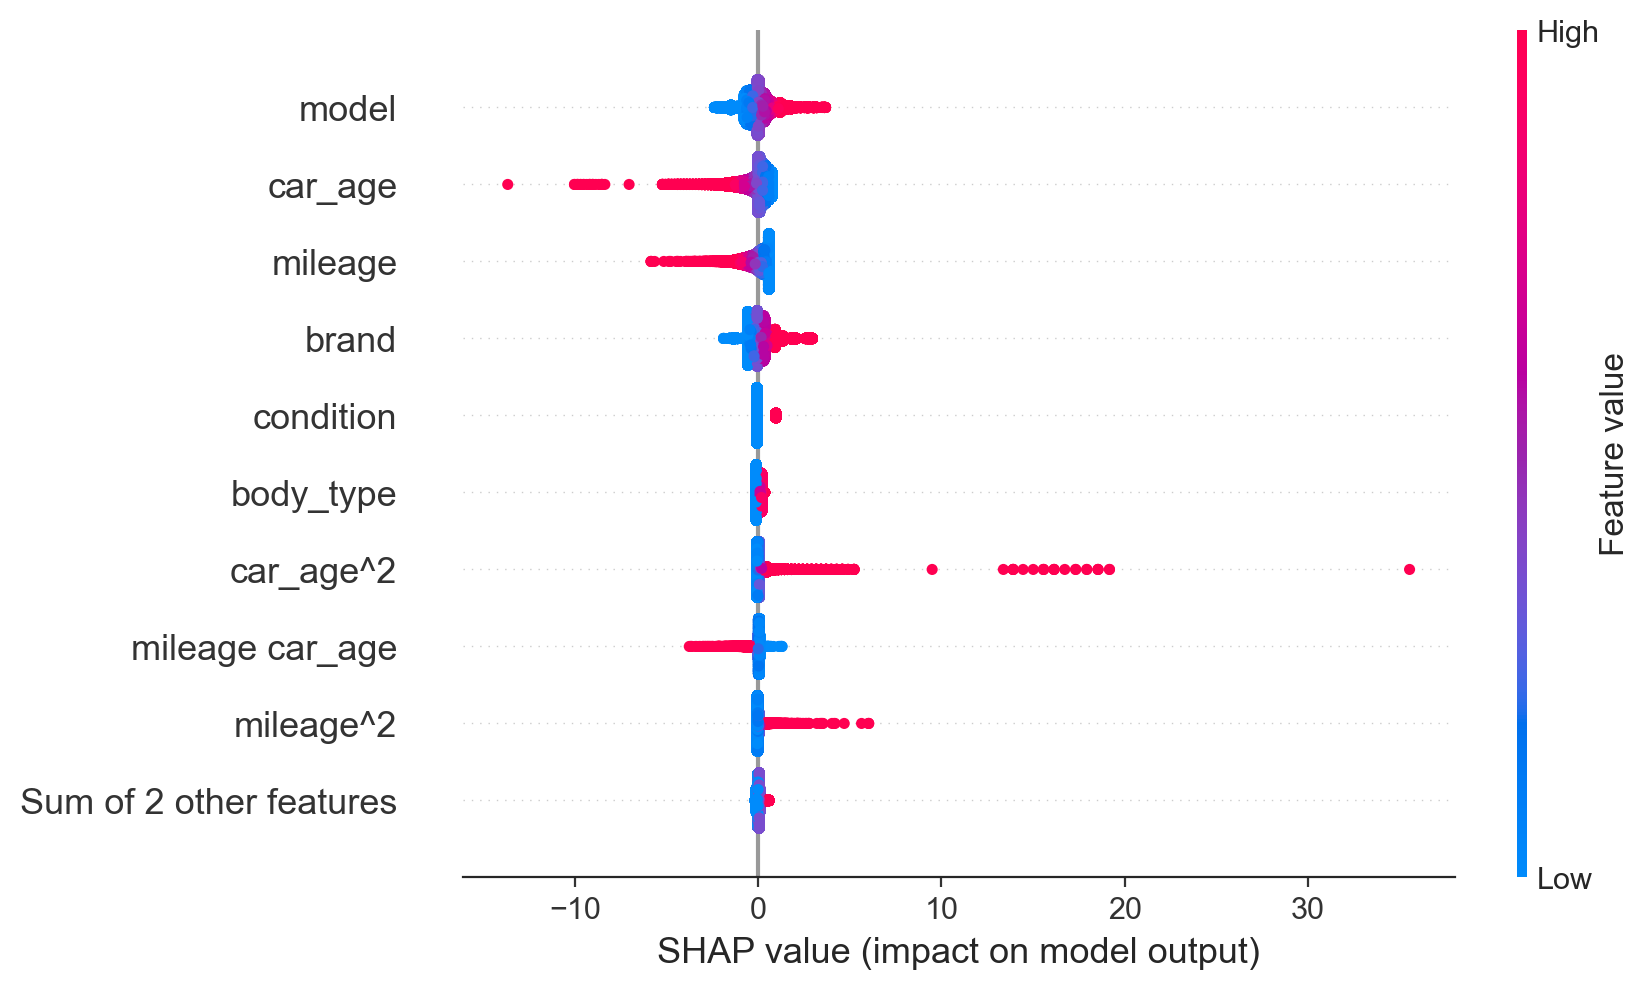

In [431]:
shap.summary_plot(lr_shap_values[:,:,0], plot_type="bar")
shap.plots.beeswarm(lr_shap_values[:, :, 0])

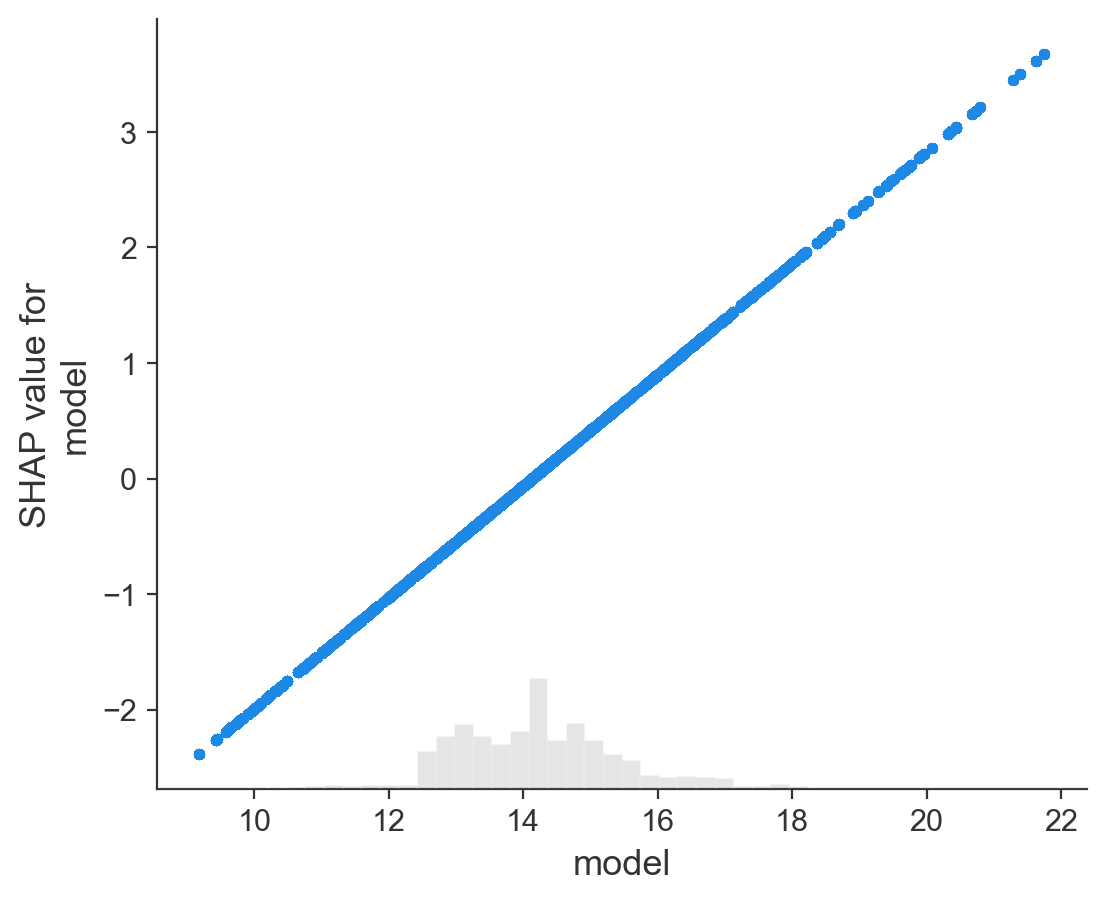

In [428]:
shap.plots.scatter(lr_shap_values[:, 'model'])

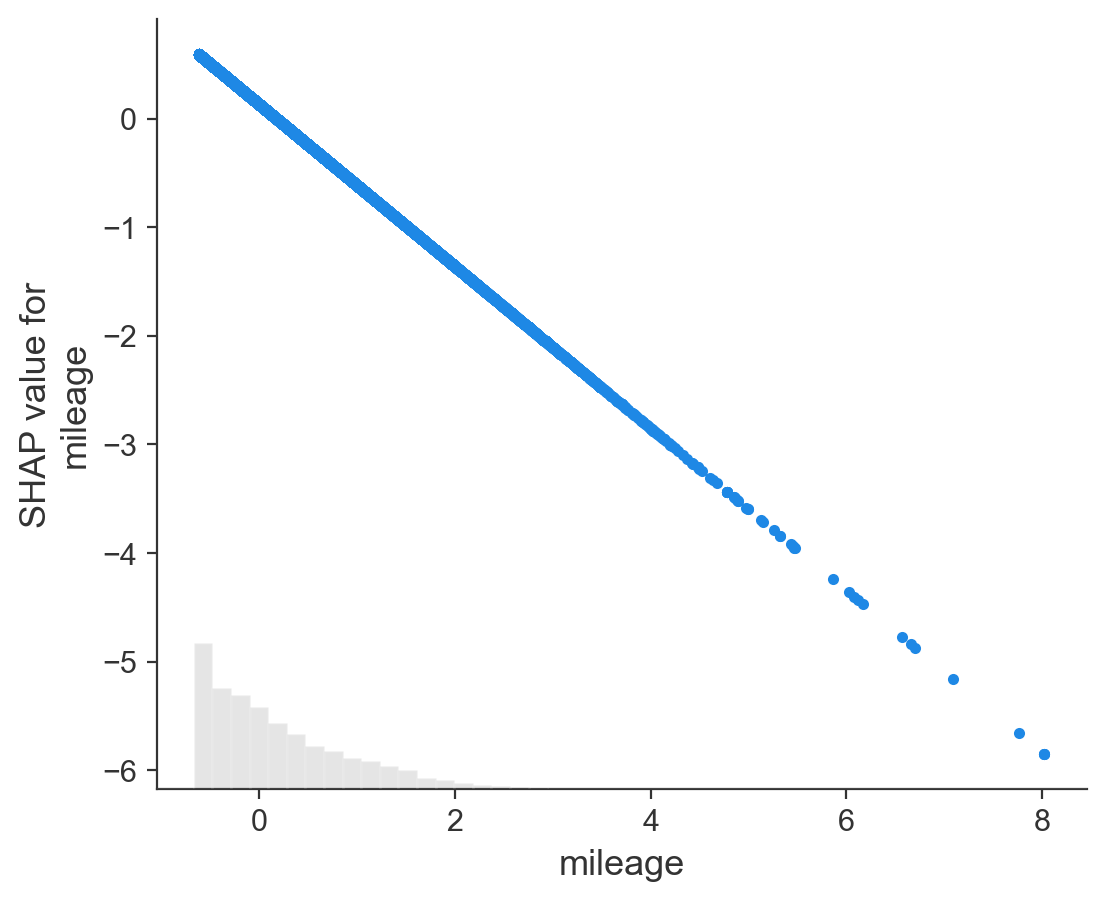

In [429]:
shap.plots.scatter(lr_shap_values[:, 'mileage'])

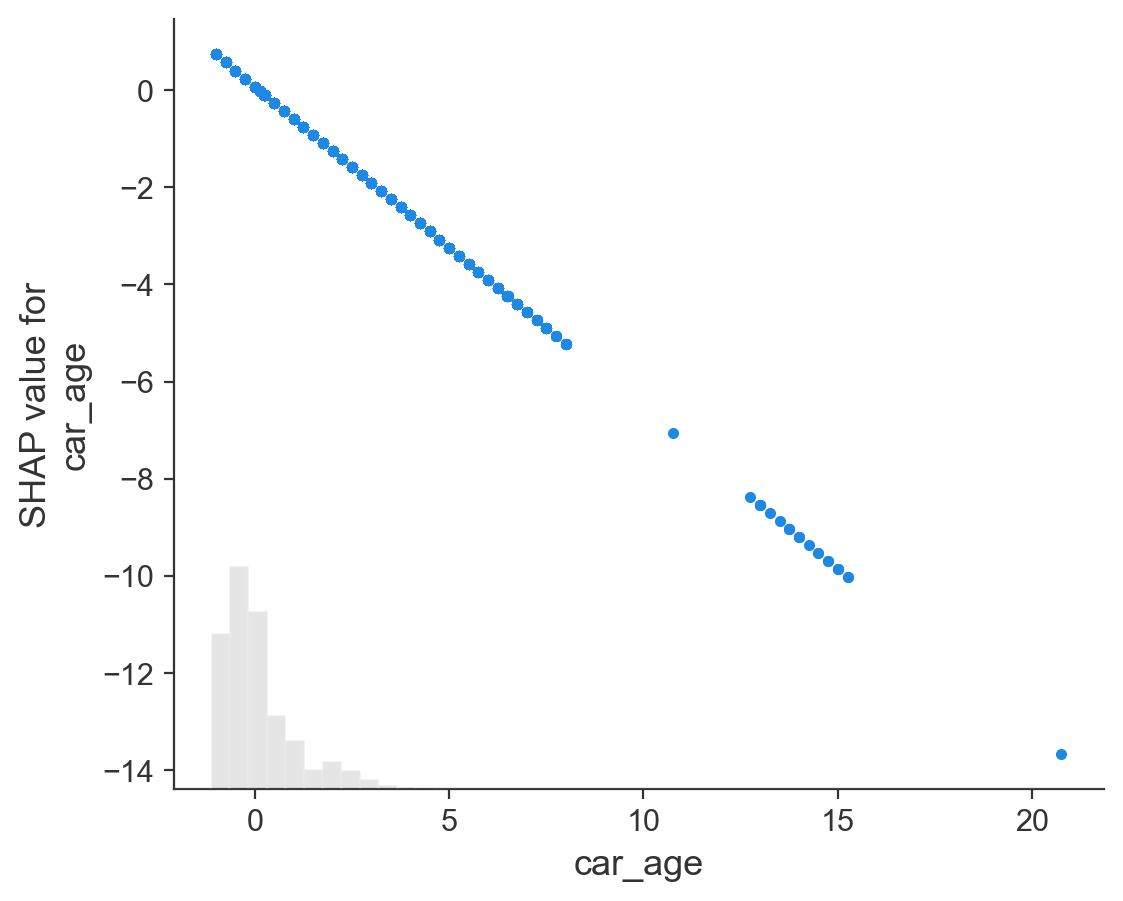

In [430]:
shap.plots.scatter(lr_shap_values[:, 'car_age'])

""" 


# random forest regressor (Local)


"""

In [432]:
rfr_model = rfr.named_steps['est']

In [433]:
X_rfr = rfr['pp'].fit_transform(X_train,y_train)

In [434]:
X_test_rfr = rfr['pp'].transform(X_test)

In [435]:
rfr_explainer = shap.TreeExplainer(rfr_model, X_rfr)
rfr_shap_values = rfr_explainer(X_test_rfr) 

100%|===================| 120198/120602 [04:08<00:00]        

In [436]:
rfr_shap_values

.values =
array([[ 6.59221170e-01,  4.82899802e-01, -1.89667503e-03, ...,
        -2.61837244e-05, -5.42856380e-05,  0.00000000e+00],
       [-4.51109501e-02,  4.85323102e-01, -2.23291051e-04, ...,
        -1.74558163e-05,  3.92178521e-04,  0.00000000e+00],
       [-7.51835373e-02, -1.48732342e+00, -9.03307423e-04, ...,
        -4.36395407e-05, -1.42327059e-03,  0.00000000e+00],
       ...,
       [ 6.98617206e-01,  3.82957326e-01,  7.50714661e-03, ...,
         2.79293060e-04,  2.85788234e-04,  0.00000000e+00],
       [-9.65026111e-02, -5.07766201e-01,  1.79917837e-03, ...,
        -4.36395407e-05,  5.78091778e-04,  0.00000000e+00],
       [-9.90786022e-02, -1.74732320e+00, -8.24519210e-04, ...,
        -4.36395407e-05, -2.33142836e-03,  0.00000000e+00]])

.base_values =
array([14.14930803, 14.14930803, 14.14930803, ..., 14.14930803,
       14.14930803, 14.14930803])

.data =
array([[-5.57556638e-01, -1.00000000e+00,  3.10869405e-01, ...,
         1.40809823e+01,  1.34351406e+01,  1.4

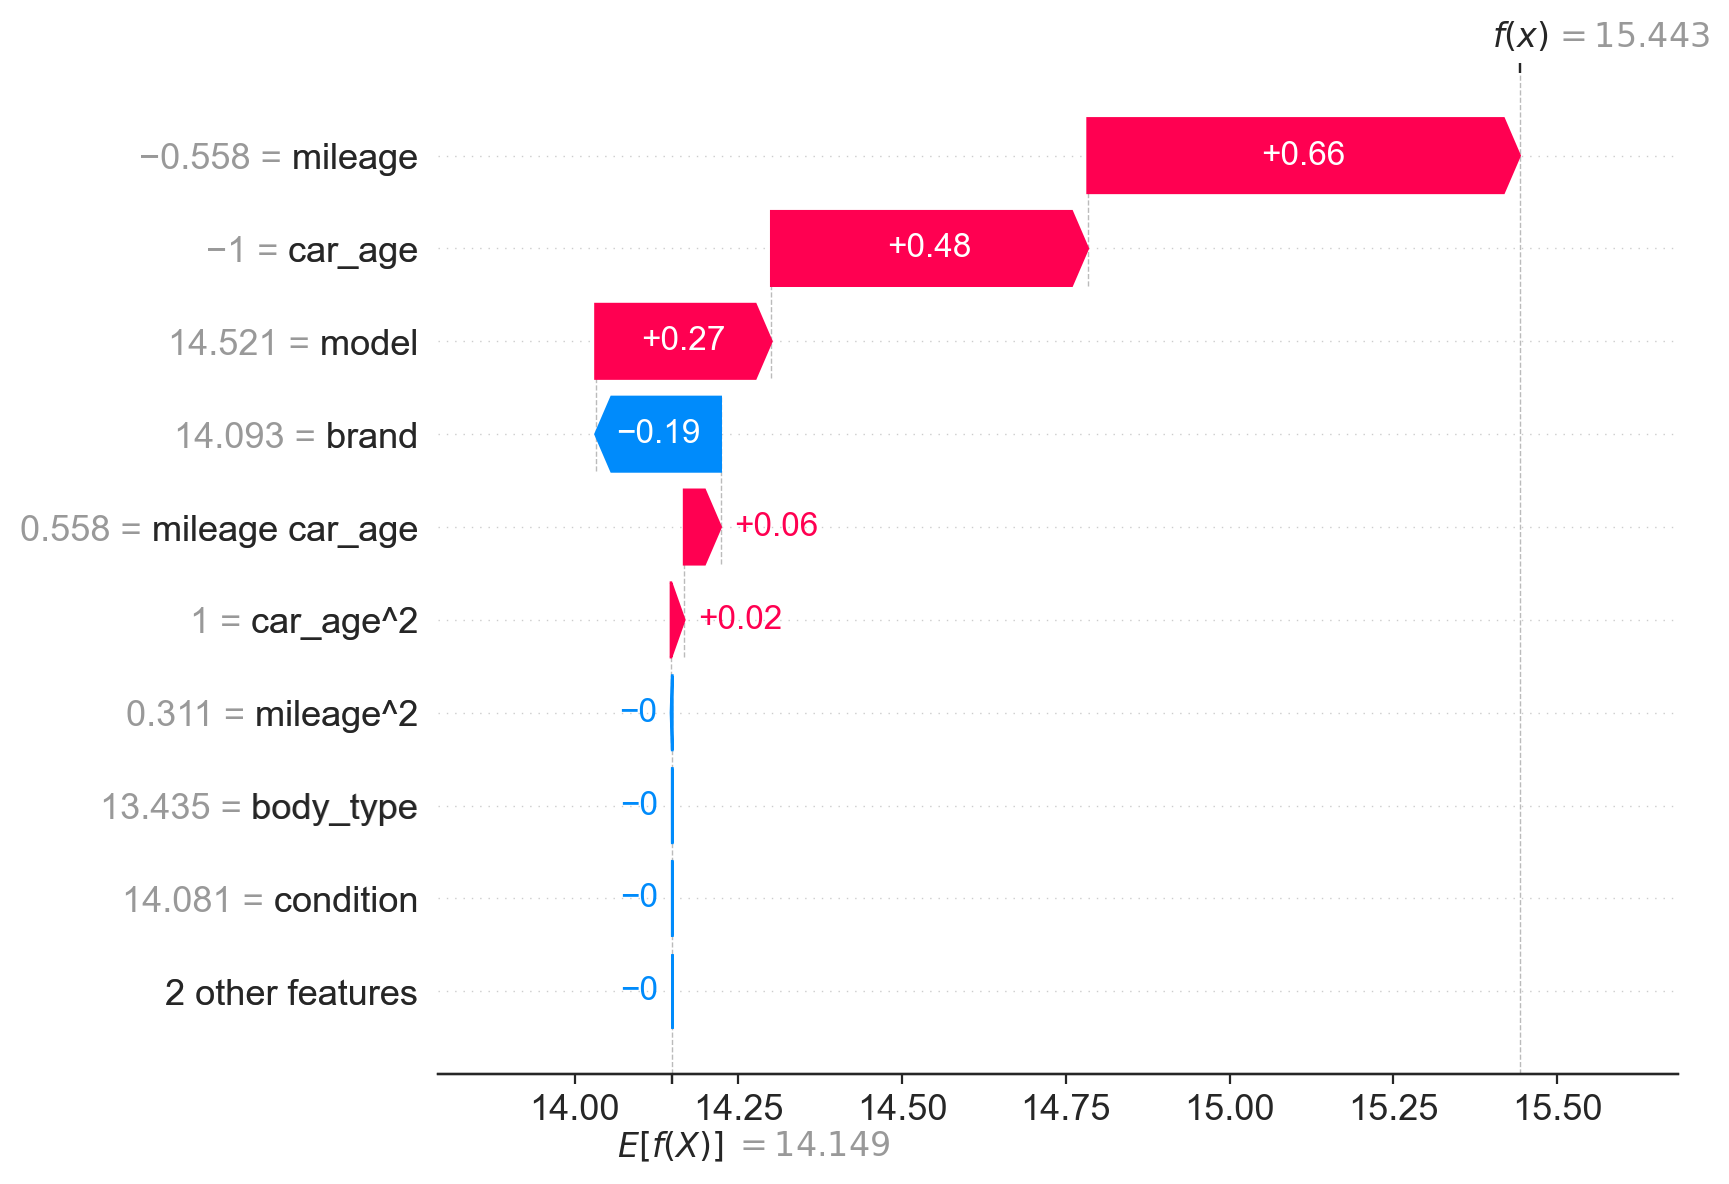

In [437]:
shap.plots.waterfall(rfr_shap_values[0])

In [438]:
shap.plots.force(rfr_shap_values[0])

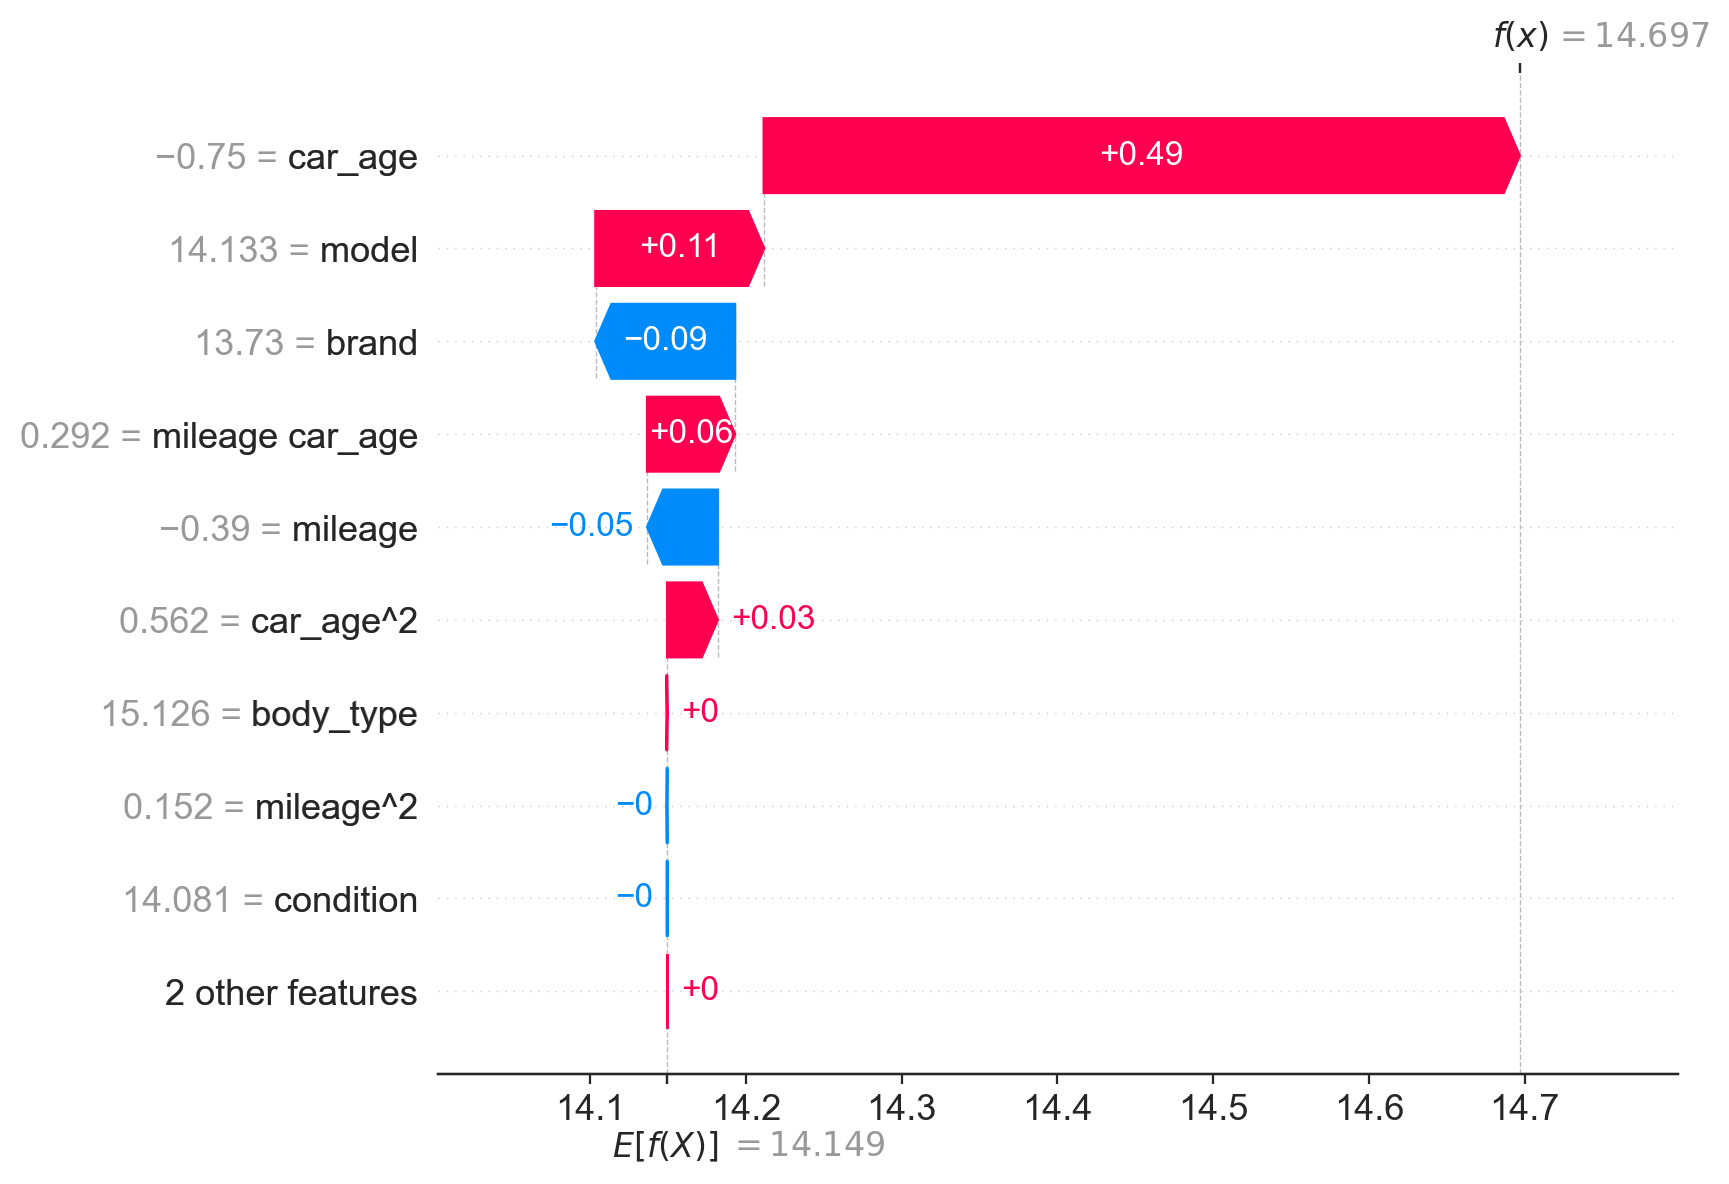

In [439]:
shap.waterfall_plot(rfr_shap_values[1])

In [440]:
shap.plots.force(rfr_shap_values[1])

"""

# random forest regressor (Global)

"""

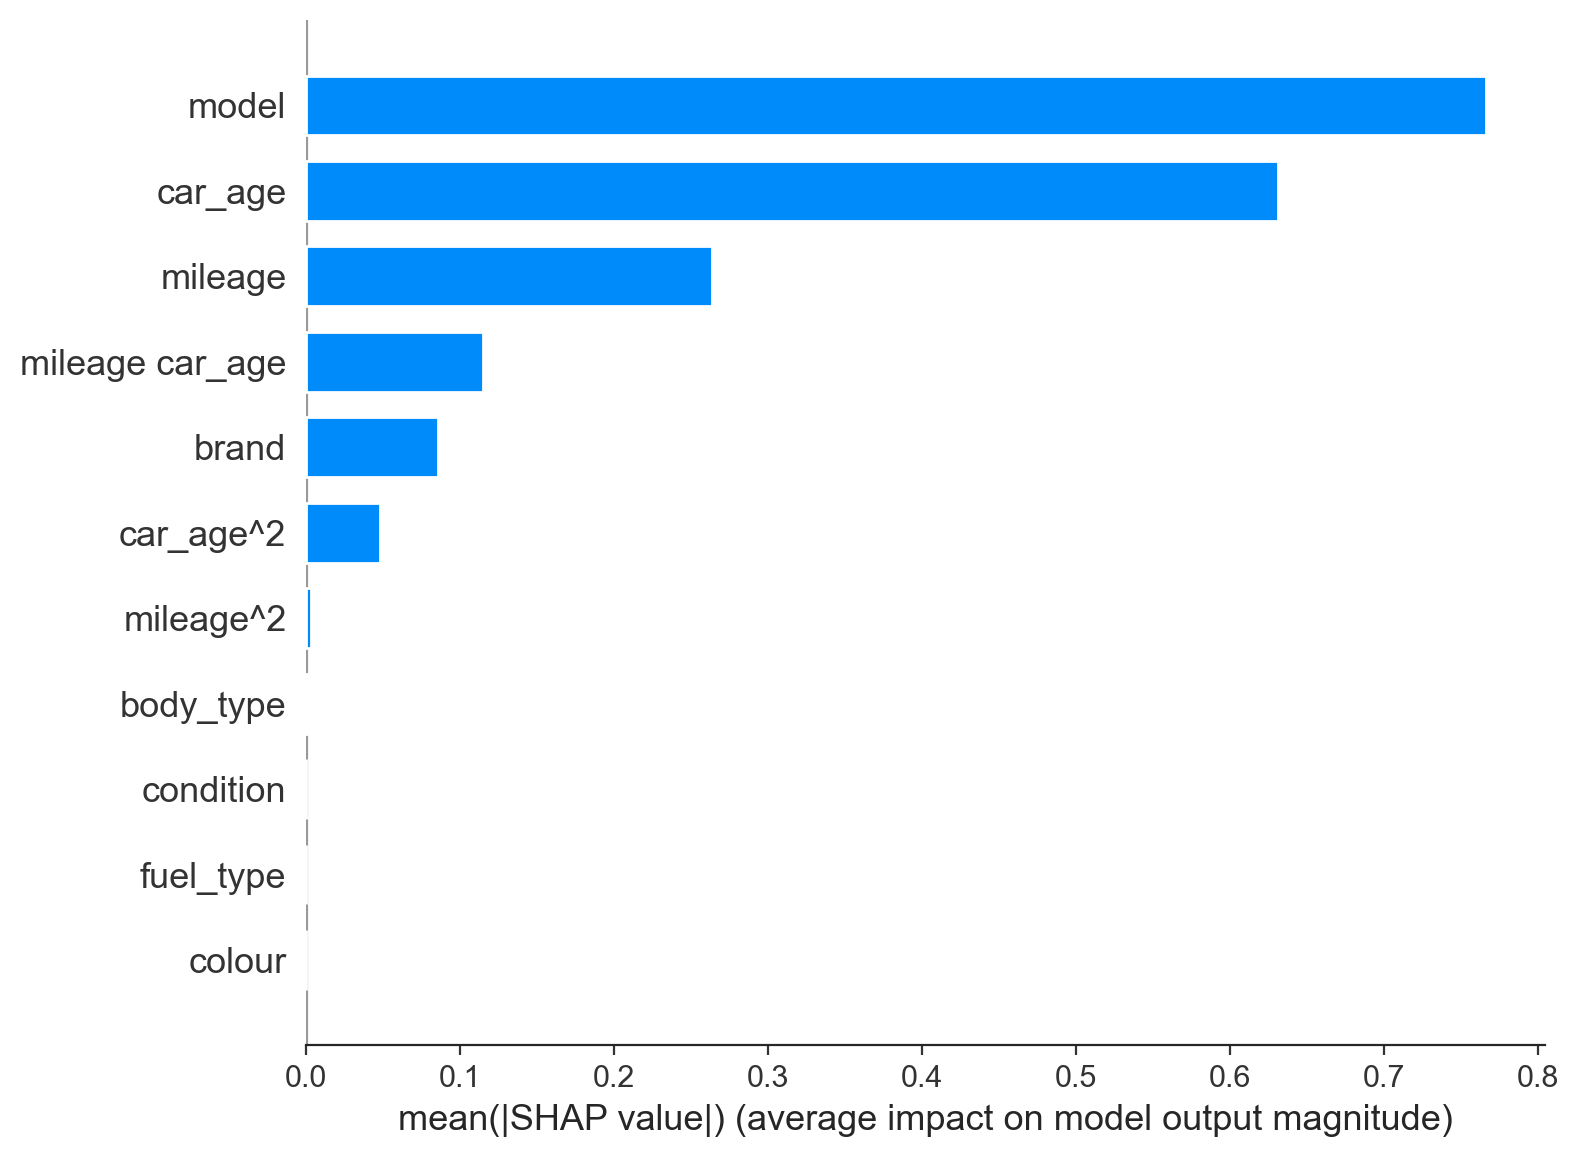

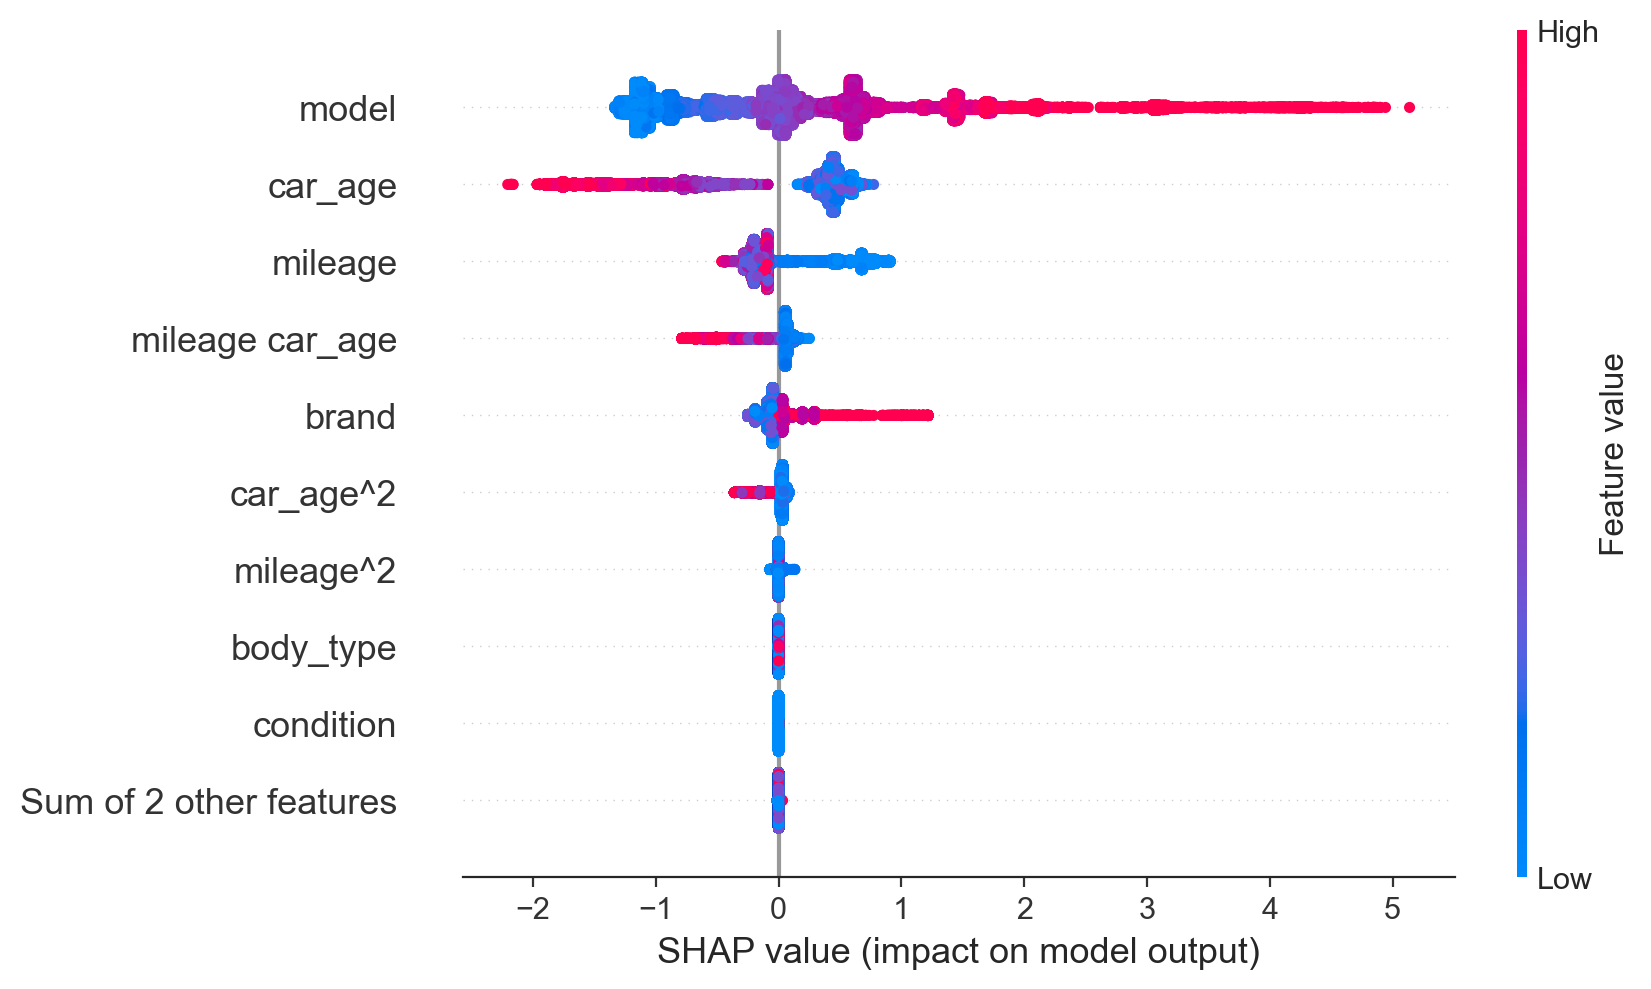

In [445]:
shap.summary_plot(rfr_shap_values, plot_type="bar")
shap.plots.beeswarm(rfr_shap_values)

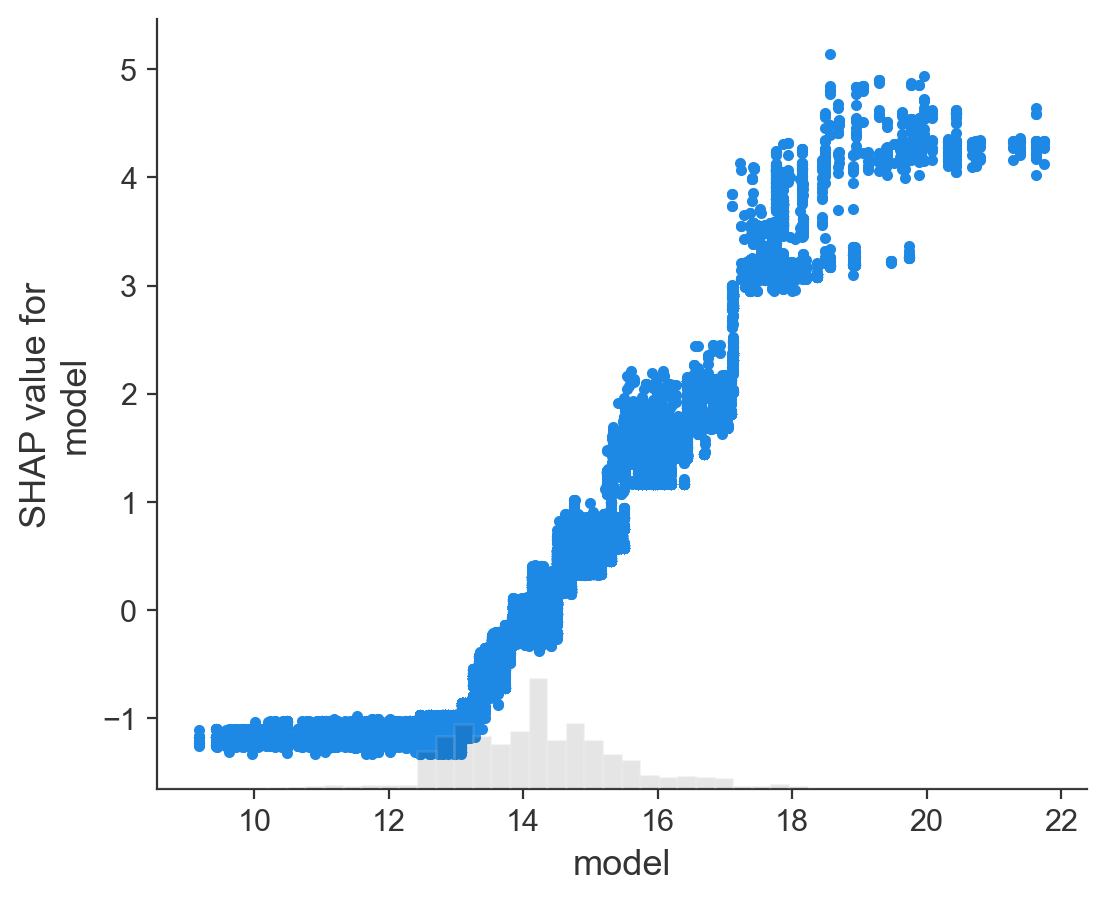

In [442]:
shap.plots.scatter(rfr_shap_values[:, 'model'])

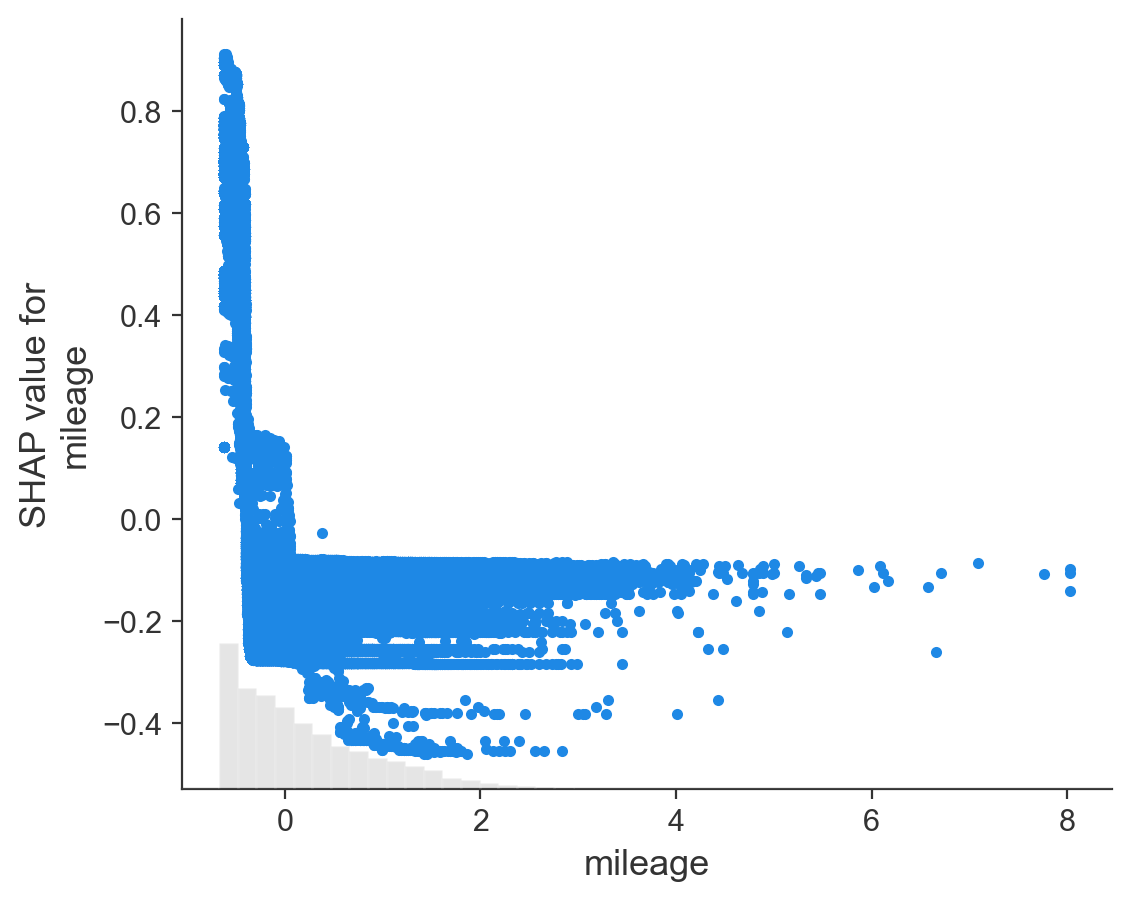

In [443]:
shap.plots.scatter(rfr_shap_values[:, 'mileage'])

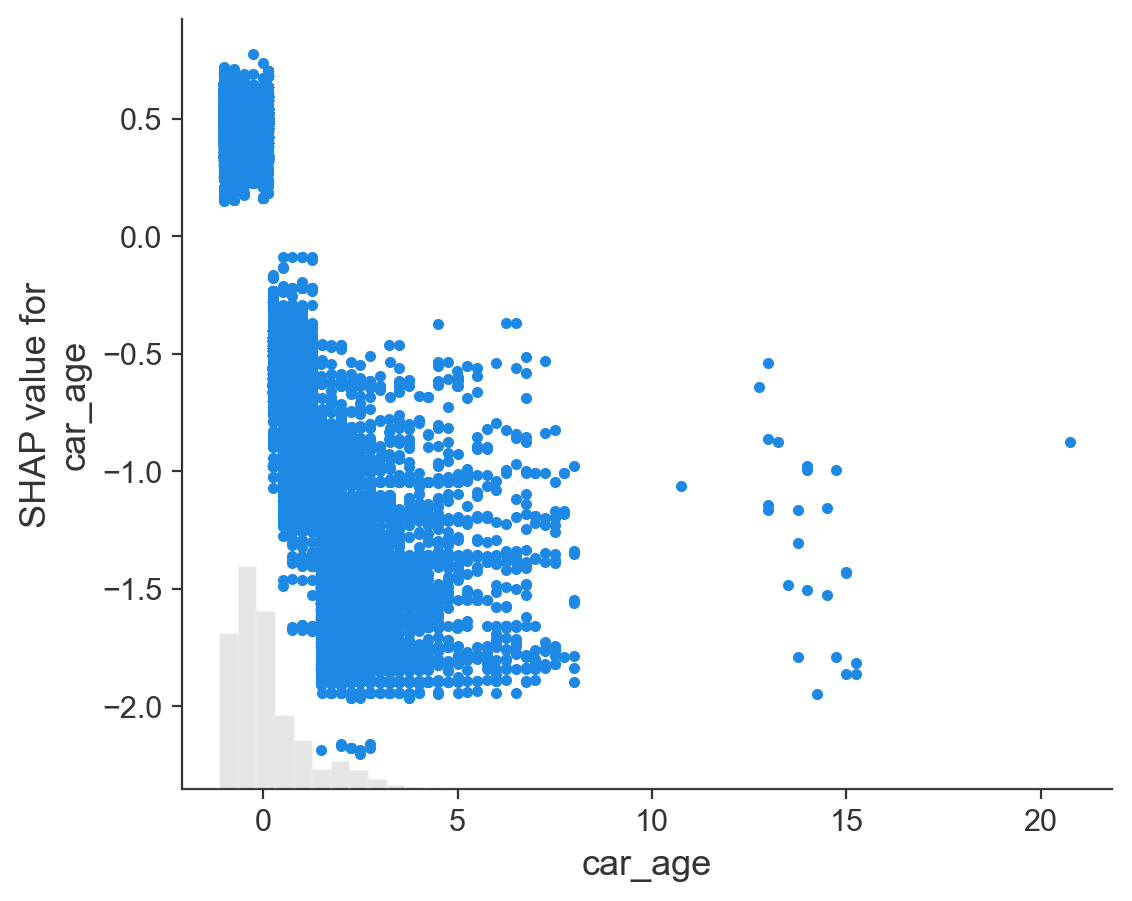

In [444]:
shap.plots.scatter(rfr_shap_values[:, 'car_age'])

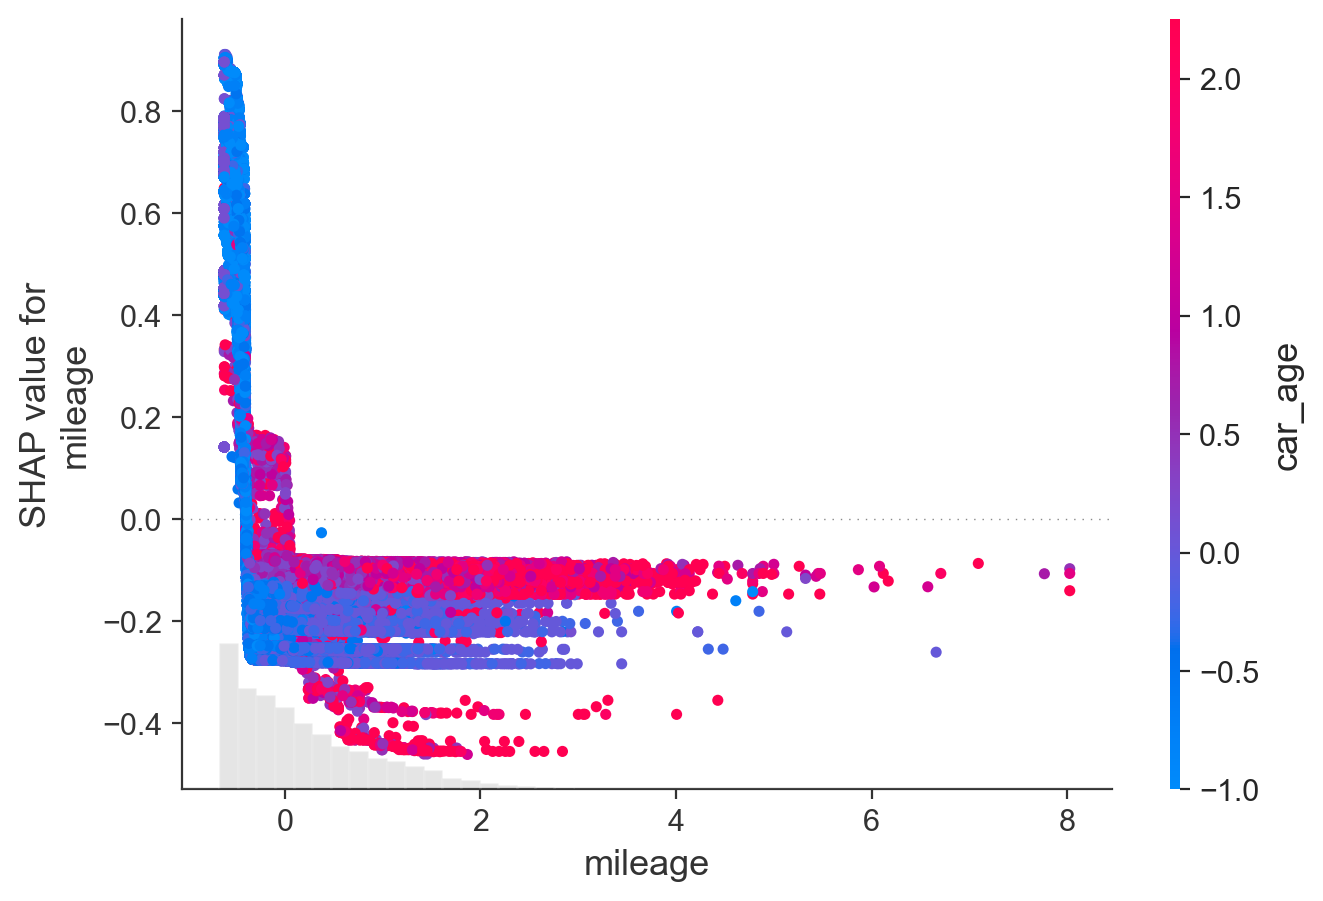

In [447]:
shap.plots.scatter(rfr_shap_values[:,"mileage"], color=rfr_shap_values[:,"car_age"])

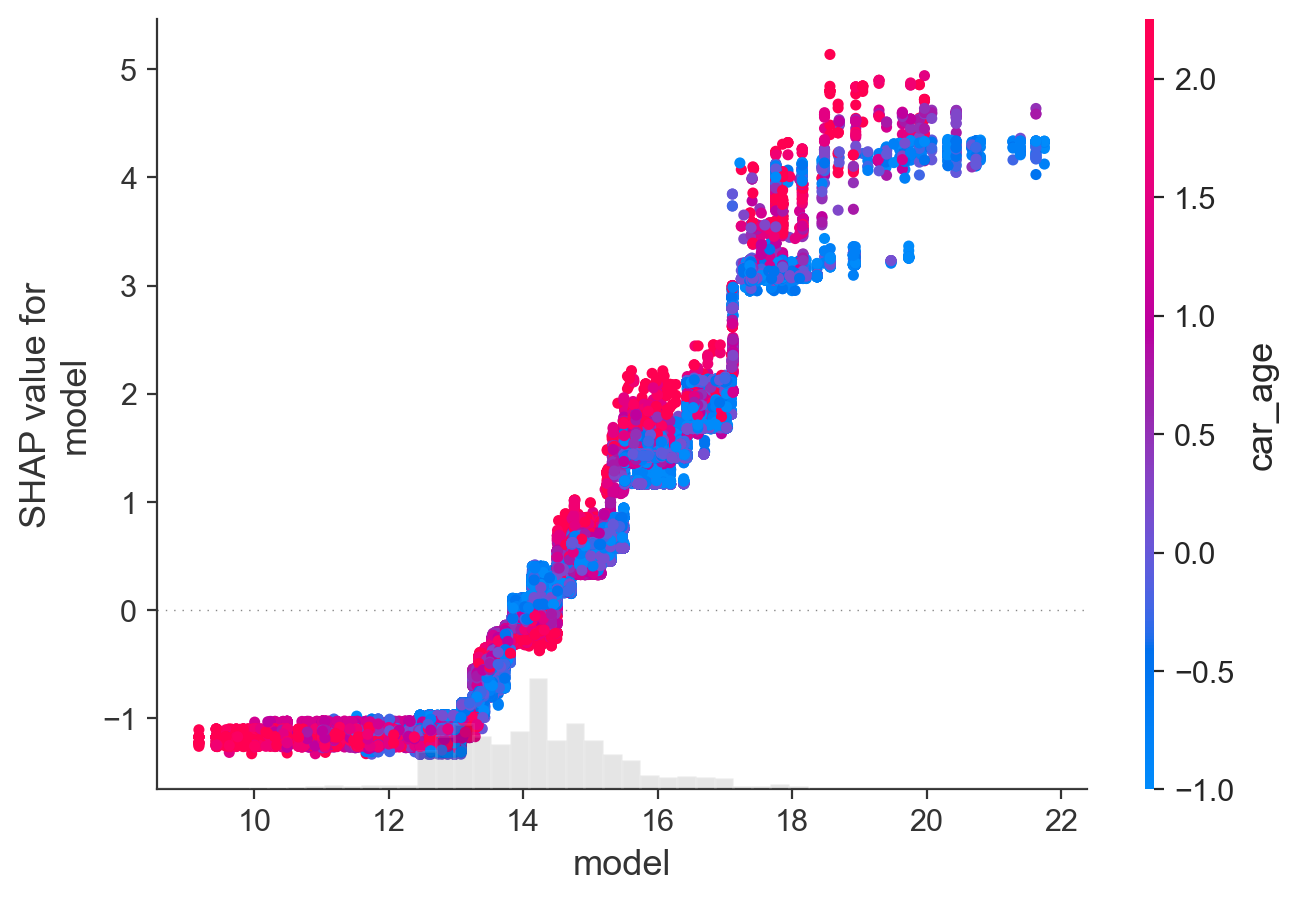

In [448]:
shap.plots.scatter(rfr_shap_values[:,"model"], color=rfr_shap_values[:,"car_age"])

""" 


# gradient boosting regressor (Local)


"""

In [449]:
gbr_model = gbr.named_steps['est']

In [450]:
X_gbr = gbr['pp'].fit_transform(X_train,y_train)

In [451]:
X_test_gbr = gbr['pp'].transform(X_test)

In [452]:
gbr_explainer = shap.TreeExplainer(gbr_model, X_gbr)
gbr_shap_values = gbr_explainer(X_test_gbr) 

100%|===================| 120576/120602 [01:57<00:00]        

In [453]:
gbr_shap_values

.values =
array([[ 0.74958704,  0.4847788 ,  0.01303548, ..., -0.00899165,
         0.03063819,  0.05491622],
       [ 0.25880863,  0.46376597,  0.00968163, ..., -0.01054599,
         0.07927165, -0.04770133],
       [ 0.06402478, -1.0443071 ,  0.01380198, ..., -0.0103227 ,
        -0.17786586, -0.03299309],
       ...,
       [ 1.02853157,  0.20345166,  0.01600315, ...,  0.11663943,
         0.22357005, -0.01852468],
       [-0.44214066, -0.37149239,  0.00129643, ..., -0.01190648,
         0.12568288, -0.02970047],
       [-0.62163141, -1.1863468 , -0.06531083, ..., -0.01506734,
        -0.17900936, -0.04185349]])

.base_values =
array([14.13427191, 14.13427191, 14.13427191, ..., 14.13427191,
       14.13427191, 14.13427191])

.data =
array([[-5.57556638e-01, -1.00000000e+00,  3.10869405e-01, ...,
         1.40809823e+01,  1.34351406e+01,  1.43599710e+01],
       [-3.89559318e-01, -7.50000000e-01,  1.51756462e-01, ...,
         1.40809823e+01,  1.51257540e+01,  1.39922129e+01],
      

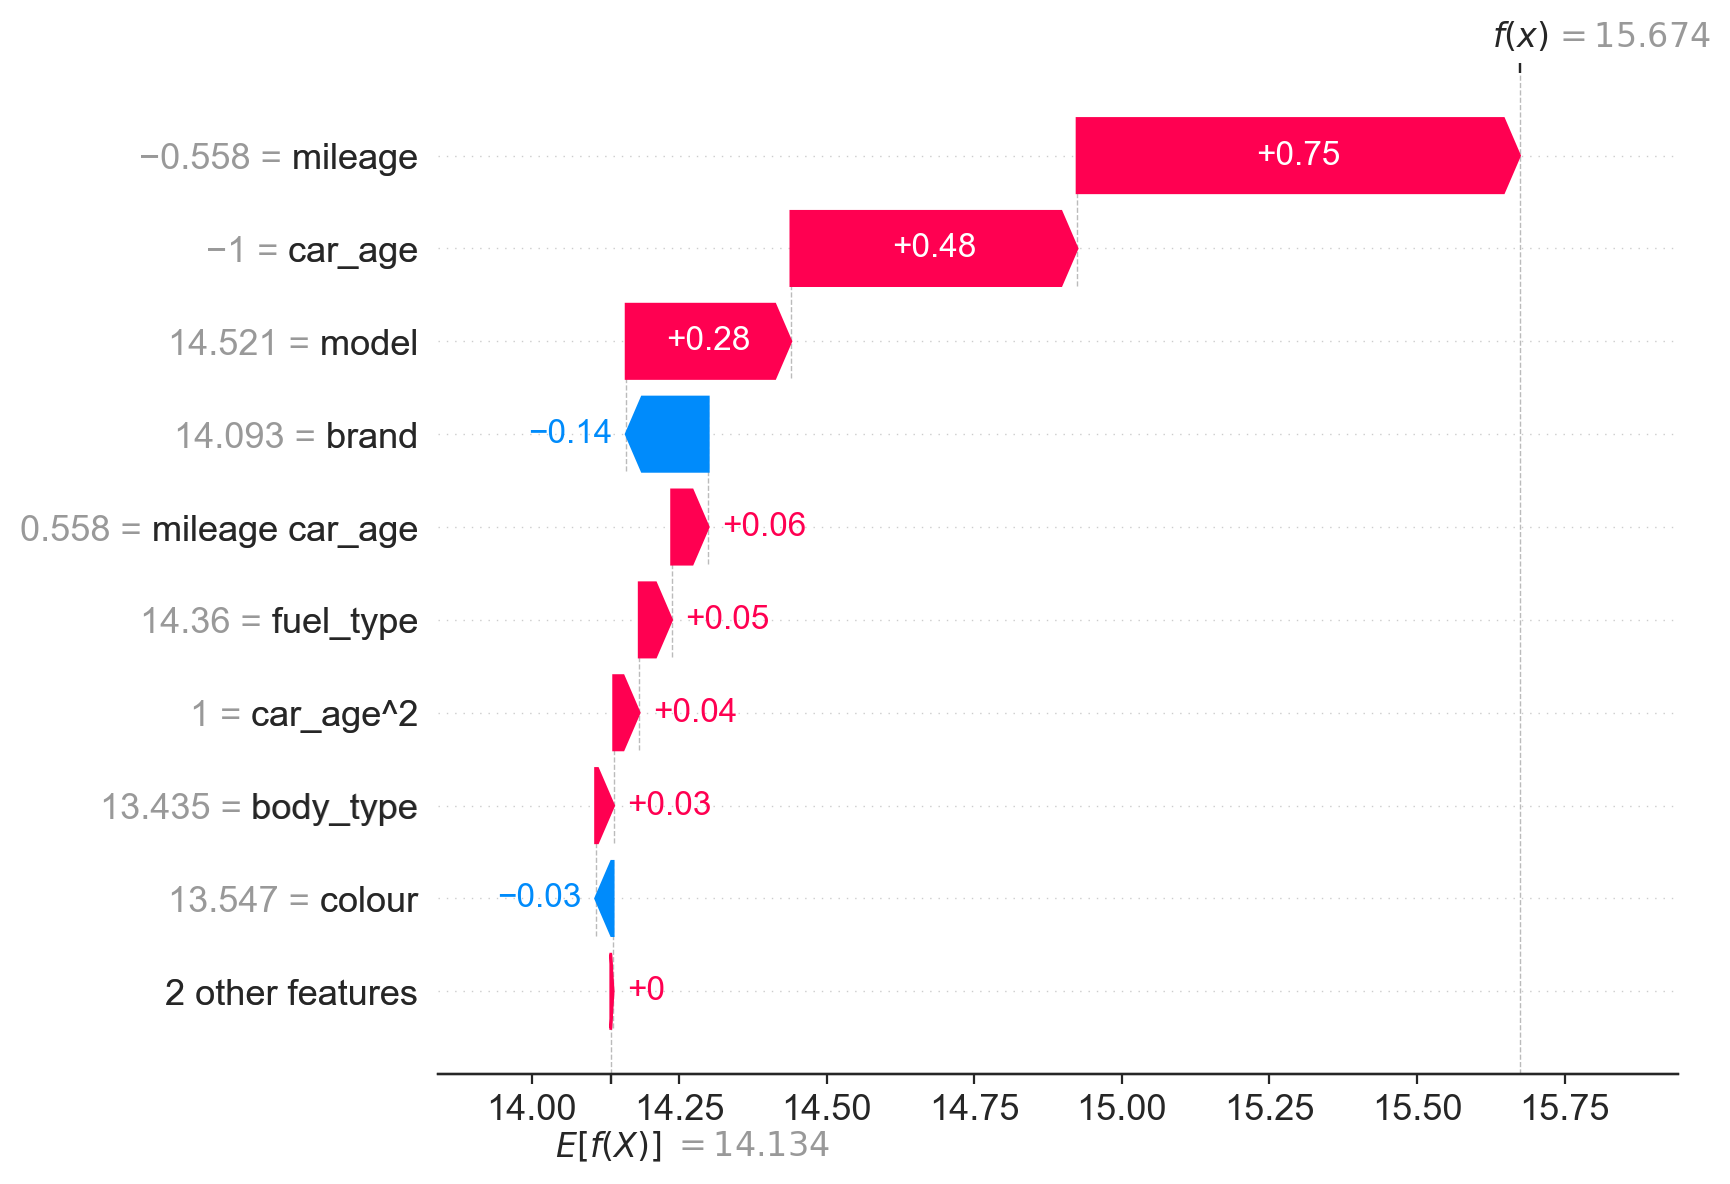

In [454]:
shap.plots.waterfall(gbr_shap_values[0])

In [455]:
shap.plots.force(gbr_shap_values[0])

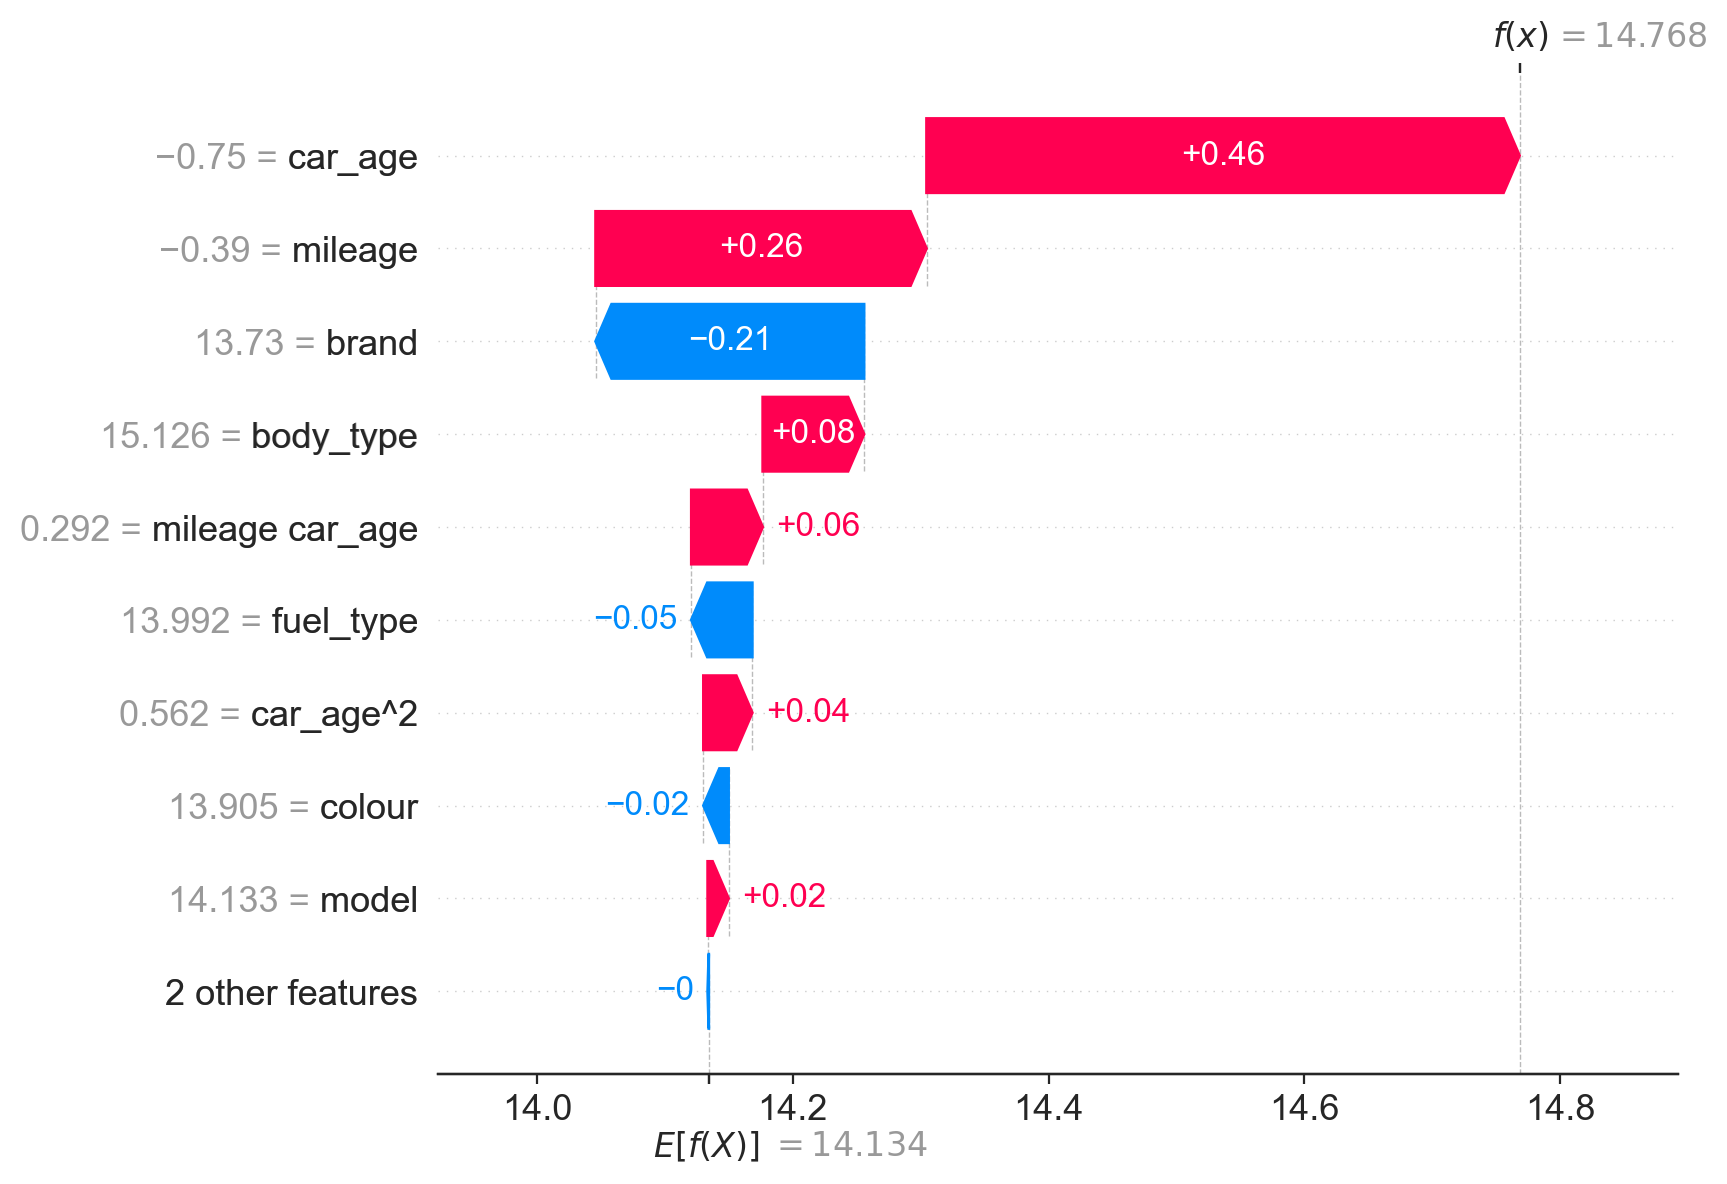

In [456]:
shap.waterfall_plot(gbr_shap_values[1])

In [457]:
shap.plots.force(gbr_shap_values[1])

""" 


# gradient boosting regressor (Global)


"""

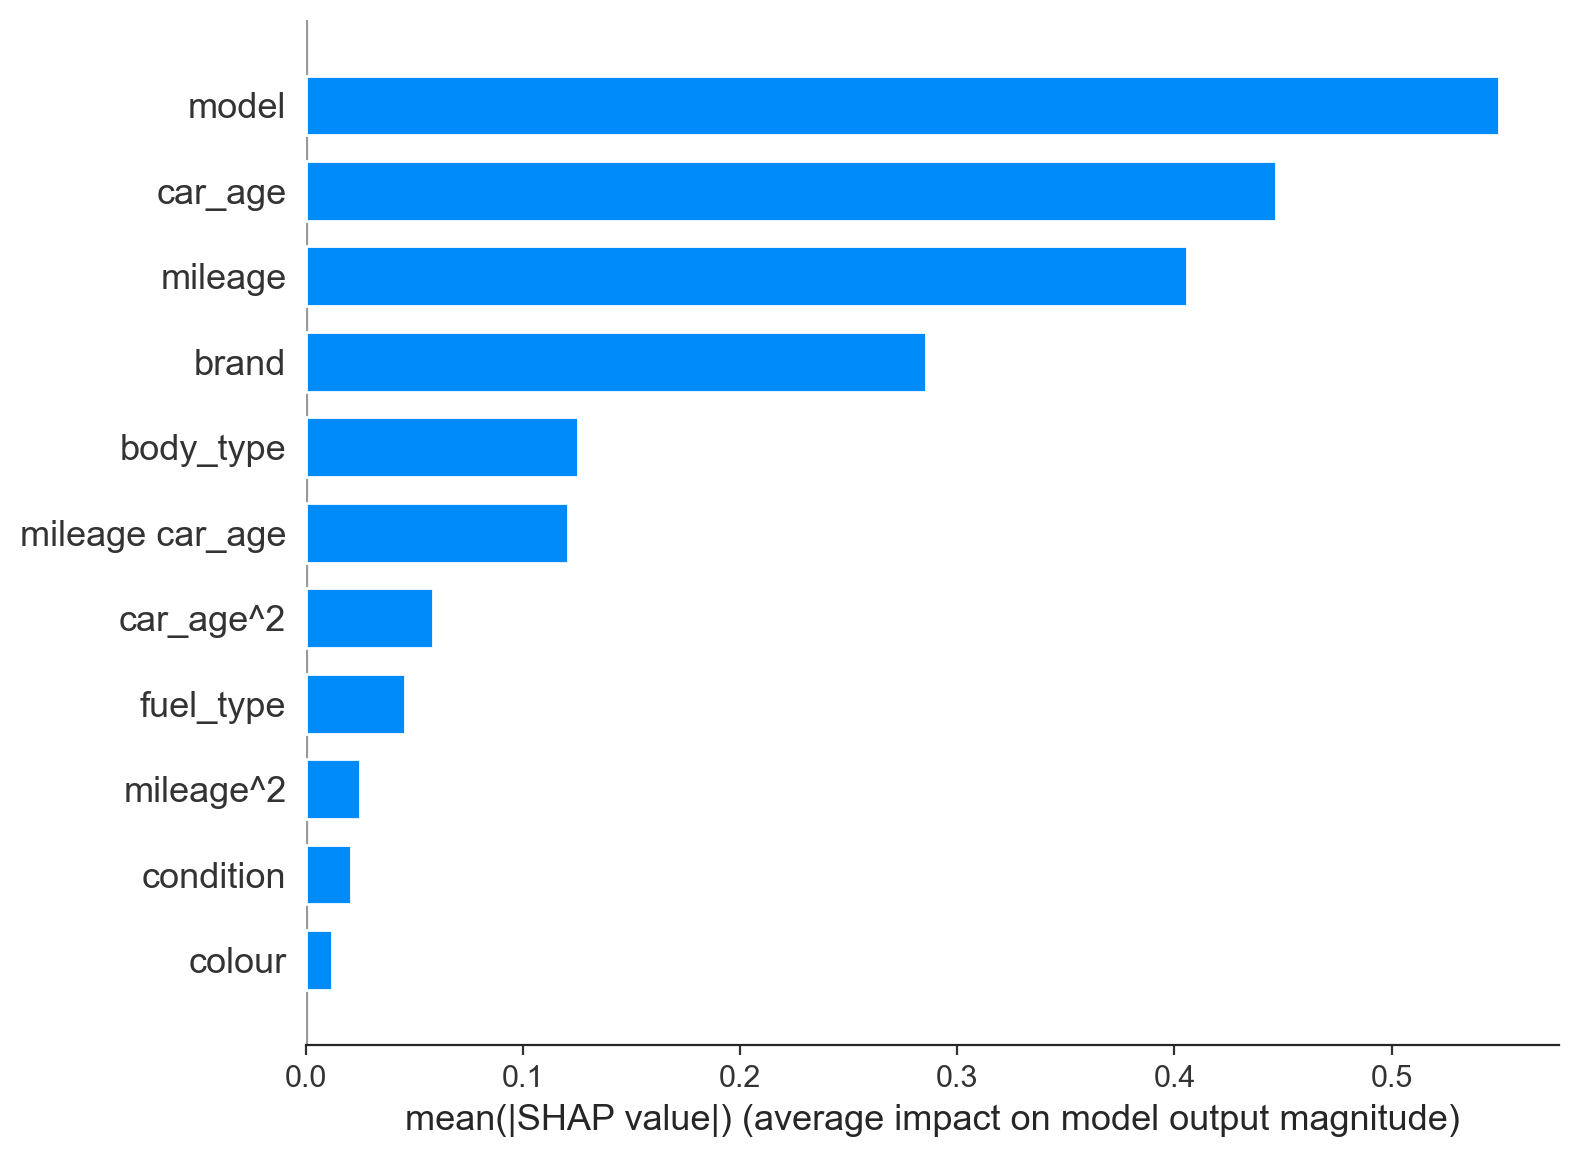

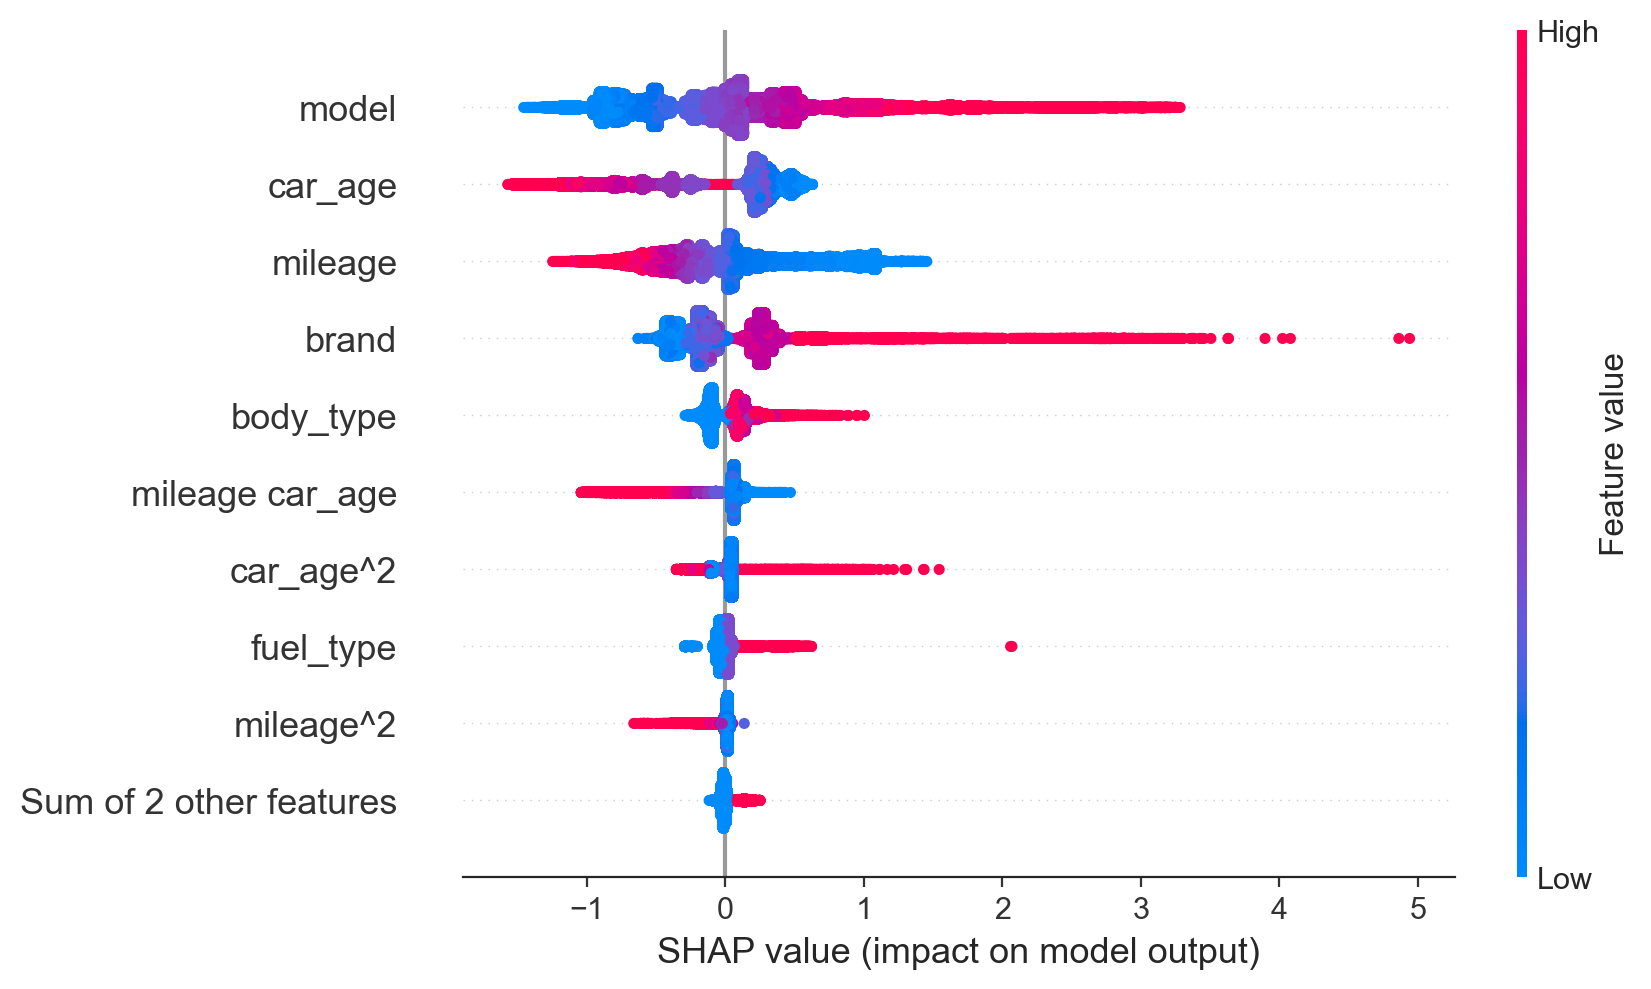

In [458]:
shap.summary_plot(gbr_shap_values, plot_type="bar")
shap.plots.beeswarm(gbr_shap_values)

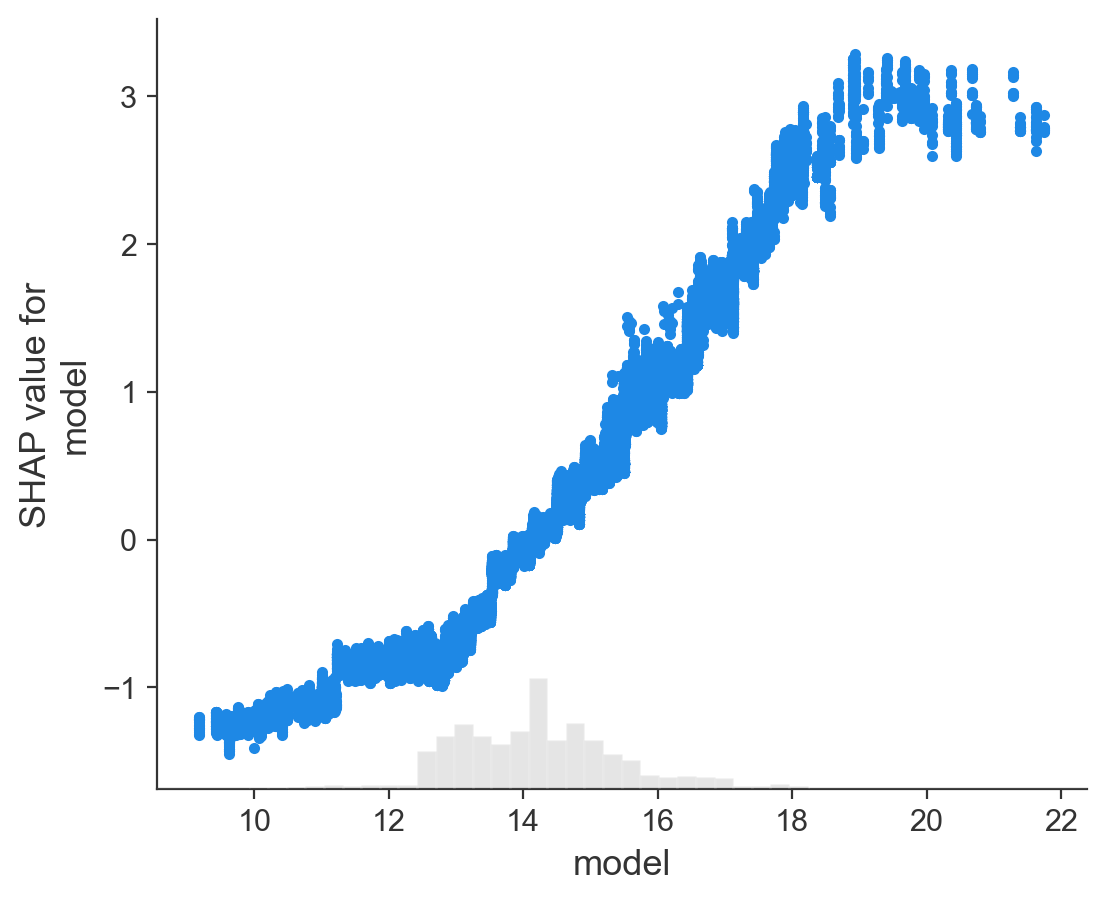

In [459]:
shap.plots.scatter(gbr_shap_values[:, 'model'])

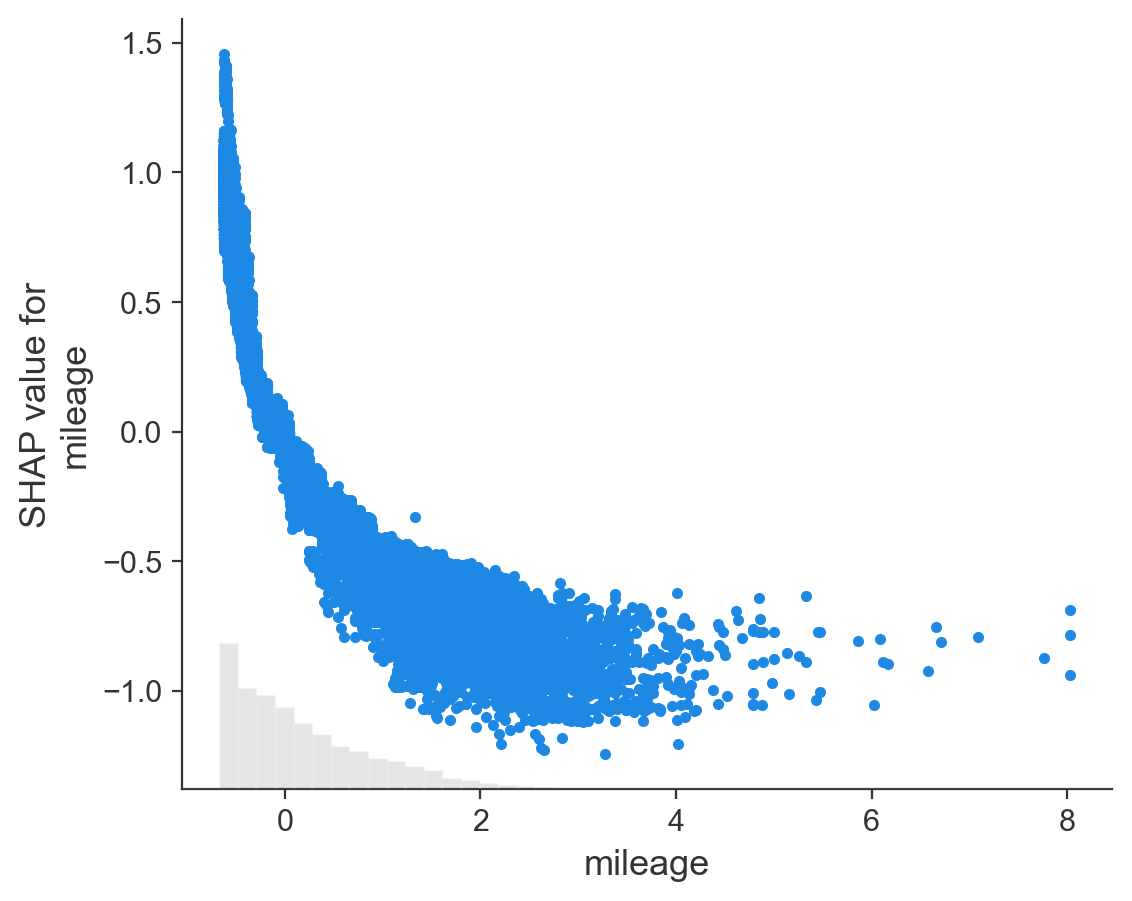

In [460]:
shap.plots.scatter(gbr_shap_values[:, 'mileage'])

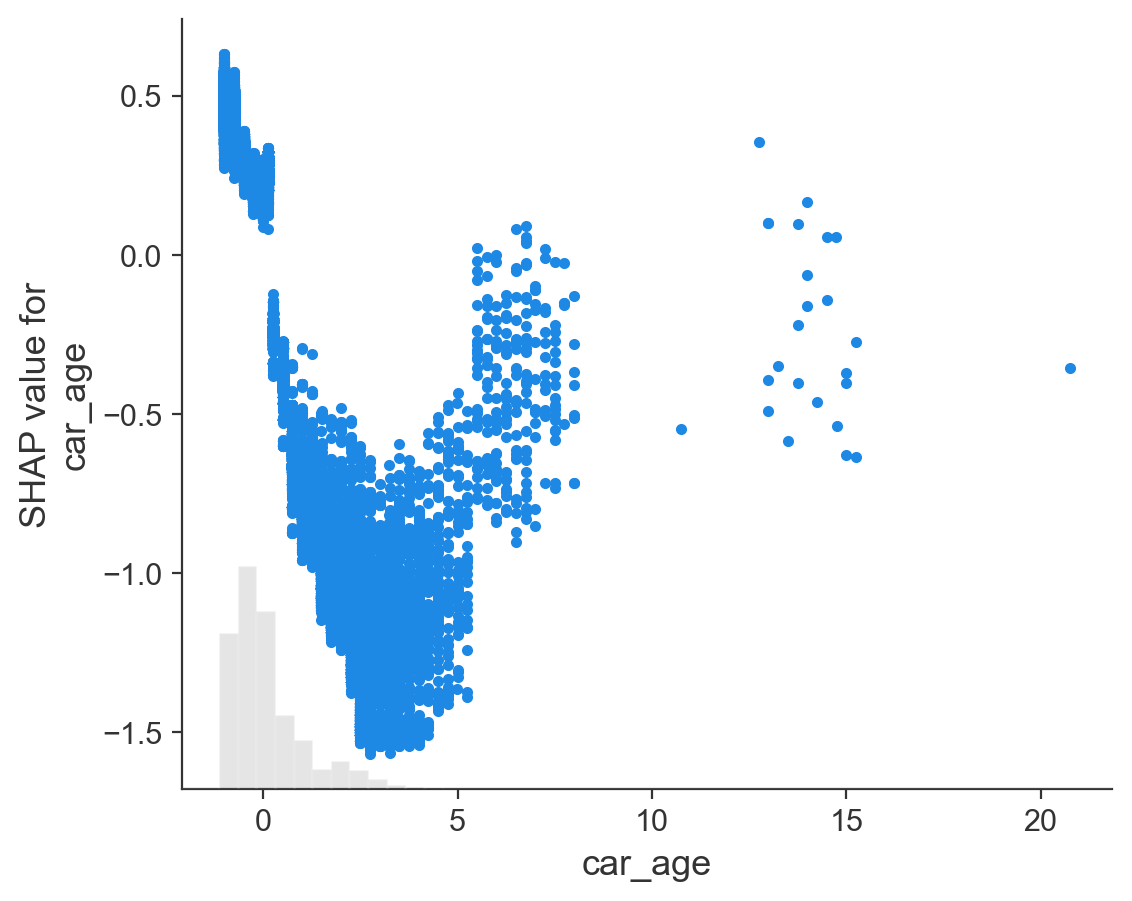

In [461]:
shap.plots.scatter(gbr_shap_values[:, 'car_age'])

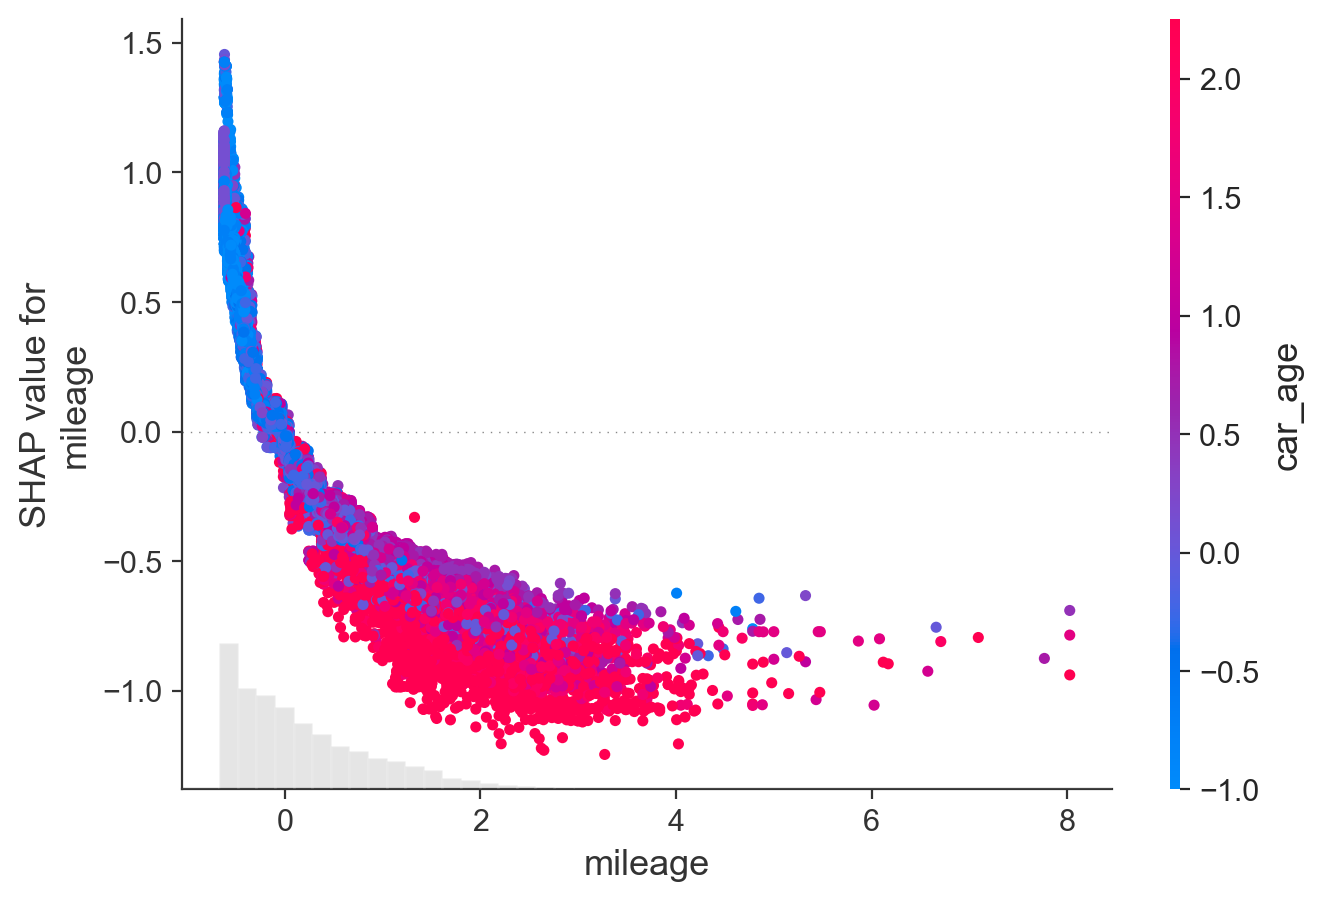

In [462]:
shap.plots.scatter(gbr_shap_values[:,"mileage"], color=gbr_shap_values[:,"car_age"])

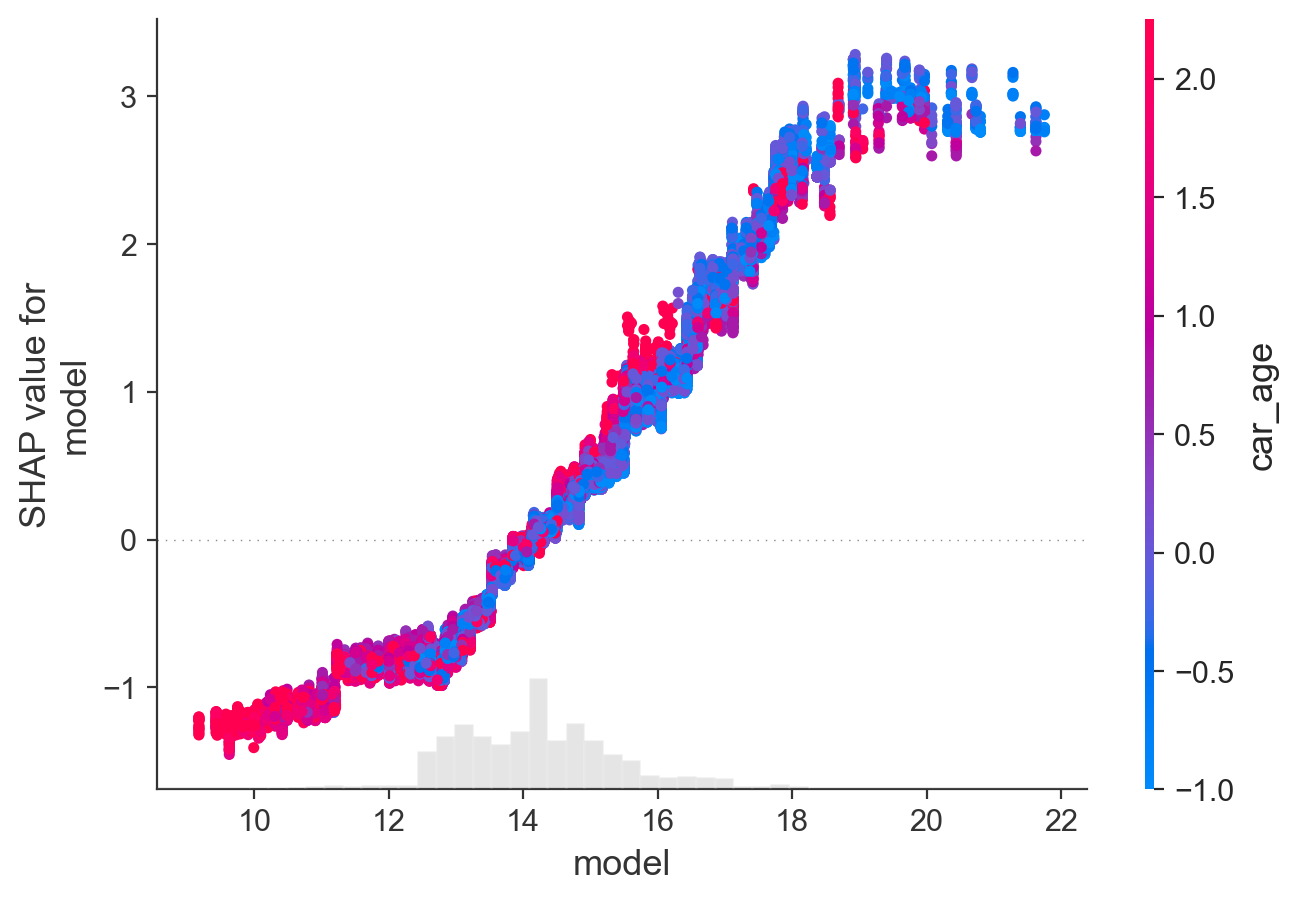

In [463]:
shap.plots.scatter(gbr_shap_values[:,"model"], color=gbr_shap_values[:,"car_age"])

"""

# PARTIAL DEPENDENCY PLOTS

"""

LINEAR REG

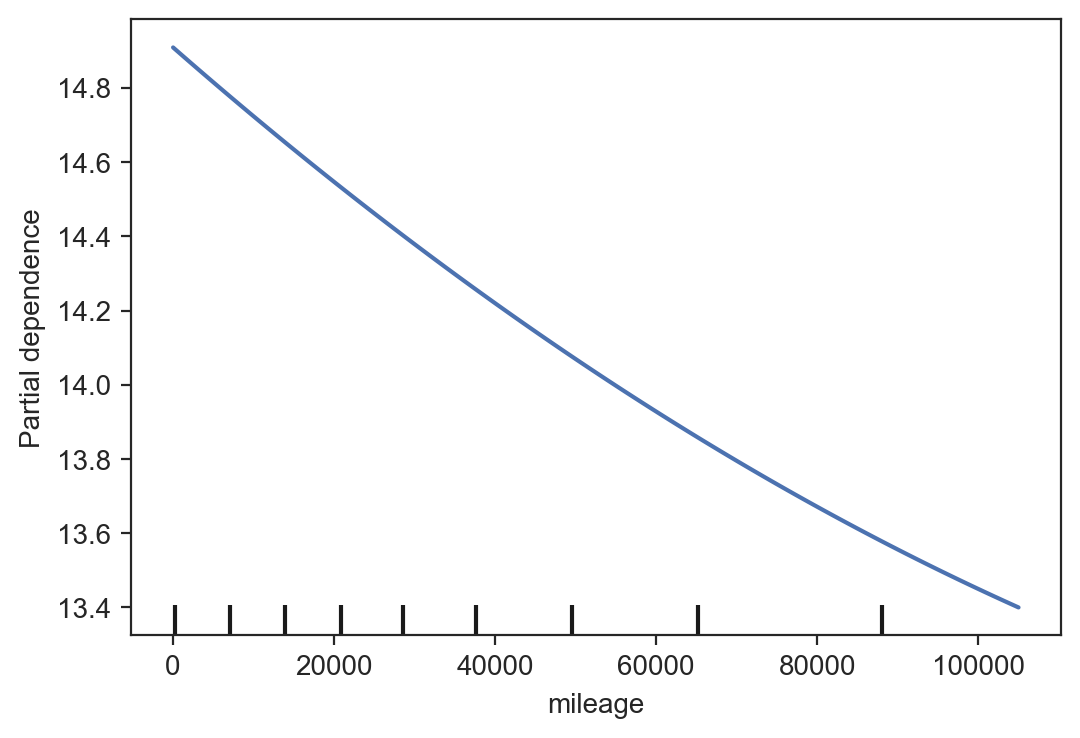

In [465]:
PartialDependenceDisplay.from_estimator(
    lr, X_test, features=['mileage'], kind='average'
);

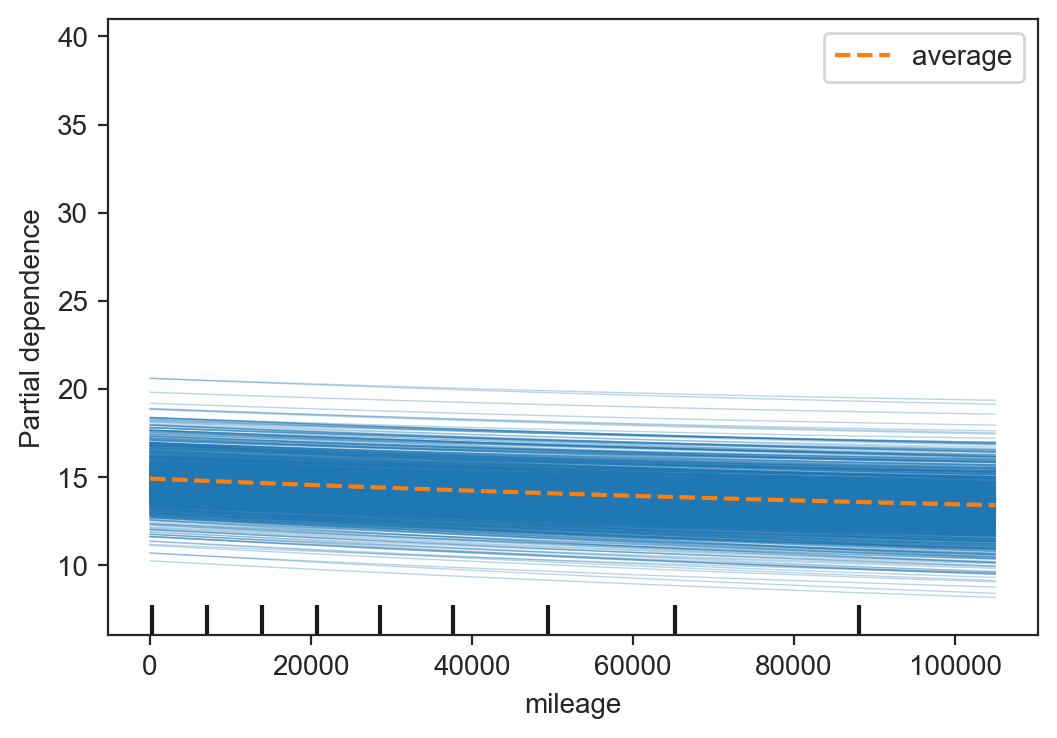

In [466]:
PartialDependenceDisplay.from_estimator(
    lr, X_test, features=['mileage'], kind='both'
);

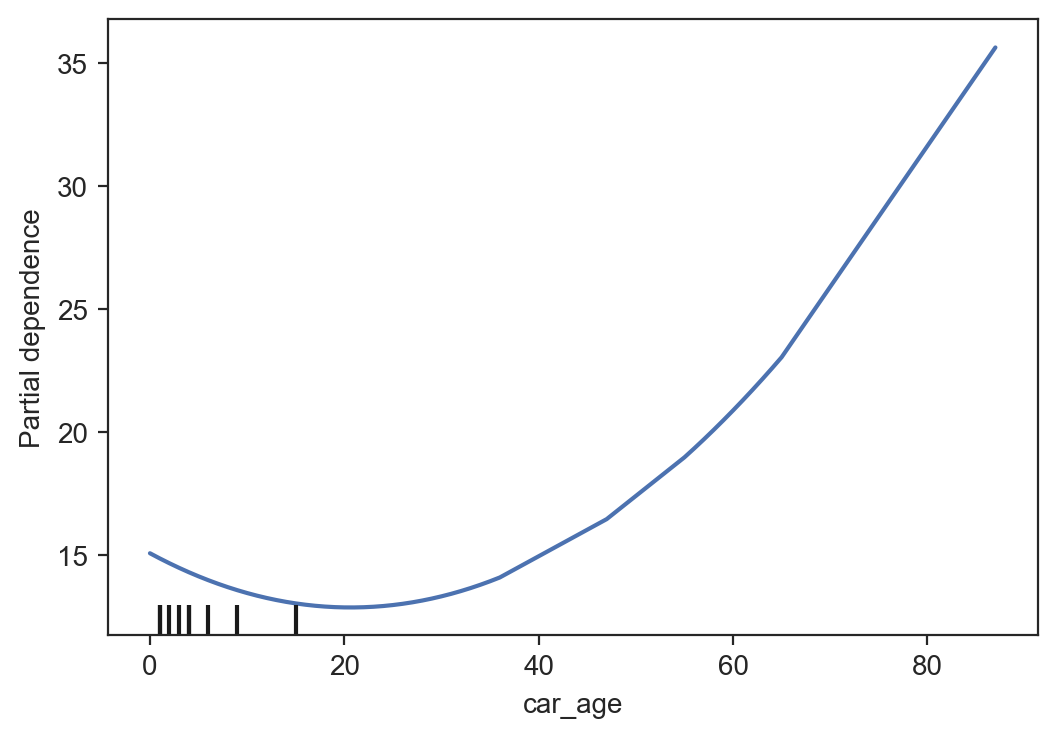

In [467]:
PartialDependenceDisplay.from_estimator(
    lr, X_test, features=['car_age'], kind='average'
);

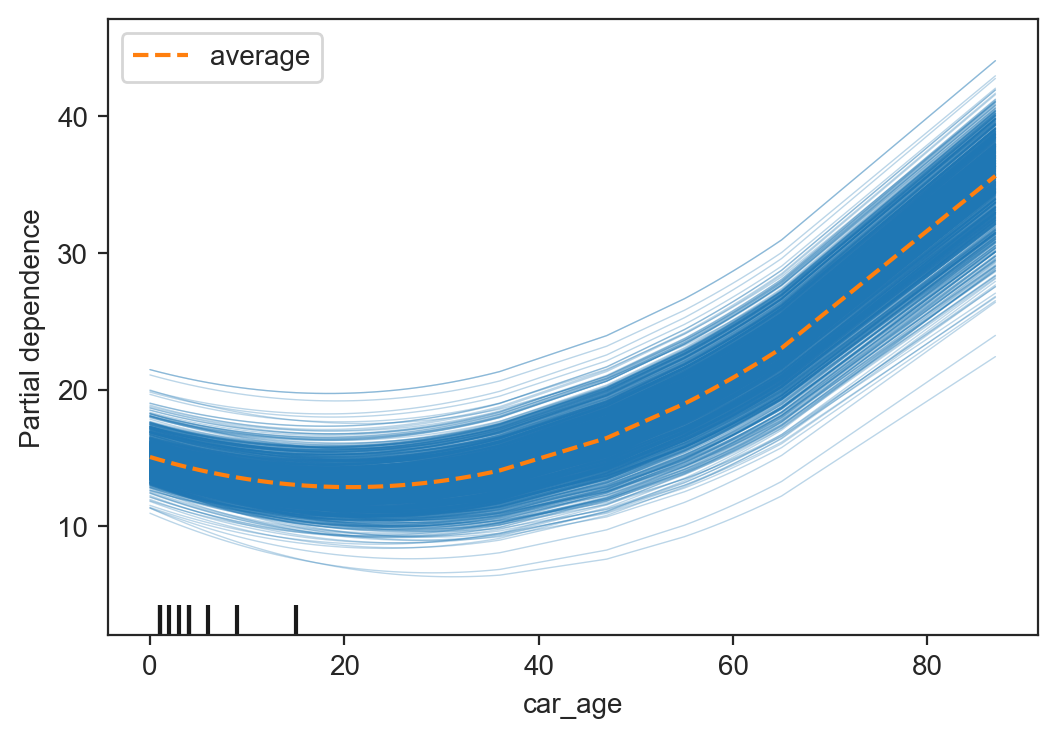

In [469]:
PartialDependenceDisplay.from_estimator(
    lr, X_test, features=['car_age'], kind='both'
);

RANDOM FOREST REGRESSOR

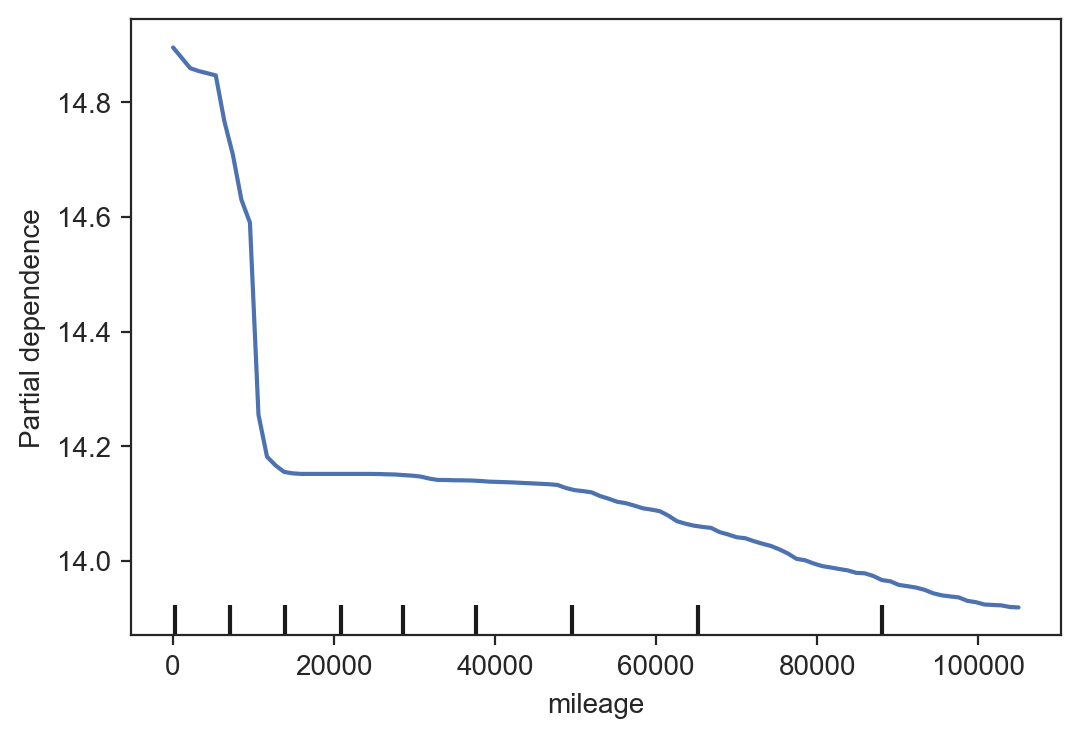

In [470]:
PartialDependenceDisplay.from_estimator(
    rfr, X_test, features=['mileage'], kind='average'
);

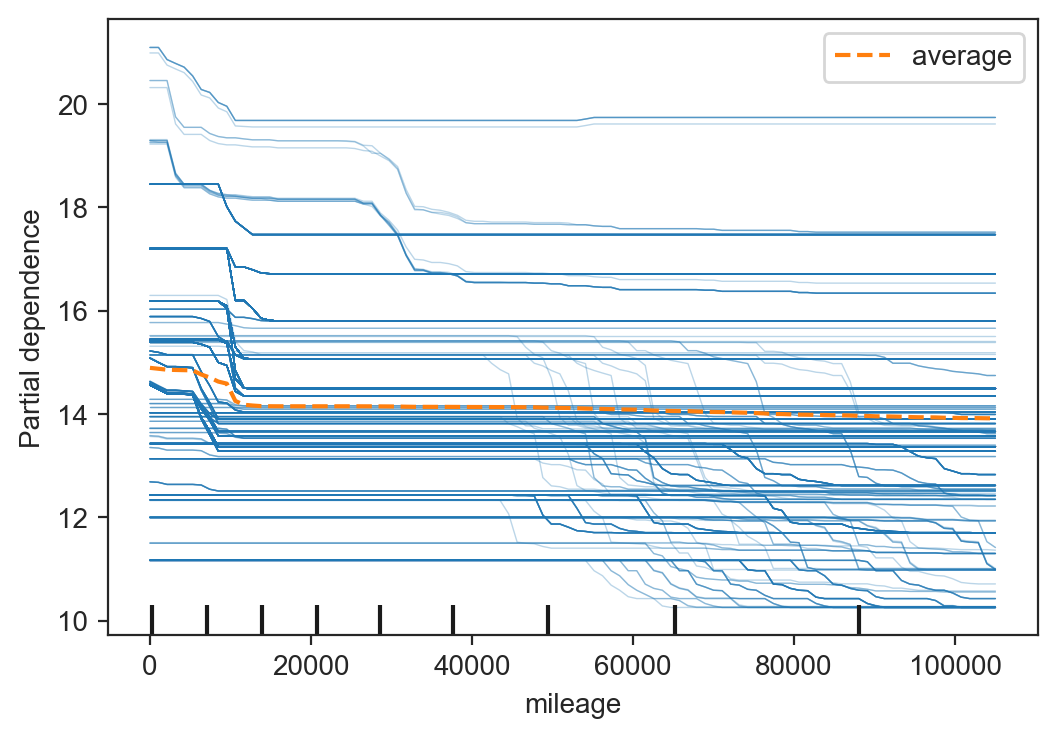

In [471]:
PartialDependenceDisplay.from_estimator(
    rfr, X_test, features=['mileage'], kind='both'
);

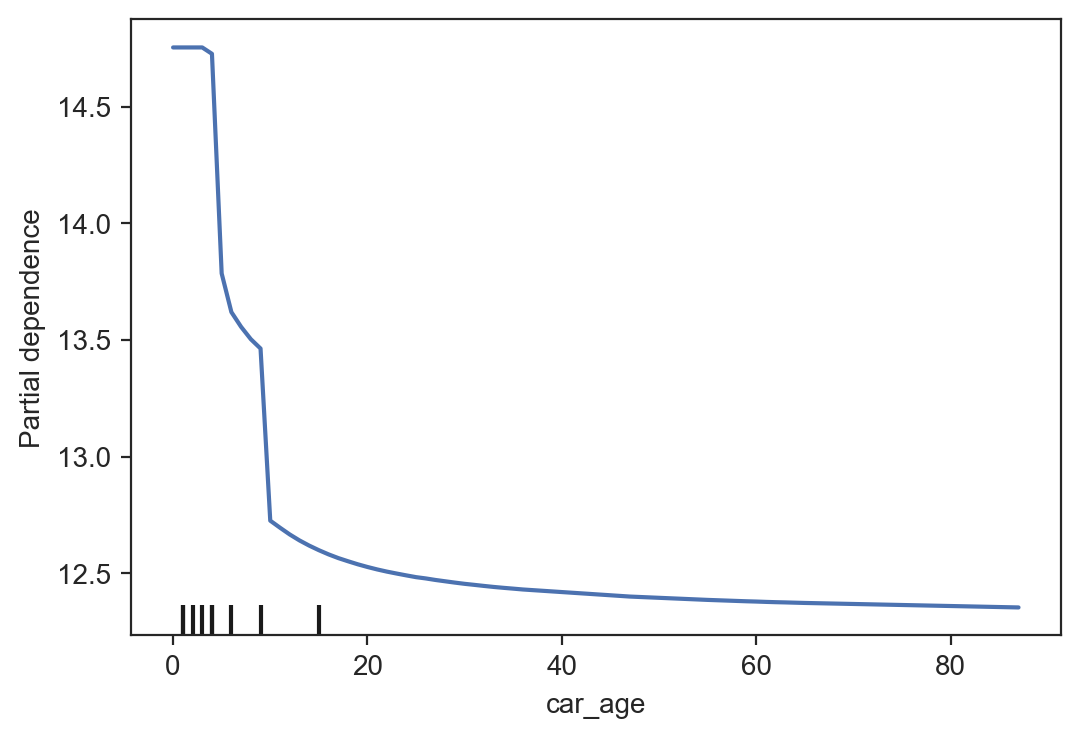

In [473]:
PartialDependenceDisplay.from_estimator(
    rfr, X_test, features=['car_age'], kind='average'
);

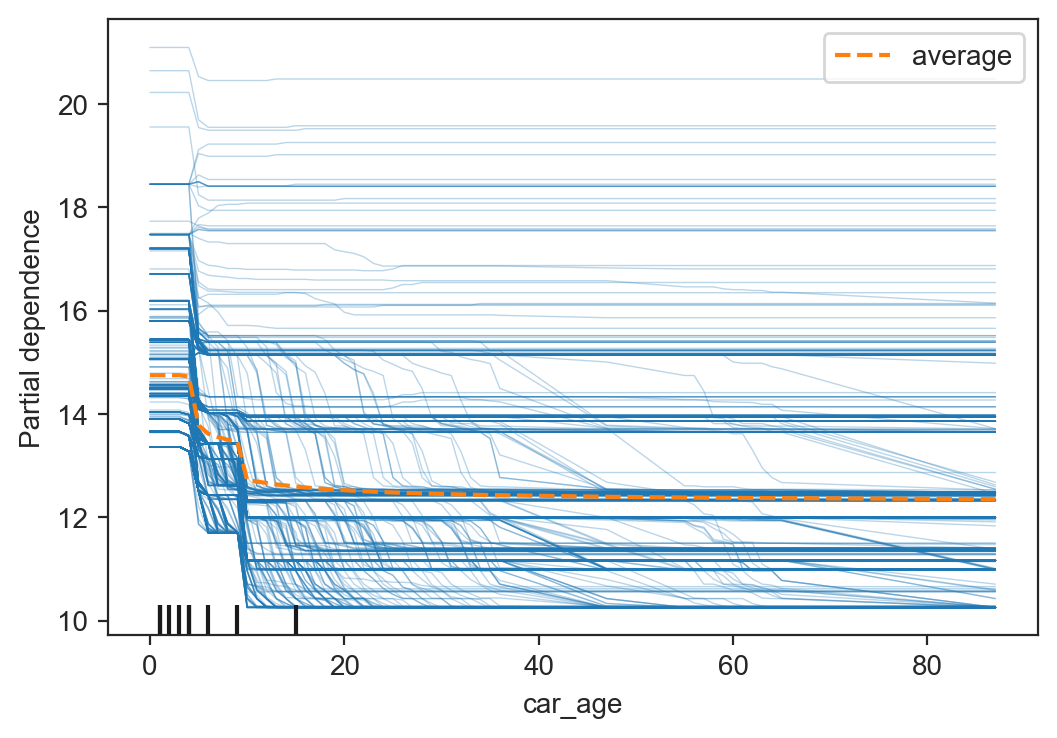

In [475]:
PartialDependenceDisplay.from_estimator(
    rfr, X_test, features=['car_age'], kind='both'
);

GRADIENT BOOSTING REGRESSOR

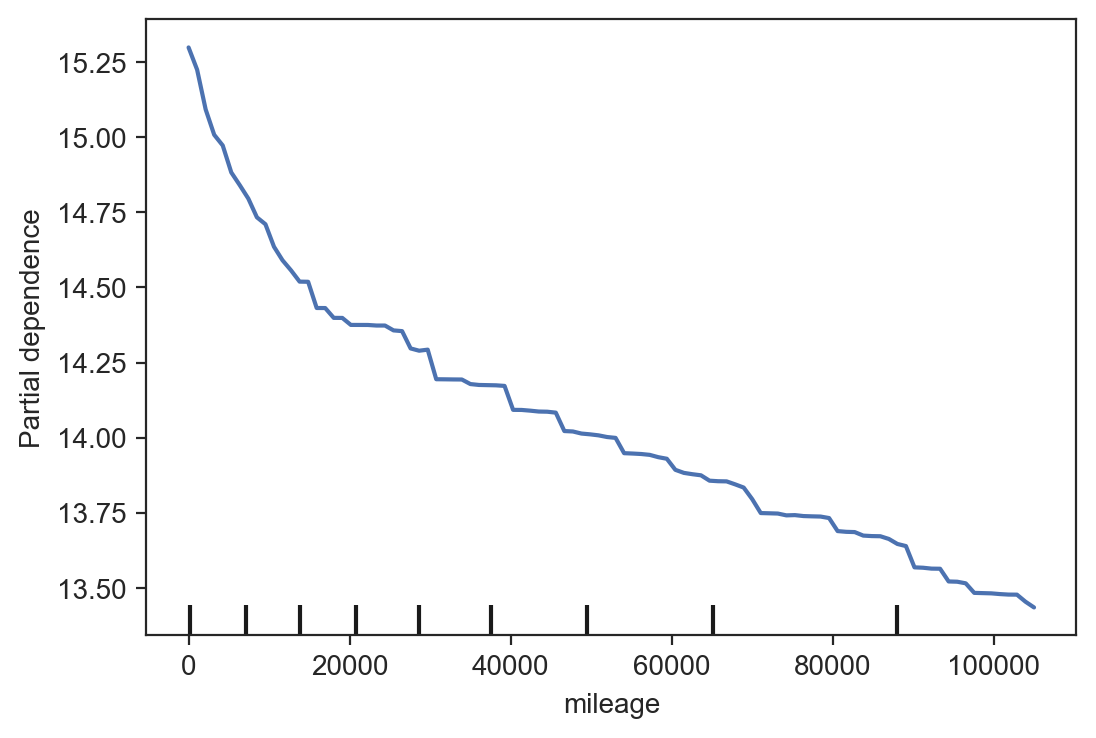

In [476]:
PartialDependenceDisplay.from_estimator(
    gbr, X_test, features=['mileage'], kind='average'
);

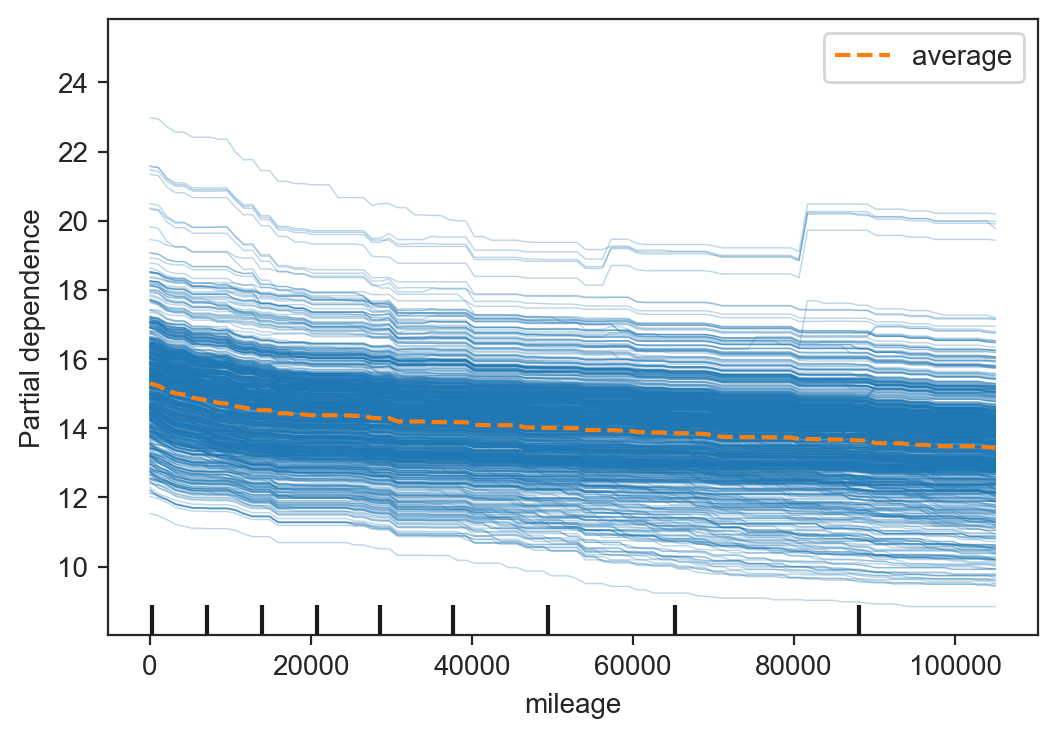

In [477]:
PartialDependenceDisplay.from_estimator(
    gbr, X_test, features=['mileage'], kind='both'
);

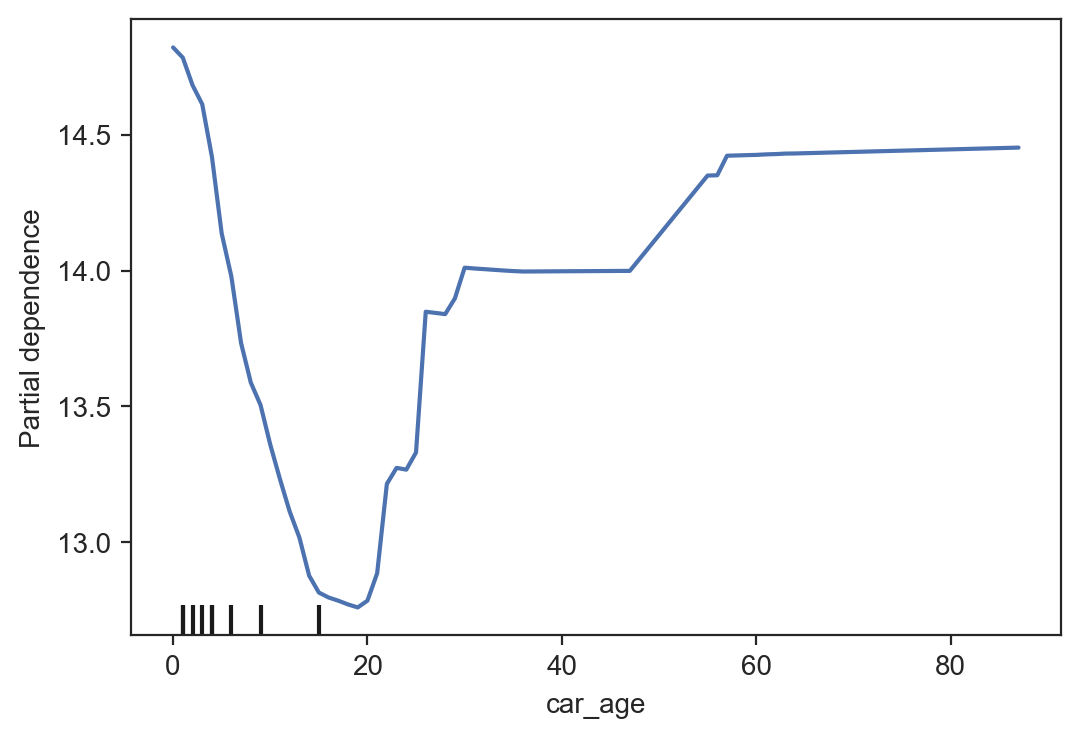

In [478]:
PartialDependenceDisplay.from_estimator(
    gbr, X_test, features=['car_age'], kind='average'
);

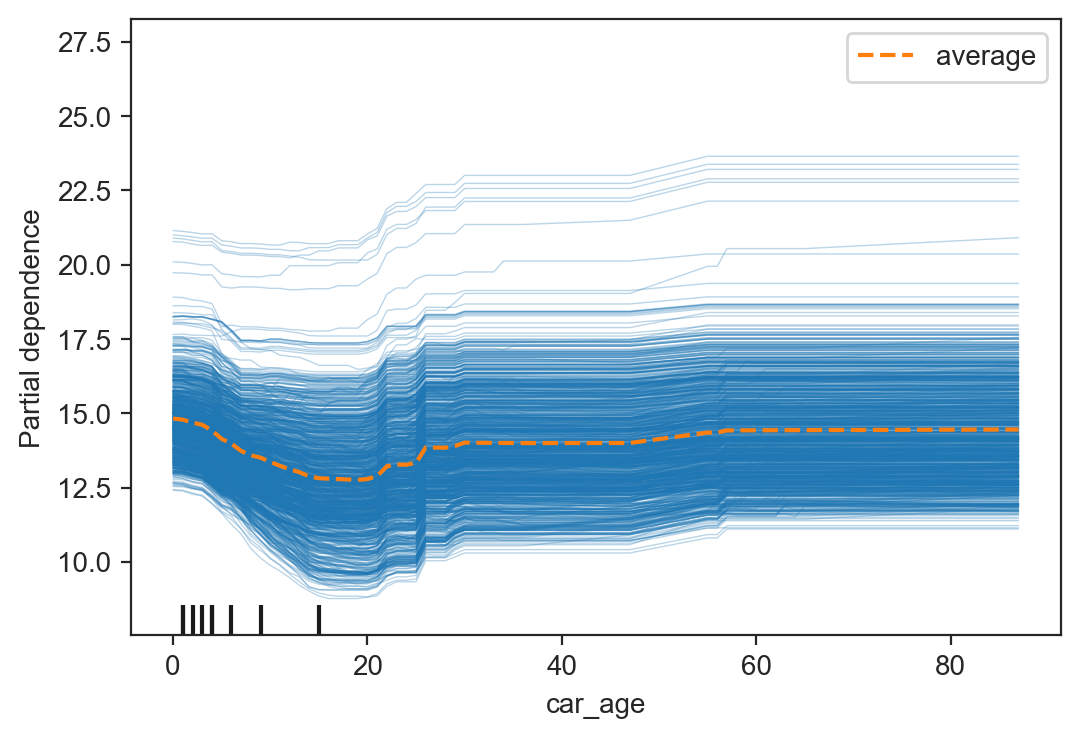

In [479]:
PartialDependenceDisplay.from_estimator(
    gbr, X_test, features=['car_age'], kind='both'
);